# Difference Finite Scheme derived from MRT-Hermite Lattice Boltzmann for Convective-Diffusive Equation in D1Q5

## MRT Lattice Boltzmann equation for Convective-Diffusive Equation

To describe convective-diffusive problems, the MRT lattice Boltzmann formulation is described by:

$$
f_i( x_{\alpha} + e_{i,\alpha} \delta t, t+\delta t) = f_i(x_{\alpha}, t)  - (\textbf{M}^{-1}\textbf{S}\textbf{M})_{ik}\left( f_{k} - f_{k}^{eq}  \right), 
$$(MRT-Herm-LB-conv-df-Eq)

where $\textbf{M}$ is matrix of moments, $\textbf{S}$ is the diagonal matrix of relaxation times, and $\textbf{M}^{-1}$ is the inverse matrix of $\textbf{M}$. Considering the problem description in a lattice D1Q3, we have:

$$
\textbf{M} =\begin{pmatrix} 1 \\ e_{i,x} \\ e_{i,x}^{2}-c_{s}^{2} \\ e_{i,x}^{3}-3e_{i,x}c_{s}^{2} \\ e_{i,x}^{4}-6e_{i,x}^{2}c_{s}^{2} + 3c_{s}^{4} \end{pmatrix} =\begin{pmatrix}
1 & 1 & 1 & 1 & 1\\0 & 1 & -1 & 2 & -2\\-1 & 0 & 0 & 3 & 3\\0 & -2 & 2 & 2 & -2\\3 & -2 & -2 & -5 & -5
\end{pmatrix},  \qquad \qquad  \textbf{S} = \begin{pmatrix} s_0 & 0 & 0 & 0 & 0 \\ 0   & s_1 & 0 & 0 & 0 \\ 0 & 0 & s_2 & 0 & 0 \\ 0 & 0 & 0 & s_3 & 0 \\ 0 & 0 & 0 & 0 & s_4 \end{pmatrix},  \qquad \qquad \textbf{M}^{-1}=\begin{pmatrix} \frac{1}{2} & 0 & \frac{1}{4} & 0 & \frac{1}{4}\\\frac{1}{6} & \frac{1}{6} & - \frac{1}{3} & - \frac{1}{6} & - \frac{1}{6}\\\frac{1}{6} & - \frac{1}{6} & - \frac{1}{3} & \frac{1}{6} & - \frac{1}{6}\\\frac{1}{12} & \frac{1}{6} & \frac{5}{24} & \frac{1}{12} & \frac{1}{24}\\\frac{1}{12} & - \frac{1}{6} & \frac{5}{24} & - \frac{1}{12} & \frac{1}{24} \end{pmatrix}.
$$

The equilibrium distribution function is defined by

$$
\begin{aligned}
f^{eq}_{i} &=w_{i}\sum_{\theta=0}^{4}\dfrac{a^{\theta} \mathcal{H}^{\theta}}{\theta! c_{s}^{2\theta}} = w_{i}\left( u\mathcal{H}^{0} + \frac{B_{\alpha}\mathcal{H}^{1}}{c_{s}^{2}} + \frac{ \left( \Lambda_{\alpha\beta} + \Lambda_{\alpha\beta}^{aux} - c_{s}^{2}u\delta_{\alpha\beta} \right) \mathcal{H}^{2}}{2c_{s}^{4}} + \frac{ \left( \Pi_{\alpha\beta\gamma} - \tilde{3}c_{s}^{2}B_{\alpha}\delta_{\beta\gamma} \right) \mathcal{H}^{3}}{6c_{s}^{6}}  \right)\\
&= w_{i}\left( u + \frac{e_{i,\alpha} B_{\alpha}}{c_{s}^{2}} + \frac{ \left( \Lambda_{\alpha\beta} + \Lambda_{\alpha\beta}^{aux} - c_{s}^{2}u\delta_{\alpha\beta} \right) \left( e_{i,\alpha}e_{i,\beta} - c_{s}^{2}\delta_{\alpha\beta} \right)}{2c_{s}^{4}} + \frac{ \left( \Pi_{\alpha\beta\gamma} - \tilde{3}c_{s}^{2}B_{\alpha}\delta_{\beta\gamma} \right) \left( e_{i,\alpha}e_{i,\beta}e_{i,\gamma} - \tilde{3}c_{s}^{2}e_{i,\alpha}\delta_{\beta\gamma} \right)}{6c_{s}^{6}} \right),
\end{aligned}
$$

where $\Lambda_{\alpha\beta}=c_{s}^{2}C\delta_{\alpha\beta} $, $C$ is the Diffusive term, and $\Lambda_{\alpha\beta}^{aux}$ is a correction term defined by

$$
\Lambda_{\alpha\beta}^{aux} = \displaystyle\int  B_{\alpha}^{'}B_{\beta}^{'}  du = \displaystyle\int \left(\displaystyle\frac{\partial B_{\alpha}}{\partial u} \displaystyle\frac{\partial B_{\beta}}{\partial u} \right) du.
$$

In [227]:
import warnings
warnings.filterwarnings("ignore")
from pylab import *
from __future__ import division
from sympy import *
import numpy as np
from sympy import S, collect, expand, factor, Wild
from sympy import fraction, Rational, Symbol
from sympy import symbols, sqrt, Rational
import sympy as sp
from IPython.display import display, Math, Latex
#-------------------------------------------------Símbolos----------------------------------------------
omega, u, B, w, C, Lamb = symbols('omega, u, B_{\\alpha}, w, C, \\Lambda_{\\alpha\\beta}')
Pi, Gamma = symbols('\\Pi_{\\alpha\\beta\\gamma} \\Gamma_{\\alpha\\beta\\gamma\\delta}')
wi, cx, cy, cs = symbols('w_{i} c_{x} c_{y} c_{s}')
w0s, w1s, w2s = symbols('w_{0} w_{1} w_{2}')
fi, f0, f1, f2, f3, f4  = symbols('f_{i} f_{0} f_{1} f_{2} f_{3} f_{4}')
#-------------------------------------------------Funções----------------------------------------------
feq = Function('feq')(wi, cx, cy)
fneq = Function('fneq')(wi, cx, cy)
f = Function('f')(fi)
#----------------------------------------------Lattice-D2Q9---Variáveis----------------------------------------------
fi=np.array([f0,f1,f2])
w0 = sp.Rational(1, 2)
w1 = sp.Rational(1, 6)
w2 = sp.Rational(1, 12)
wi=np.array([w0,w1,w1,w2,w2])
cx=np.array([0,1,-1,2,-2])
as2 = sp.Rational(1, 1)
cs2 = sp.Rational(1, 1)
gamma=(16+5*sp.sqrt(10))/6
#-------------------------------------------------Calc.Func------------------------------------------------
f= fi
# feq=wi*(u + as2*cx*B + (as2**2)*(Lamb-u/as2)*(cx*cx-1/as2)/2
#        +(as2**3)*(Pi - 3*B/as2)*(cx*cx*cx - 3*cx/as2)/6 
#        +(as2**4)*(Gamma - 6*Lamb/as2 + 3*u/(as2**2))*(cx*cx*cx*cx - 6*cx*cx/as2 + 3/(as2**2))/(24*gamma))
feq=wi*(u + as2*cx*B + (as2**2)*(Lamb-u/as2)*(cx*cx-1/as2)/2
       +(as2**3)*(Pi - 3*B/as2)*(cx*cx*cx - 3*cx/as2)/2
       # +(as2**4)*(Gamma - 6*Lamb/as2 + 3*u/(as2**2))*(cx*cx*cx*cx - 6*cx*cx/as2 + 3/(as2**2))/(24)
        # +(as2**4)*(Gamma )*(cx*cx*cx*cx - 6*cx*cx/as2 + 3/(as2**2))/(24)
       )
feq2=wi*(u)

In [228]:
display(simplify(cx*0+1))
display(simplify(cx))
display(simplify(cx*cx - cs2))
display(simplify(cx*cx*cx - 3*cx*cs2))
display(simplify(cx*cx*cx*cx - 6*cx*cx*cs2 + 3*cs2**2))
display(simplify(sum(feq)))
display(simplify(sum(feq*cx)))
display(simplify(sum(feq*cx*cx)))
display(simplify(sum(feq*cx*cx*cx)))
display(simplify(sum(feq*cx*cx*cx*cx)))

[1, 1, 1, 1, 1]

[0, 1, -1, 2, -2]

[-1, 0, 0, 3, 3]

[0, -2, 2, 2, -2]

[3, -2, -2, -5, -5]

u

B_{\alpha}

\Lambda_{\alpha\beta}

\Pi_{\alpha\beta\gamma}

4*\Lambda_{\alpha\beta} - u

In [229]:
m2=cx*cx - cs2
m3=cx*cx*cx - 3*cs2*cx
m4=cx*cx*cx*cx - 6*cs2*cx*cx + 3*cs2*cs2
display(simplify(sum(feq)))
display(simplify(sum(feq*cx)))
display(simplify(sum(feq*m2)))
display(simplify(sum(feq*m3)))
display(simplify(sum(feq*m4)))

u

B_{\alpha}

\Lambda_{\alpha\beta} - u

-3*B_{\alpha} + \Pi_{\alpha\beta\gamma}

-2*\Lambda_{\alpha\beta} + 2*u

The different orders of equilibrium moments can be recovered by:

In [230]:
feq3=wi*(u)
a0=simplify(sum(feq3))
ax=simplify(sum(feq3*cx))
axx=simplify(sum(feq3*cx*cx))
axxx=simplify(sum(feq3*cx*cx*cx))
axxxx=simplify(sum(feq3*cx*cx*cx*cx))
display(Math(r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Moment}} =" +  sp.latex(a0) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}e_{i,x} }_{\textrm{x-First-Order Moment}} =" +  sp.latex(ax)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} e_{i,x}e_{i,x} }_{\textrm{xx-Second-Order Moment}} =" +  sp.latex(axx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} e_{i,x}e_{i,x}e_{i,x} }_{\textrm{xxx-Third-Order Moment}} =" +  sp.latex(axxx) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} e_{i,x}e_{i,x}e_{i,x}e_{i,x} }_{\textrm{xxxx-Fourth-Order Moment}} =" +  sp.latex(axxxx) ))

aH0=simplify(sum(feq3))
aHx=simplify(sum(feq3*cx))
aHxx=simplify(sum(feq3*(cx*cx - cs**2)))
aHxxx=simplify(sum(feq3*(cx*cx*cx - 3*cx*cs**2)))
aHxxxx=simplify(sum(feq3*(cx*cx*cx*cx - 6*cx*cx*cs**2 + 3*cs**4)))
display(Math(r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Hermite Moment}} =" +  sp.latex(aH0) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}e_{i,x} }_{\textrm{x-First-Order Hermite Moment}} =" +  sp.latex(aHx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(e_{i,x}e_{i,x} - c_{s}^{2} \right) }_{\textrm{xx-Second-Order Hermite Moment}} =" +  sp.latex(aHxx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(e_{i,x}e_{i,x} - 3c_{s}^{2} e_{i,x} \right) }_{\textrm{xxx-Third-Order Hermite Moment}} =" +  sp.latex(aHxxx) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(e_{i,x}e_{i,x} - 6c_{s}^{2}e_{i,x}e_{i,x} + 3c_{s}^{4} \right)}_{\textrm{xxxx-Fourth-Order Hermite Moment}} =" +  sp.latex(aHxxxx) ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [231]:
a0=simplify(sum(feq))
ax=simplify(sum(feq*cx))
axx=simplify(sum(feq*cx*cx))
axxx=simplify(sum(feq*cx*cx*cx))
axxxx=simplify(sum(feq*cx*cx*cx*cx))
display(Math(r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Moment}} =" +  sp.latex(a0) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}e_{i,x} }_{\textrm{x-First-Order Moment}} =" +  sp.latex(ax)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} e_{i,x}e_{i,x} }_{\textrm{xx-Second-Order Moment}} =" +  sp.latex(axx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} e_{i,x}e_{i,x}e_{i,x} }_{\textrm{xxx-Third-Order Moment}} =" +  sp.latex(axxx) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} e_{i,x}e_{i,x}e_{i,x}e_{i,x} }_{\textrm{xxxx-Fourth-Order Moment}} =" +  sp.latex(axxxx) ))

aH0=simplify(sum(feq))
aHx=simplify(sum(feq*cx))
aHxx=simplify(sum(feq*(cx*cx - cs**2)))
aHxxx=simplify(sum(feq*(cx*cx*cx - 3*cx*cs**2)))
aHxxxx=simplify(sum(feq*(cx*cx*cx*cx - 6*cx*cx*cs**2 + 3*cs**4)))
display(Math(r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Hermite Moment}} =" +  sp.latex(aH0) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}e_{i,x} }_{\textrm{x-First-Order Hermite Moment}} =" +  sp.latex(aHx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(e_{i,x}e_{i,x} - c_{s}^{2} \right) }_{\textrm{xx-Second-Order Hermite Moment}} =" +  sp.latex(aHxx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(e_{i,x}e_{i,x} - 3c_{s}^{2} e_{i,x} \right) }_{\textrm{xxx-Third-Order Hermite Moment}} =" +  sp.latex(aHxxx) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(e_{i,x}e_{i,x} - 6c_{s}^{2}e_{i,x}e_{i,x} + 3c_{s}^{4} \right)}_{\textrm{xxxx-Fourth-Order Hermite Moment}} =" +  sp.latex(aHxxxx) ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## FDM Interpretation in MRT Framework

Reinterpreting the Eq. {eq}`MRT-Herm-LB-conv-df-Eq` with a shift in distribution function direction:

$$
f_{i,x}^{t+1}  = f_{i,x-e_{i}}^{t}  - (\textbf{M}^{-1}\textbf{S}\textbf{M})_{ik}\left( f_{k,x-e_{i}}^{t} - f_{k,x-e_{i}}^{eq,t} \right) =   (\textbf{M}^{-1} (\textbf{I} -\textbf{S}) \textbf{M})_{ik} f_{k,x-e_{i}}^{t} + (\textbf{M}^{-1}\textbf{S}\textbf{M})_{ik} f_{k,x-e_{i}}^{eq,t}  , 
$$

where $f_i( x_{\alpha} + e_{i,\alpha} \delta t, t+\delta t)=f_{i,x+c_{i}}^{t+1}$ for simplificate the notation and $\textbf{I}$ is identity matrix. Defining the shift operator $T_{\Delta x}^{c_{i}}$, where $f_{k,x-e_{i}}^{t}= T_{\Delta x}^{c_{i}}[f_{k,x}^{t}]$, we can rewrite the above equation inside of the moments space:

$$
\textbf{m}_{k,x}^{t+1}  = \textbf{P}\textbf{m}_{k,x}^{t}  + \textbf{Q}\textbf{m}_{k,x}^{eq,t}, 
$$(pre-MRT-Herm-LB-conv-df-Eq)

where $\textbf{m}_{k,x}^{t}=M_{ik}f_{i,x}^{t}$, $k$ is the index of moments in the space moment, $\textbf{T}:= \textbf{M} (diag\left( T_{\Delta x}^{c_{0}}, T_{\Delta x}^{c_{1}}, T_{\Delta x}^{c_{2}}, T_{\Delta x}^{c_{3}}, T_{\Delta x}^{c_{4}} \right)) \textbf{M}^{-1}$, $\textbf{P}:=\textbf{T}(\textbf{I}-\textbf{S})$, and , $\textbf{Q}:=\textbf{T}\textbf{S}$. The matrices are given by:

In [232]:
import warnings
warnings.filterwarnings("ignore")
from pylab import *
from sympy import *
import numpy as np

fic, f0c, f1c, f2c, f3c, f4c = symbols(['f_{i\,x+c_{i}}^t','f_{0\,x+c_{i}}^t','f_{1\,x+c_{i}}^t','f_{2\,x+c_{i}}^t','f_{3\,x+c_{i}}^t','f_{4\,x+c_{i}}^t'])
f0tp1, f1tp1, f2tp1, f3tp1, f4tp1 = symbols(['f_{0\,x}^{t+1}','f_{1\,x}^{t+1}','f_{2\,x}^{t+1}','f_{3\,x}^{t+1}','f_{4\,x}^{t+1}'])
f0, f1, f2, f3, f4 = symbols(['f_{0\,x}^t','f_{1\,x}^t','f_{2\,x}^t','f_{3\,x}^t','f_{4\,x}^t'])
f0m1, f1m1, f2m1, f0p1, f1p1, f2p1 = symbols(['f_{0\,x-1}^t','f_{1\,x-1}^t','f_{2\,x-1}^t','f_{0\,x+1}^t','f_{1\,x+1}^t','f_{2\,x+1}^t'])
# f0m3, f3m3, f4m3, f0p3, f3p3, f4p3 = symbols(['f_{0\,x-1}^t','f_{1\,x-1}^t','f_{2\,x-1}^t','f_{0\,x+1}^t','f_{1\,x+1}^t','f_{2\,x+1}^t'])
f0m1t1, f1m1t1, f2m1t1, f0p1t1, f1p1t1, f2p1t1 = symbols(['f_{0\,x-1}^{t-1}','f_{1\,x-1}^{t-1}','f_{2\,x-1}^{t-1}','f_{0\,x+1}^{t-1}','f_{1\,x+1}^{t-1}','f_{2\,x+1}^{t-1}'])
f0t1 = symbols('f_{0\,x}^{t-1}')
w0, w1, w2 = symbols(['w_0','w_1','w_2'])
s0, s1, s2, s3, s4 = symbols(['s_0','s_1','s_2','s_3','s_4'])
phi, phic, phim1, phip1 = symbols(['\\phi_{x}^{t}','\\phi_{x-c_{i}}^{t}','\\phi_{x-1}^{t}','\\phi_{x+1}^{t}'])
phitp1, phit1, phit2= symbols(['\\phi_{x}^{t+1}','\\phi_{x}^{t-1}','\\phi_{x}^{t-2}'])
phim1t1,phip1t1= symbols([r'\phi_{x-1}^{t-1}',r'\phi_{x+1}^{t-1}'])
Tc0, Tc1, Tc2, Tc3, Tc4= symbols([r'T_{\Delta_{x}}^{c_{0}}',r'T_{\Delta_{x}}^{c_{1}}',r'T_{\Delta_{x}}^{c_{2}}',r'T_{\Delta_{x}}^{c_{3}}',r'T_{\Delta_{x}}^{c_{4}}'])
Tc13, Tc14, Tc23, Tc24= symbols([r'T_{\Delta_{x}}^{c_{1}c_{3}}',r'T_{\Delta_{x}}^{c_{1}c_{4}}',r'T_{\Delta_{x}}^{c_{2}c_{3}}',r'T_{\Delta_{x}}^{c_{2}c_{4}}'])
wiM=Matrix([w0,w1,w2])
fi=np.array([f0,f1,f2])
fM = Matrix([f0,f1,f2])
ficM = Matrix([f0c,f1c,f2c])
I=eye(5)
Tc = Matrix([I[0,:]*Tc0,I[1,:]*Tc1,I[2,:]*Tc2,I[3,:]*Tc3,I[4,:]*Tc4])
SM=Matrix([I[0,:]*s0,I[1,:]*s1,I[2,:]*s2,I[3,:]*s3,I[4,:]*s4])
feqM=Matrix([feq[0],feq[1],feq[2],feq[3],feq[4]])
m0=np.array([1,1,1,1,1])
m1=cx
m2=cx*cx - cs2
m3=cx*cx*cx - 3*cs2*cx
m4=cx*cx*cx*cx - 6*cs2*cx*cx + 3*cs2*cs2
# m2=cx*cx - cs**2
# m3=cx*cx*cx - 3*cs**2*cx
# m4=cx*cx*cx*cx - 6*cs**2*cx*cx + 3*cs**4
M=np.array([m0,m1,m2,m3,m4])
MM=Matrix([m0,m1,m2,m3,m4])
MMinv=MM.inv()

In [233]:
TM=sp.simplify(MM*Tc*MMinv)
P=sp.simplify(TM*(I-SM))
Q=sp.simplify(TM*SM)

display(Math(r"\textbf{T} =" +  sp.latex(TM) +"," ))
display(Math(r"\textbf{P} =" +  sp.latex(P) +"," ))
display(Math(r"\textbf{Q} =" +  sp.latex(Q) +"." ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

By the Eq. {eq}`pre-MRT-Herm-LB-conv-df-Eq` can be shifted in time, we recursively over $n$ timestep replace the shifted time function in it:

$$
\underbrace{ \textbf{m}_{k,x}^{t+1}  = \textbf{P}\textbf{m}_{k,x}^{t}  + \textbf{Q}\textbf{m}_{k,x}^{eq,t} \quad \rightarrow \quad  \textbf{m}_{k,x}^{t}  = \textbf{P}\textbf{m}_{k,x}^{t-1}  + \textbf{Q}\textbf{m}_{k,x}^{eq,t-1} }_{\textrm{Time Shift}} \qquad  \textrm{Recursive Substitution $n$ times:} \qquad \textbf{m}_{k,x}^{t+1}  = \textbf{P}^{n}\textbf{m}_{k,x}^{t-n+1}  + \displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,t-l}.
$$(pre-MRT-Herm-LB-conv-df-Eq-s2)

The next steps follow in orde to employ the Calay-Hamilton theorem {cite:p}`bellotti2022finite`. In htis way, we need to find the characteristical polinomial $\mathcal{X}_{P}$ of the matrix $\textbf{P}$ (the definition of characteristical polinomial are presented in toogle below), given by:

```{toggle}
The characteristic polynomial of a square matrix $(P \in \mathbb{R}^{n \times n})$ (or $(\mathbb{C}^{n \times n}))$ is defined as:

$$
\boxed{\mathcal{X}_{P}(X) = \det(X I - P)} \qquad \rightarrow \qquad \mathcal{X}_{P}(X) = \sum_{i=0}^{n} X^{i}\gamma^{i} 
$$

where $\gamma_{i}$ are the polynomial coefficients.

```

$$
\mathcal{X}_{P} = \gamma_{5}X^{5} + \gamma_{4}X^{4} + \gamma_{3}X^{3} +  \gamma_{2}X^{2} +  \gamma_{1}X^{1} +  \gamma_{0},
$$

where all the polynomial coefficients $\gamma_{i}$ are shifted by $T_{\Delta x}^{c_{0}}$:

In [234]:
import pickle
from pathlib import Path
from sympy import symbols

X = symbols("X")
filename = Path("characteristic_polynomial.pkl")

if filename.exists():
    # Read the previously calculated result
    with filename.open("rb") as file:
        cp = pickle.load(file)

    print("Characteristic polynomial loaded from file.")

else:
    # Calculate only when the saved file does not exist
    cp = P.charpoly(X)

    with filename.open("wb") as file:
        pickle.dump(cp, file)

    print("Characteristic polynomial calculated and saved.")

Characteristic polynomial loaded from file.


In [235]:
# from sympy import Matrix, symbols
# X = symbols('X')
# cp = P.charpoly(X)
# cp.as_expr() 
# gamma5=Tc0
# gamma4=sp.collect(cp.all_coeffs()[1],[s4,s3,s2,s1,s0])
# gamma1=sp.simplify(sp.collect(cp.all_coeffs()[2],[s2*s1, s2, s1,s0]).subs(s0,0).subs(Tc1*Tc2,Tc0).subs(Tc0,1)).subs(2,2*Tc0).subs(1,Tc0)
# gamma0=sp.factor(sp.collect(cp.all_coeffs()[3],[s2*s1, s2, s1,s0]).subs(s0,0).subs(Tc1*Tc2,Tc0).subs(Tc0,1))*Tc0

# display(Math(r"\gamma_{5} =" +  sp.latex(gamma5) +"," ))
# display(Math(r"\gamma_{4} =" +  sp.latex(gamma4) +"," ))
# display(Math(r"\gamma_{1} =" +  sp.latex(gamma1) +"," ))
# display(Math(r"\gamma_{0} =" +  sp.latex(gamma0) +"." ))

In [236]:
gamma5=Tc0
display(Math(r"\gamma_{5} =" +  sp.latex(gamma5) +"," ))

<IPython.core.display.Math object>

In [237]:
gamma4=sp.collect(cp.all_coeffs()[1],[s4,s3,s2,s1,s0]).subs(s0,0)
display(Math(r"\gamma_{4} =" +  sp.latex(gamma4) +"," ))

<IPython.core.display.Math object>

In [238]:
gamma3=sp.simplify(sp.collect(cp.all_coeffs()[2],[s4,s3,s2,s1,s0]).subs(s0,0)
                # .subs(Tc0*Tc1,Tc1).subs(Tc0*Tc2,Tc2).subs(Tc0*Tc3,Tc3).subs(Tc0*Tc4,Tc4)
                # .subs(Tc1*Tc2,Tc0).subs(Tc3*Tc4,Tc0)
                # .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc3,Tc13).subs(Tc1*Tc4,Tc14).subs(Tc2*Tc4,Tc24)
                  )
display(Math(r"\gamma_{3} =" +  sp.latex(gamma3) +"," ))

<IPython.core.display.Math object>

In [239]:
gamma2=sp.simplify(sp.collect(cp.all_coeffs()[3],[s4,s3,s2,s1,s0]).subs(s0,0)
                # .subs(Tc0*Tc1*Tc2,Tc0).subs(Tc3*Tc1*Tc2,Tc3).subs(Tc4*Tc1*Tc2,Tc4)
                # .subs(Tc0*Tc3*Tc4,Tc0).subs(Tc1*Tc3*Tc4,Tc1).subs(Tc2*Tc3*Tc4,Tc2)
                # .subs(Tc0*Tc1*Tc3,Tc13).subs(Tc0*Tc1*Tc4,Tc14).subs(Tc0*Tc2*Tc3,Tc23).subs(Tc0*Tc2*Tc4,Tc24)
                  )
display(Math(r"\gamma_{2} =" +  sp.latex(gamma2) +"," ))

<IPython.core.display.Math object>

In [240]:
gamma1=sp.simplify(sp.collect(cp.all_coeffs()[4],[s4,s3,s2,s1,s0]).subs(s0,0)
                # .subs(Tc1*Tc2*Tc3*Tc4,Tc0).subs(Tc0*Tc1*Tc2*Tc3,Tc3).subs(Tc0*Tc1*Tc2*Tc4,Tc4)
                # .subs(Tc0*Tc1*Tc3*Tc4,Tc1).subs(Tc0*Tc2*Tc3*Tc4,Tc2)
                  )
display(Math(r"\gamma_{1} =" +  sp.latex(gamma1) +"," ))

<IPython.core.display.Math object>

In [241]:
gamma0=sp.simplify(sp.collect(cp.all_coeffs()[5],[s4,s3,s2,s1,s0]).subs(s0,0)
                 .subs(Tc0*Tc1*Tc2*Tc3*Tc4,1)
                  )
display(Math(r"\gamma_{0} =" +  sp.latex(gamma0) +"," ))

<IPython.core.display.Math object>

In [242]:
# ts1 = gamma2.coeff(s1)
# ts2 = gamma2.coeff(s2)
# ts3 = gamma2.coeff(s3)
# ts4 = gamma2.coeff(s4)
# display(Math(r"ts1 =" +  sp.latex(ts1) +"," ))
# display(Math(r"ts2 =" +  sp.latex(ts2) +"," ))
# display(Math(r"ts3 =" +  sp.latex(ts3) +"," ))
# display(Math(r"ts4 =" +  sp.latex(ts4) +"," ))

In [243]:
# Tc_vars = [Tc0, Tc1, Tc2, Tc3, Tc4]

# poly = sp.Poly(sp.expand(gamma1), *Tc_vars)

# for powers, coefficient in poly.terms():
#     factors = [
#         Tc**power
#         for Tc, power in zip(Tc_vars, powers)
#         if power != 0
#     ]

#     product = sp.Mul(*factors)

#     # print("Product:", product)
#     display(Math(r"Product:" +  sp.latex(product) +"," ))
#     # print("Coefficient:", coefficient)
#     display(Math(r"Coefficient:" +  sp.latex(coefficient) +"," ))
#     print()

To reach the above coeficient results, were considered: $T_{\Delta x}^{c_{1}}T_{\Delta x}^{c_{2}}=T_{\Delta x}^{c_{0}}$; $T_{\Delta x}^{c_{1}}T_{\Delta x}^{c_{0}}=T_{\Delta x}^{c_{1}}$; $T_{\Delta x}^{c_{2}}T_{\Delta x}^{c_{0}}=T_{\Delta x}^{c_{2}}$.Defined the characteristical polynomial, we multiply both sides of Eq. {eq}`pre-MRT-Herm-LB-conv-df-Eq-s2` by $\sum_{n=0}^{q}\gamma_{n}$ (where $q$ is the number of lattice velocities) and perform a time shift by change the time variable $t$ to $\tilde{t}+n=t+1$:

$$
\begin{array}{c}
\textbf{m}_{k,x}^{t+1}  = \textbf{P}^{n}\textbf{m}_{k,x}^{t-n+1}  + \displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,t-l} \qquad \rightarrow \qquad \textbf{m}_{k,x}^{\tilde{t}+n}  = \textbf{P}^{n}\textbf{m}_{k,x}^{\tilde{t}}  + \displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,\tilde{t}+n-1-l} \qquad \rightarrow \\
\displaystyle\sum_{n=0}^{q}\gamma_{n} \textbf{m}_{k,x}^{\tilde{t}+n}  = \displaystyle\sum_{n=0}^{q}\gamma_{n}\textbf{P}^{n}\textbf{m}_{k,x}^{\tilde{t}}  + \displaystyle\sum_{n=0}^{q}\gamma_{n} \left(\displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,\tilde{t}+n-1-l}\right),
\end{array}
$$

by applying the Calay-Hamilton theorem, that imlpie $\sum_{n=0}^{q}\gamma_{n}\textbf{P}^{n}=0$:

$$
\displaystyle\sum_{n=0}^{q}\gamma_{n} \textbf{m}_{k,x}^{\tilde{t}+n}  = \underbrace{\left(\displaystyle\sum_{n=0}^{q}\gamma_{n}\textbf{P}^{n}\right)}_{=0}\textbf{m}_{k,x}^{\tilde{t}}  + \displaystyle\sum_{n=0}^{q}\gamma_{n}\left( \displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,\tilde{t}+n-1-l} \right) \qquad \rightarrow \qquad \displaystyle\sum_{n=0}^{q}\gamma_{n} \textbf{m}_{k,x}^{\tilde{t}+n}  =  \displaystyle\sum_{n=0}^{q}\gamma_{n}\left(\displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,\tilde{t}+n-1-l}\right),
$$

applying a second time shift by change tha variable back to $\tilde{t}+q=t+1$ and expanding the left hand-side term to isolate the time $t+1$:

$$
\begin{array}{c}
\displaystyle\sum_{n=0}^{q}\gamma_{n} \textbf{m}_{k,x}^{\tilde{t}+n}  =  \displaystyle\sum_{n=0}^{q}\gamma_{n}\left(\displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,\tilde{t}+n-1-l}\right)  \qquad \rightarrow \qquad \displaystyle\sum_{n=0}^{q}\gamma_{n} \textbf{m}_{k,x}^{t+1-q+n}  =  \displaystyle\sum_{n=0}^{q}\gamma_{n}\left(\displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,t-q+n-l}\right) \qquad \rightarrow \\
\displaystyle\sum_{n=0}^{q}\gamma_{n} \textbf{m}_{k,x}^{t+1-q+n}  =  \displaystyle\sum_{n=0}^{q}\gamma_{n}\left(\displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,t-q+n-l}\right) \qquad \rightarrow \qquad \gamma_{q} \textbf{m}_{k,x}^{t+1}  = -\displaystyle\sum_{n=0}^{q-1}\gamma_{n} \textbf{m}_{k,x}^{t+1-q+n} + \displaystyle\sum_{n=0}^{q}\gamma_{n}\left(\displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,t-q+n-l}\right),
\end{array}
$$

the last sum term can be rewritten by

$$
\gamma_{q} \textbf{m}_{k,x}^{t+1}  = -\displaystyle\sum_{n=0}^{q-1}\gamma_{n} \textbf{m}_{k,x}^{t+1-q+n} + \displaystyle\sum_{n=0}^{q}\gamma_{n}\left(\displaystyle\sum_{l=0}^{n-1}\textbf{P}^{l}\textbf{Q}\textbf{m}_{k,x}^{eq,t-q+n-l}\right) \qquad \rightarrow \qquad \gamma_{q} \textbf{m}_{k,x}^{t+1}  = -\displaystyle\sum_{n=0}^{q-1}\gamma_{n} \textbf{m}_{k,x}^{t+1-q+n} + \displaystyle\sum_{n=0}^{q-1}\left(\displaystyle\sum_{l=0}^{n}\gamma_{q+l-n}\textbf{P}^{l}\right)\textbf{Q}\textbf{m}_{k,x}^{eq,t-n}.
$$

In [244]:
import sympy as sp
# ---------------- indices / parameters ----------------
q = sp.Symbol('q', integer=True, positive=True)
n, l = sp.symbols('n l', integer=True, nonnegative=True)
m1s = sp.Symbol('m^{t+1}_{k,x}')
m0s = sp.Symbol('m^{t}_{k,x}')
mm1s = sp.Symbol('m^{t-1}_{k,x}')
mm2s = sp.Symbol('m^{t-2}_{k,x}')
mm3s = sp.Symbol('m^{t-3}_{k,x}')
mm4s = sp.Symbol('m^{t-4}_{k,x}')
meq0s = sp.Symbol('m^{eq,t}_{k,x}')
meqm1s = sp.Symbol('m^{eq,t-1}_{k,x}')
meqm2s = sp.Symbol('m^{eq,t-2}_{k,x}')
meqm3s = sp.Symbol('m^{eq,t-3}_{k,x}')
meqm4s = sp.Symbol('m^{eq,t-4}_{k,x}')

# gamma_j as an indexed coefficient sequence
gammas = sp.IndexedBase('gamma')   # gamma[j] means γ_j

# Abstract time-shifted moments:
# m(s)    := m_{k,x}^{t+s}
# meq(s)  := m_{k,x}^{eq, t+s}
ms   = sp.Function('m')
meqs = sp.Function('m_eq')

# Operators/matrices (leave as Symbols unless you need matrix algebra)
Ps = sp.Symbol('P')
Qs = sp.Symbol('Q')

# ---------------- build the equation ----------------
lhs = gammas[q] * ms(1)  # γ_q * m^{t+1}

rhs1 = -sp.summation(gammas[n] * ms(1 - q + n), (n, 0, q-1))

inner = sp.summation(gammas[q + l - n] * Ps**l, (l, 0, n))
rhs2  = sp.summation(inner * Qs * meqs(-n), (n, 0, q-1))

# eq = sp.Eq(lhs, rhs1 + rhs2)
eq = rhs1 + rhs2
eq1 = lhs.subs({ms(1):m1s,gammas[q]:gammas[5]})

# ---------------- expand for a concrete q ----------------
# SymPy can only 'doit' finite sums once q is a number.
q_val = 5  # <-- change to 2,3,4,... as needed
eq_expanded = sp.expand(eq.subs(q, q_val).doit())

# print(f"\nExpanded for q={q_val}:")
# display(eq_expanded)

eqsubs=eq_expanded.subs({ms(1):m1s,ms(0):m0s,ms(-1):mm1s,ms(-2):mm2s,ms(-3):mm3s,ms(-4):mm4s,
                         meqs(0):meq0s,meqs(0):meq0s,meqs(-1):meqm1s,meqs(-2):meqm2s,meqs(-3):meqm3s,meqs(-4):meqm4s})
sp.Eq(eq1, eqsubs)

Eq(m^{t+1}_{k,x}*gamma[5], P**4*Q*m^{eq,t-4}_{k,x}*gamma[5] + P**3*Q*m^{eq,t-3}_{k,x}*gamma[5] + P**3*Q*m^{eq,t-4}_{k,x}*gamma[4] + P**2*Q*m^{eq,t-2}_{k,x}*gamma[5] + P**2*Q*m^{eq,t-3}_{k,x}*gamma[4] + P**2*Q*m^{eq,t-4}_{k,x}*gamma[3] + P*Q*m^{eq,t-1}_{k,x}*gamma[5] + P*Q*m^{eq,t-2}_{k,x}*gamma[4] + P*Q*m^{eq,t-3}_{k,x}*gamma[3] + P*Q*m^{eq,t-4}_{k,x}*gamma[2] + Q*m^{eq,t-1}_{k,x}*gamma[4] + Q*m^{eq,t-2}_{k,x}*gamma[3] + Q*m^{eq,t-3}_{k,x}*gamma[2] + Q*m^{eq,t-4}_{k,x}*gamma[1] + Q*m^{eq,t}_{k,x}*gamma[5] - m^{t-1}_{k,x}*gamma[3] - m^{t-2}_{k,x}*gamma[2] - m^{t-3}_{k,x}*gamma[1] - m^{t-4}_{k,x}*gamma[0] - m^{t}_{k,x}*gamma[4])

In [245]:
def display_broken_equation(equation, terms_per_line=4):
    lhs = sp.latex(equation.lhs)

    # Separate the additive terms on the right-hand side
    # rhs_terms = sp.Add.make_args(sp.expand(equation.rhs))
    rhs_terms = sp.Add.make_args(equation.rhs)

    lines = []

    for i in range(0, len(rhs_terms), terms_per_line):
        group = rhs_terms[i:i + terms_per_line]
        expression = sp.Add(*group)

        latex_group = sp.latex(expression)

        if i == 0:
            lines.append(rf"{lhs} &= {latex_group}")
        else:
            lines.append(rf"&\quad {latex_group}")

    latex_output = (
        r"\begin{aligned}"
        + r" \\ ".join(lines)
        + r"\end{aligned}"
    )

    display(Math(latex_output))

In [246]:
display_broken_equation(sp.Eq(eq1, eqsubs), terms_per_line=5)

<IPython.core.display.Math object>

Considering the solution for the moment $m^{t+1}_{0,x}$, the above equation is rewritten to:

$$
\begin{aligned}
m^{t+1}_{0,x} \gamma_{5} = &\left[P^{4} Q m^{eq,t-4}_{k,x} {\gamma}_{5}\right]_{k=0} + \left[P^{3} Q m^{eq,t-3}_{k,x} {\gamma}_{5}\right]_{k=0} + \left[P^{3} Q m^{eq,t-4}_{k,x} {\gamma}_{4}\right]_{k=0} + \left[P^{2} Q m^{eq,t-2}_{k,x} {\gamma}_{5}\right]_{k=0} + \left[P^{2} Q m^{eq,t-3}_{k,x} {\gamma}_{4}\right]_{k=0} + \left[P^{2} Q m^{eq,t-4}_{k,x} {\gamma}_{3}\right]_{k=0} + \\
                        & + \left[P Q m^{eq,t-1}_{k,x} {\gamma}_{5}\right]_{k=0} + \left[P Q m^{eq,t-2}_{k,x} {\gamma}_{4}\right]_{k=0} + \left[P Q m^{eq,t-3}_{k,x} {\gamma}_{3}\right]_{k=0} + \left[P Q m^{eq,t-4}_{k,x} {\gamma}_{2}\right]_{k=0} + \left[Q m^{eq,t-1}_{k,x} {\gamma}_{4}\right]_{k=0} + \left[Q m^{eq,t-2}_{k,x} {\gamma}_{3}\right]_{k=0} +\\
                        & + \left[Q m^{eq,t-3}_{k,x} {\gamma}_{2}\right]_{k=0} + \left[Q m^{eq,t-4}_{k,x} {\gamma}_{1}\right]_{k=0} + \left[Q m^{eq,t}_{k,x} {\gamma}_{5}\right]_{k=0} - m^{t-1}_{0,x} {\gamma}_{3} - m^{t-2}_{0,x} {\gamma}_{2} - m^{t-3}_{0,x} {\gamma}_{1} - m^{t-4}_{0,x} {\gamma}_{0} - m^{t}_{0,x} {\gamma}_{4}
\end{aligned}
$$(Momentum-Herm-exp-term-convec-diff-d1q5zot)

In [247]:
import sympy as sp
# ---------------- indices / parameters ----------------
meq0k11s = sp.Symbol('m^{eq,t+1}_{0,x}')
meq0k0s = sp.Symbol('m^{eq,t}_{0,x}')
meq1k0s = sp.Symbol('m^{eq,t}_{1,x}')
meq2k0s = sp.Symbol('m^{eq,t}_{2,x}')
meq3k0s = sp.Symbol('m^{eq,t}_{3,x}')
meq4k0s = sp.Symbol('m^{eq,t}_{4,x}')
MeqM0s=Matrix([meq0k0s,meq1k0s,meq2k0s,meq3k0s,meq4k0s])
meq0k1s = sp.Symbol('m^{eq,t-1}_{0,x}')
meq1k1s = sp.Symbol('m^{eq,t-1}_{1,x}')
meq2k1s = sp.Symbol('m^{eq,t-1}_{2,x}')
meq3k1s = sp.Symbol('m^{eq,t-1}_{3,x}')
meq4k1s = sp.Symbol('m^{eq,t-1}_{4,x}')
MeqM1s=Matrix([meq0k1s,meq1k1s,meq2k1s,meq3k1s,meq4k1s])
meq0k2s = sp.Symbol('m^{eq,t-2}_{0,x}')
meq1k2s = sp.Symbol('m^{eq,t-2}_{1,x}')
meq2k2s = sp.Symbol('m^{eq,t-2}_{2,x}')
meq3k2s = sp.Symbol('m^{eq,t-2}_{3,x}')
meq4k2s = sp.Symbol('m^{eq,t-2}_{4,x}')
MeqM2s=Matrix([meq0k2s,meq1k2s,meq2k2s,meq3k2s,meq4k2s])
meq0k3s = sp.Symbol('m^{eq,t-3}_{0,x}')
meq1k3s = sp.Symbol('m^{eq,t-3}_{1,x}')
meq2k3s = sp.Symbol('m^{eq,t-3}_{2,x}')
meq3k3s = sp.Symbol('m^{eq,t-3}_{3,x}')
meq4k3s = sp.Symbol('m^{eq,t-3}_{4,x}')
MeqM3s=Matrix([meq0k3s,meq1k3s,meq2k3s,meq3k3s,meq4k3s])
meq0k4s = sp.Symbol('m^{eq,t-4}_{0,x}')
meq1k4s = sp.Symbol('m^{eq,t-4}_{1,x}')
meq2k4s = sp.Symbol('m^{eq,t-4}_{2,x}')
meq3k4s = sp.Symbol('m^{eq,t-4}_{3,x}')
meq4k4s = sp.Symbol('m^{eq,t-4}_{4,x}')
MeqM4s=Matrix([meq0k4s,meq1k4s,meq2k4s,meq3k4s,meq4k4s])
m0k11s = sp.Symbol('m^{t+1}_{0,x}')
m0k0s = sp.Symbol('m^{t}_{0,x}')
m0k1s = sp.Symbol('m^{t-1}_{0,x}')
m0k2s = sp.Symbol('m^{t-2}_{0,x}')
m0k3s = sp.Symbol('m^{t-3}_{0,x}')
m0k4s = sp.Symbol('m^{t-4}_{0,x}')
# m1k0s = sp.Symbol('m^{t}_{1,x}')
# m1k1s = sp.Symbol('m^{t-1}_{1,x}')
# m1k2s = sp.Symbol('m^{t-2}_{1,x}')

In [248]:
import pickle
from pathlib import Path
filename = Path("P_rows.pkl")
if filename.exists():
    # Load previously calculated rows and Q1
    with filename.open("rb") as file:
        P1, P2, P3, P4, Q1 = pickle.load(file)
    print("P1, P2, P3, P4 and Q1 loaded from file.")

else:
    # First row selector
    e0 = sp.Matrix([[1, 0, 0, 0, 0]])
    # Substitute s0 = 0
    P0 = P.subs(s0, 0)
    Q0 = Q.subs(s0, 0)
    # Propagate only the row that is actually needed
    r0 = e0
    P1 = r0 * P0
    Q1 = r0 * Q0
    P2 = P1 * P0
    P3 = P2 * P0
    P4 = P3 * P0

    # Save all results together
    with filename.open("wb") as file:
        pickle.dump((P1, P2, P3, P4, Q1), file)
    print("P1, P2, P3, P4 and Q1 calculated and saved.")

P1, P2, P3, P4 and Q1 loaded from file.


In [249]:
import pickle
from pathlib import Path
filename = Path("termmeqm0.pkl")
if filename.exists():
    # Load the previously calculated result
    with filename.open("rb") as file:
        termmeqm0 = pickle.load(file)

    print("termmeqm0 loaded from file.")

else:
    # Calculate only when the saved file does not exist
    termmeqm0 = collect( expand( (Q1* MeqM0s* gamma5)[0].subs(s0, 0) ) 
        .subs(Tc0*Tc0*Tc0, 1).subs(Tc0*Tc0, 1).subs(Tc0, 1).subs(Tc1*Tc1, Tc3).subs(Tc1*Tc1*Tc1, Tc3*Tc1).subs(Tc2*Tc2, Tc4).subs(Tc2*Tc2*Tc2, Tc4*Tc2)
        .subs(Tc2*Tc1, 1).subs(Tc3*Tc4, 1).subs(Tc1*Tc4, Tc2).subs(Tc2*Tc3, Tc1).subs(Tc1*Tc3, Tc13).subs(Tc2*Tc4, Tc24),
        [meq0k0s, meq1k0s, meq2k0s, meq3k0s, meq4k0s]
    )
    # Save the result
    with filename.open("wb") as file:
        pickle.dump(termmeqm0, file)

    print("termmeqm0 calculated and saved.")

display(Math(r"\left[ Q m^{eq,t}_{k,x} \gamma_{5} \right]_{k=0} ="+ sp.latex(termmeqm0)))

termmeqm0 loaded from file.


<IPython.core.display.Math object>

In [250]:
import pickle
from pathlib import Path
filename = Path("termmeqm1_2.pkl")
if filename.exists():
    # Load the previously calculated result
    with filename.open("rb") as file:
        termmeqm1_2 = pickle.load(file)
    print("termmeqm1_2 loaded from file.")
else:
    # Main calculation
    termmeqm1 = collect(simplify(expand((Q1 * MeqM1s * gamma4)[0] + (P1 * Q * MeqM1s)[0])).subs(s0, 0)
        .subs(Tc0*Tc1, Tc1).subs(Tc0*Tc2, Tc2).subs(Tc0*Tc3, Tc3).subs(Tc0*Tc4, Tc4).subs(Tc1*Tc3, Tc13)
        .subs(Tc1*Tc4, Tc14).subs(Tc2*Tc3, Tc23).subs(Tc2*Tc4, Tc24).subs(Tc23, Tc1).subs(Tc14, Tc2),
        [meq0k1s, meq1k1s, meq2k1s, meq3k1s, meq4k1s]
    )
    # Collect each coefficient separately
    collect_terms = [Tc1, Tc2, Tc3, Tc4, Tc13, Tc14, Tc23, Tc24]
    termmeqm1_m1 = collect(termmeqm1.coeff(meq1k1s),collect_terms)
    termmeqm1_m2 = collect(termmeqm1.coeff(meq2k1s),collect_terms)
    termmeqm1_m3 = collect(termmeqm1.coeff(meq3k1s),collect_terms)
    termmeqm1_m4 = collect(termmeqm1.coeff(meq4k1s),collect_terms)
    # Reconstruct expression using the collected coefficients
    termmeqm1_2 = (termmeqm1.subs(termmeqm1.coeff(meq1k1s), termmeqm1_m1).subs(termmeqm1.coeff(meq2k1s), termmeqm1_m2).subs(termmeqm1.coeff(meq3k1s), termmeqm1_m3).subs(termmeqm1.coeff(meq4k1s), termmeqm1_m4))

    # Save final result
    with filename.open("wb") as file:
        pickle.dump(termmeqm1_2, file)
    print("termmeqm1_2 calculated and saved.")
display(Math(r"\left[ P Q m^{eq,t-1}_{k,x} \gamma_{5} \right]_{k=0} + \left[ Q m^{eq,t-1}_{k,x} \gamma_{4} \right]_{k=0} = "+ sp.latex(termmeqm1_2)))

termmeqm1_2 loaded from file.


<IPython.core.display.Math object>

In [251]:
import pickle
from pathlib import Path
filename = Path("termmeqm2_2.pkl")
if filename.exists():
    # Load the previously calculated result
    with filename.open("rb") as file:
        termmeqm2_2 = pickle.load(file)
    print("termmeqm2_2 loaded from file.")
else:
    # ---------------------------------------------------------
    # Main calculation
    # ---------------------------------------------------------
    # termmeqm2 = collect( expand( (((P * P) * Q) * MeqM2s * gamma5)[0] + ((P * Q) * MeqM2s * gamma4)[0] + (Q * MeqM2s * gamma3)[0]).subs(s0, 0),
    #     [meq0k2s, meq1k2s, meq2k2s, meq3k2s, meq4k2s])
    termmeqm2 = collect( expand( ((P2 * Q) * MeqM2s * gamma5)[0] + ((P1 * Q) * MeqM2s * gamma4)[0] + (Q1 * MeqM2s * gamma3)[0]).subs(s0, 0),
        [meq0k2s, meq1k2s, meq2k2s, meq3k2s, meq4k2s])
    # ---------------------------------------------------------
    # Function to apply the same substitutions and collect
    # ---------------------------------------------------------
    def process_coefficient(expr):
        return collect(expr.subs(Tc0*Tc0*Tc0, 1).subs(Tc0*Tc0, 1).subs(Tc0, 1).subs(Tc1*Tc1, Tc3).subs(Tc1*Tc1*Tc1, Tc3*Tc1).subs(Tc2*Tc2, Tc4)
            .subs(Tc2*Tc2*Tc2, Tc4*Tc2).subs(Tc2*Tc1, 1).subs(Tc3*Tc4, 1).subs(Tc1*Tc4, Tc2).subs(Tc2*Tc3, Tc1).subs(Tc1*Tc3, Tc13).subs(Tc2*Tc4, Tc24),
            [Tc1, Tc2, Tc3, Tc4, Tc13, Tc24])
    # ---------------------------------------------------------
    # Extract and process each coefficient
    # ---------------------------------------------------------
    termmeqm2_m0 = termmeqm2.coeff(meq0k2s)
    termmeqm2_m0_2 = process_coefficient(termmeqm2_m0)
    termmeqm2_m1 = termmeqm2.coeff(meq1k2s)
    termmeqm2_m1_2 = process_coefficient(termmeqm2_m1)
    termmeqm2_m2 = termmeqm2.coeff(meq2k2s)
    termmeqm2_m2_2 = process_coefficient(termmeqm2_m2)
    termmeqm2_m3 = termmeqm2.coeff(meq3k2s)
    termmeqm2_m3_2 = process_coefficient(termmeqm2_m3)
    termmeqm2_m4 = termmeqm2.coeff(meq4k2s)
    termmeqm2_m4_2 = process_coefficient(termmeqm2_m4)
    # ---------------------------------------------------------
    # Reconstruct final expression
    # ---------------------------------------------------------
    termmeqm2_2 = (termmeqm2
        .subs(termmeqm2.coeff(meq1k2s), termmeqm2_m1_2).subs(termmeqm2.coeff(meq2k2s), termmeqm2_m2_2)
        .subs(termmeqm2.coeff(meq3k2s), termmeqm2_m3_2).subs(termmeqm2.coeff(meq4k2s), termmeqm2_m4_2)
    )
    # ---------------------------------------------------------
    # Save final result
    # ---------------------------------------------------------
    with filename.open("wb") as file:
        pickle.dump(termmeqm2_2, file)

    print("termmeqm2_2 calculated and saved.")
# -------------------------------------------------------------
# Display result
# -------------------------------------------------------------
display(Math(r"\left[ P^{2} Q m^{eq,t-2}_{k,x} \gamma_{5} \right]_{k=0} + \left[ P Q m^{eq,t-2}_{k,x} \gamma_{4} \right]_{k=0}"
        r" + \left[ Q m^{eq,t-2}_{k,x} \gamma_{3} \right]_{k=0} = " + sp.latex(termmeqm2_2)))

termmeqm2_2 loaded from file.


<IPython.core.display.Math object>

In [252]:
# termmeqm3 = collect(expand( (((P*P*P)*Q)*MeqM3s*gamma5)[0] + ((P*P*Q)*MeqM3s*gamma4)[0] + (P*Q*MeqM3s*gamma3)[0] + (Q*MeqM3s*gamma2)[0] ).subs(s0,0) 
#                     ,[meq0k3s,meq1k3s,meq2k3s,meq3k3s,meq4k3s])
# # display(Math(r"\left[ P^{3} Q m^{eq,t-3}_{k,x} \gamma_{5} \right]_{k=0} + \left[ P^{2}Q m^{eq,t-3}_{k,x} \gamma_{4} \right]_{k=0} + \left[ PQ m^{eq,t-3}_{k,x} \gamma_{3} \right]_{k=0} + \left[ Q m^{eq,t-3}_{k,x} \gamma_{2} \right]_{k=0} =" +  sp.latex(termmeqm3) ))

# termmeqm3_m0=termmeqm3.coeff(meq0k3s)
# termmeqm3_m0_2=collect(termmeqm3_m0
#                 .subs(Tc0*Tc0*Tc0,1).subs(Tc0*Tc0,1).subs(Tc0,1).subs(Tc1*Tc1,Tc3).subs(Tc1*Tc1*Tc1,Tc3*Tc1)
#                 .subs(Tc2*Tc2,Tc4).subs(Tc2*Tc2*Tc2,Tc4*Tc2).subs(Tc2*Tc1,1).subs(Tc3*Tc4,1)
#                 .subs(Tc1*Tc4,Tc2).subs(Tc2*Tc3,Tc1)
#                 .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc4,Tc24)
#                ,[Tc1,Tc2,Tc3,Tc4,Tc13,Tc24])
# termmeqm3_m0_2

# termmeqm3_m1=termmeqm3.coeff(meq1k3s)
# termmeqm3_m1_2=collect(termmeqm3_m1
#                 .subs(Tc0*Tc0*Tc0,1).subs(Tc0*Tc0,1).subs(Tc0,1).subs(Tc1*Tc1,Tc3).subs(Tc1*Tc1*Tc1,Tc3*Tc1)
#                 .subs(Tc2*Tc2,Tc4).subs(Tc2*Tc2*Tc2,Tc4*Tc2).subs(Tc2*Tc1,1).subs(Tc3*Tc4,1)
#                 .subs(Tc1*Tc4,Tc2).subs(Tc2*Tc3,Tc1)
#                 .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc4,Tc24)
#                ,[Tc1,Tc2,Tc3,Tc4,Tc13,Tc24])
# termmeqm3_m1_2

# termmeqm3_m2=termmeqm3.coeff(meq2k3s)
# termmeqm3_m2_2=collect(termmeqm3_m2
#                 .subs(Tc0*Tc0*Tc0,1).subs(Tc0*Tc0,1).subs(Tc0,1).subs(Tc1*Tc1,Tc3).subs(Tc1*Tc1*Tc1,Tc3*Tc1)
#                 .subs(Tc2*Tc2,Tc4).subs(Tc2*Tc2*Tc2,Tc4*Tc2).subs(Tc2*Tc1,1).subs(Tc3*Tc4,1)
#                 .subs(Tc1*Tc4,Tc2).subs(Tc2*Tc3,Tc1)
#                 .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc4,Tc24)
#                ,[Tc1,Tc2,Tc3,Tc4,Tc13,Tc24])
# termmeqm3_m2_2

# termmeqm3_m3=termmeqm3.coeff(meq3k3s)
# termmeqm3_m3_2=collect(termmeqm3_m3
#                 .subs(Tc0*Tc0*Tc0,1).subs(Tc0*Tc0,1).subs(Tc0,1).subs(Tc1*Tc1,Tc3).subs(Tc1*Tc1*Tc1,Tc3*Tc1)
#                 .subs(Tc2*Tc2,Tc4).subs(Tc2*Tc2*Tc2,Tc4*Tc2).subs(Tc2*Tc1,1).subs(Tc3*Tc4,1)
#                 .subs(Tc1*Tc4,Tc2).subs(Tc2*Tc3,Tc1)
#                 .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc4,Tc24)
#                ,[Tc1,Tc2,Tc3,Tc4,Tc13,Tc24])
# termmeqm3_m3_2

# termmeqm3_m4=termmeqm3.coeff(meq4k3s)
# termmeqm3_m4_2=collect(termmeqm3_m4
#                 .subs(Tc0*Tc0*Tc0,1).subs(Tc0*Tc0,1).subs(Tc0,1).subs(Tc1*Tc1,Tc3).subs(Tc1*Tc1*Tc1,Tc3*Tc1)
#                 .subs(Tc2*Tc2,Tc4).subs(Tc2*Tc2*Tc2,Tc4*Tc2).subs(Tc2*Tc1,1).subs(Tc3*Tc4,1)
#                 .subs(Tc1*Tc4,Tc2).subs(Tc2*Tc3,Tc1)
#                 .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc4,Tc24)
#                ,[Tc1,Tc2,Tc3,Tc4,Tc13,Tc24])
# termmeqm3_m4_2

# termmeqm3_2 = (termmeqm3
#             .subs(termmeqm3.coeff(meq1k3s),termmeqm3_m1_2) 
#             .subs(termmeqm3.coeff(meq2k3s),termmeqm3_m2_2)
#             .subs(termmeqm3.coeff(meq3k3s),termmeqm3_m3_2)
#             .subs(termmeqm3.coeff(meq4k3s),termmeqm3_m4_2) )
# # display(Math(r"\left[ P^{2} Q m^{eq,t-2}_{k,x} \gamma_{5} \right]_{k=0} + \left[ PQ m^{eq,t-2}_{k,x} \gamma_{4} \right]_{k=0} + \left[ Q m^{eq,t-2}_{k,x} \gamma_{3} \right]_{k=0} =" +  sp.latex(termmeqm2_2) ))
# display(Math(r"\left[ P^{3} Q m^{eq,t-3}_{k,x} \gamma_{5} \right]_{k=0} + \left[ P^{2}Q m^{eq,t-3}_{k,x} \gamma_{4} \right]_{k=0} + \left[ PQ m^{eq,t-3}_{k,x} \gamma_{3} \right]_{k=0} + \left[ Q m^{eq,t-3}_{k,x} \gamma_{2} \right]_{k=0} =" +  sp.latex(termmeqm3_2) ))

In [253]:
import pickle
from pathlib import Path
import sympy as sp
from sympy import collect, expand
from IPython.display import display, Math

filename = Path("termmeqm3_2.pkl")

if filename.exists():
    # Load the previously calculated result
    with filename.open("rb") as file:
        termmeqm3_2 = pickle.load(file)

    print("termmeqm3_2 loaded from file.")

else:
    # ---------------------------------------------------------
    # Main calculation
    # ---------------------------------------------------------
    termmeqm3 = collect( expand( ((P3 * Q) * MeqM3s * gamma5)[0] + ((P2 * Q) * MeqM3s * gamma4)[0] +
                                (P1 * Q * MeqM3s * gamma3)[0] + (Q1 * MeqM3s * gamma2)[0] ).subs(s0, 0),
        [meq0k3s, meq1k3s, meq2k3s, meq3k3s, meq4k3s])
    # ---------------------------------------------------------
    # Function to process each coefficient
    # ---------------------------------------------------------
    def process_coefficient(expr):
        return collect(expr.subs(Tc0*Tc0*Tc0, 1).subs(Tc0*Tc0, 1).subs(Tc0, 1).subs(Tc1*Tc1, Tc3).subs(Tc1*Tc1*Tc1, Tc3*Tc1).subs(Tc2*Tc2, Tc4)
            .subs(Tc2*Tc2*Tc2, Tc4*Tc2).subs(Tc2*Tc1, 1).subs(Tc3*Tc4, 1).subs(Tc1*Tc4, Tc2).subs(Tc2*Tc3, Tc1).subs(Tc1*Tc3, Tc13).subs(Tc2*Tc4, Tc24),
            [Tc1, Tc2, Tc3, Tc4, Tc13, Tc24])
    # ---------------------------------------------------------
    # Extract and process coefficients
    # ---------------------------------------------------------
    termmeqm3_m0 = termmeqm3.coeff(meq0k3s)
    termmeqm3_m0_2 = process_coefficient(termmeqm3_m0)
    termmeqm3_m1 = termmeqm3.coeff(meq1k3s)
    termmeqm3_m1_2 = process_coefficient(termmeqm3_m1)
    termmeqm3_m2 = termmeqm3.coeff(meq2k3s)
    termmeqm3_m2_2 = process_coefficient(termmeqm3_m2)
    termmeqm3_m3 = termmeqm3.coeff(meq3k3s)
    termmeqm3_m3_2 = process_coefficient(termmeqm3_m3)
    termmeqm3_m4 = termmeqm3.coeff(meq4k3s)
    termmeqm3_m4_2 = process_coefficient(termmeqm3_m4)
    # ---------------------------------------------------------
    # Reconstruct final expression
    # ---------------------------------------------------------
    termmeqm3_2 = (termmeqm3
        .subs(termmeqm3.coeff(meq1k3s), termmeqm3_m1_2)
        .subs(termmeqm3.coeff(meq2k3s), termmeqm3_m2_2)
        .subs(termmeqm3.coeff(meq3k3s), termmeqm3_m3_2)
        .subs(termmeqm3.coeff(meq4k3s), termmeqm3_m4_2)
    )
    # ---------------------------------------------------------
    # Save final result
    # ---------------------------------------------------------
    with filename.open("wb") as file:
        pickle.dump(termmeqm3_2, file)

    print("termmeqm3_2 calculated and saved.")
# -------------------------------------------------------------
# Display result
# -------------------------------------------------------------
display( Math( r"\left[ P^{3} Q m^{eq,t-3}_{k,x} \gamma_{5} \right]_{k=0} + \left[ P^{2} Q m^{eq,t-3}_{k,x} \gamma_{4} \right]_{k=0} + "
        r"\left[ P Q m^{eq,t-3}_{k,x} \gamma_{3} \right]_{k=0} + \left[ Q m^{eq,t-3}_{k,x} \gamma_{2} \right]_{k=0} = " + sp.latex(termmeqm3_2)))

termmeqm3_2 loaded from file.


<IPython.core.display.Math object>

In [254]:
import pickle
from pathlib import Path
filename = Path("termmeqm4_2.pkl")
if filename.exists():
    # Load final result
    with filename.open("rb") as file:
        termmeqm4_2 = pickle.load(file)

    print("termmeqm4_2 loaded from file.")

else:
    Q0 = Q.subs(s0, 0)
    term1 = (P4 * Q0 * MeqM4s)[0] * gamma5
    term2 = (P3 * Q0 * MeqM4s)[0] * gamma4
    term3 = (P2 * Q0 * MeqM4s)[0] * gamma3
    term4 = (P1 * Q0 * MeqM4s)[0] * gamma2
    term5 = (Q1 * MeqM4s)[0] * gamma1

    termmeqm4 = sp.collect(sp.expand(term1 + term2 + term3 + term4 + term5), [meq0k4s, meq1k4s, meq2k4s, meq3k4s, meq4k4s])

    def process_coefficient(expr):
        return collect(expr.subs(Tc0*Tc0*Tc0, 1).subs(Tc0*Tc0, 1).subs(Tc0, 1).subs(Tc1*Tc1, Tc3).subs(Tc1*Tc1*Tc1, Tc3*Tc1).subs(Tc2*Tc2, Tc4)
            .subs(Tc2*Tc2*Tc2, Tc4*Tc2).subs(Tc2*Tc1, 1).subs(Tc3*Tc4, 1).subs(Tc1*Tc4, Tc2).subs(Tc2*Tc3, Tc1).subs(Tc1*Tc3, Tc13).subs(Tc2*Tc4, Tc24),
            [Tc1, Tc2, Tc3, Tc4, Tc13, Tc24] )

    termmeqm4_m0_2 = process_coefficient(termmeqm4.coeff(meq0k4s))
    termmeqm4_m1_2 = process_coefficient(termmeqm4.coeff(meq1k4s))
    termmeqm4_m2_2 = process_coefficient(termmeqm4.coeff(meq2k4s))
    termmeqm4_m3_2 = process_coefficient(termmeqm4.coeff(meq3k4s))
    termmeqm4_m4_2 = process_coefficient(termmeqm4.coeff(meq4k4s))

    termmeqm4_2 = (termmeqm4
        .subs(termmeqm4.coeff(meq1k4s), termmeqm4_m1_2).subs(termmeqm4.coeff(meq2k4s), termmeqm4_m2_2)
        .subs(termmeqm4.coeff(meq3k4s), termmeqm4_m3_2).subs(termmeqm4.coeff(meq4k4s), termmeqm4_m4_2) )

    # Save only the final result
    with filename.open("wb") as file:
        pickle.dump(termmeqm4_2, file)
    print("termmeqm4_2 calculated and saved.")

display( Math(
        r"\left[ P^{4} Q m^{eq,t-4}_{k,x} \gamma_{5} \right]_{k=0} + "
        r"\left[ P^{3} Q m^{eq,t-4}_{k,x} \gamma_{4} \right]_{k=0} + "
        r"\left[ P^{2} Q m^{eq,t-4}_{k,x} \gamma_{3} \right]_{k=0} + "
        r"\left[ P Q m^{eq,t-4}_{k,x} \gamma_{2} \right]_{k=0} + "
        r"\left[ Q m^{eq,t-4}_{k,x} \gamma_{1} \right]_{k=0} = " + sp.latex(termmeqm4_2)))

termmeqm4_2 loaded from file.


<IPython.core.display.Math object>

Replacing the terms in the Eq. {eq}`Momentum-Herm-exp-term-convec-diff`:

In [255]:
eqsubs2=(eqsubs.subs({Qs*meq0s*gammas[5]:termmeqm0,
                     Ps*Qs*meqm1s*gammas[5] + Qs*meqm1s*gammas[4]:termmeqm1_2,
                     Ps*Ps*Qs*meqm2s*gammas[5] + Ps*Qs*meqm2s*gammas[4] + Qs*meqm2s*gammas[3]:termmeqm2_2,
                     Ps*Ps*Ps*Qs*meqm3s*gammas[5] + Ps*Ps*Qs*meqm3s*gammas[4] + Ps*Qs*meqm3s*gammas[3] + Qs*meqm3s*gammas[2]:termmeqm3_2,
                     Ps*Ps*Ps*Ps*Qs*meqm4s*gammas[5] + Ps*Ps*Ps*Qs*meqm4s*gammas[4] + Ps*Ps*Qs*meqm4s*gammas[3] + Ps*Qs*meqm4s*gammas[2] + Qs*meqm4s*gammas[1]:0}) 
                .subs({m0s:m0k0s,mm1s:m0k1s,mm2s:m0k2s,mm3s:m0k3s,mm4s:m0k4s}).subs({gammas[4]:gamma4,gammas[3]:gamma3,gammas[2]:gamma2,gammas[1]:gamma1,gammas[0]:gamma0}))
sp.Eq(eq1.subs({m1s:m0k11s,gammas[5]:1}), eqsubs2)

Eq(m^{t+1}_{0,x}, m^{eq,t-1}_{1,x}*(T_{\Delta_{x}}^{c_{1}c_{3}}*(13*s_1*s_2/48 + s_1*s_3/6 - 5*s_1*s_4/48 - s_1/3) + T_{\Delta_{x}}^{c_{1}}*(s_1*s_2/48 + 7*s_1*s_4/48 - s_1/6) + T_{\Delta_{x}}^{c_{2}c_{4}}*(-13*s_1*s_2/48 - s_1*s_3/6 + 5*s_1*s_4/48 + s_1/3) + T_{\Delta_{x}}^{c_{2}}*(-s_1*s_2/48 - 7*s_1*s_4/48 + s_1/6) + T_{\Delta_{x}}^{c_{3}}*(-s_1*s_2/6 + s_1*s_4/3 - s_1/6) + T_{\Delta_{x}}^{c_{4}}*(s_1*s_2/6 - s_1*s_4/3 + s_1/6)) + m^{eq,t-1}_{2,x}*(T_{\Delta_{x}}^{c_{1}c_{3}}*(-13*s_1*s_2/144 + s_2*s_3/36 - s_2*s_4/16 + s_2/8) + T_{\Delta_{x}}^{c_{1}}*(-2*T_{\Delta_{x}}^{c_{2}}*s_1*s_2/9 - 4*T_{\Delta_{x}}^{c_{2}}*s_2*s_3/9 + 2*T_{\Delta_{x}}^{c_{2}}*s_2/3 - s_1*s_2/48 + s_2*s_3/12 - 13*s_2*s_4/48 + 5*s_2/24) + T_{\Delta_{x}}^{c_{2}c_{4}}*(-13*s_1*s_2/144 + s_2*s_3/36 - s_2*s_4/16 + s_2/8) + T_{\Delta_{x}}^{c_{2}}*(-s_1*s_2/48 + s_2*s_3/12 - 13*s_2*s_4/48 + 5*s_2/24) + T_{\Delta_{x}}^{c_{3}}*(5*T_{\Delta_{x}}^{c_{4}}*s_1*s_2/18 + 5*T_{\Delta_{x}}^{c_{4}}*s_2*s_3/36 - 5*T_{\Delta_{x}

In [256]:
eqsubs2_2 = (eqsubs2.subs({Tc0:1, Tc1*Tc1:Tc3, Tc2*Tc2:Tc4, Tc2*Tc1:1, Tc3*Tc4:1, Tc2*Tc3:Tc1, Tc1*Tc4:Tc2, Tc1*Tc3:Tc13, Tc2*Tc4:Tc24}) )
sp.Eq(eq1.subs({m1s:m0k11s,gammas[5]:1}), eqsubs2_2)

Eq(m^{t+1}_{0,x}, m^{eq,t-1}_{1,x}*(T_{\Delta_{x}}^{c_{1}c_{3}}*(13*s_1*s_2/48 + s_1*s_3/6 - 5*s_1*s_4/48 - s_1/3) + T_{\Delta_{x}}^{c_{1}}*(s_1*s_2/48 + 7*s_1*s_4/48 - s_1/6) + T_{\Delta_{x}}^{c_{2}c_{4}}*(-13*s_1*s_2/48 - s_1*s_3/6 + 5*s_1*s_4/48 + s_1/3) + T_{\Delta_{x}}^{c_{2}}*(-s_1*s_2/48 - 7*s_1*s_4/48 + s_1/6) + T_{\Delta_{x}}^{c_{3}}*(-s_1*s_2/6 + s_1*s_4/3 - s_1/6) + T_{\Delta_{x}}^{c_{4}}*(s_1*s_2/6 - s_1*s_4/3 + s_1/6)) + m^{eq,t-1}_{2,x}*(T_{\Delta_{x}}^{c_{1}c_{3}}*(-13*s_1*s_2/144 + s_2*s_3/36 - s_2*s_4/16 + s_2/8) + T_{\Delta_{x}}^{c_{1}}*(-2*T_{\Delta_{x}}^{c_{2}}*s_1*s_2/9 - 4*T_{\Delta_{x}}^{c_{2}}*s_2*s_3/9 + 2*T_{\Delta_{x}}^{c_{2}}*s_2/3 - s_1*s_2/48 + s_2*s_3/12 - 13*s_2*s_4/48 + 5*s_2/24) + T_{\Delta_{x}}^{c_{2}c_{4}}*(-13*s_1*s_2/144 + s_2*s_3/36 - s_2*s_4/16 + s_2/8) + T_{\Delta_{x}}^{c_{2}}*(-s_1*s_2/48 + s_2*s_3/12 - 13*s_2*s_4/48 + 5*s_2/24) + T_{\Delta_{x}}^{c_{3}}*(5*T_{\Delta_{x}}^{c_{4}}*s_1*s_2/18 + 5*T_{\Delta_{x}}^{c_{4}}*s_2*s_3/36 - 5*T_{\Delta_{x}

In [257]:
eqsubs2_2_m0k3s=expand(eqsubs2_2.coeff(m0k3s))
eqsubs2_2_m0k3s_2=collect(eqsubs2_2_m0k3s
                .subs(Tc0*Tc0*Tc0,1).subs(Tc0*Tc0,1).subs(Tc0,1).subs(Tc1*Tc1,Tc3).subs(Tc1*Tc1*Tc1,Tc3*Tc1)
                .subs(Tc2*Tc2,Tc4).subs(Tc2*Tc2*Tc2,Tc4*Tc2).subs(Tc2*Tc1,1).subs(Tc3*Tc4,1)
                .subs(Tc1*Tc4,Tc2).subs(Tc2*Tc3,Tc1)
                .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc4,Tc24).subs(Tc13*Tc4,Tc1)
               ,[Tc1,Tc2,Tc3,Tc4,Tc13,Tc24])
eqsubs2_2_m0k3s_2

T_{\Delta_{x}}^{c_{1}}*(-s_1*s_2*s_3*s_4/6 + s_1*s_2*s_3/2 + s_1*s_2*s_4/2 - 5*s_1*s_2/6 + s_1*s_3*s_4/6 - s_1*s_3/2 - s_1*s_4/2 + 5*s_1/6 + s_2*s_3*s_4/3 - 2*s_2*s_3/3 - 2*s_2*s_4/3 + s_2 - s_3*s_4/3 + 2*s_3/3 + 2*s_4/3 - 1) + T_{\Delta_{x}}^{c_{2}}*(-s_1*s_2*s_3*s_4/6 + s_1*s_2*s_3/2 + s_1*s_2*s_4/2 - 5*s_1*s_2/6 + s_1*s_3*s_4/6 - s_1*s_3/2 - s_1*s_4/2 + 5*s_1/6 + s_2*s_3*s_4/3 - 2*s_2*s_3/3 - 2*s_2*s_4/3 + s_2 - s_3*s_4/3 + 2*s_3/3 + 2*s_4/3 - 1) + T_{\Delta_{x}}^{c_{3}}*(-s_1*s_2*s_3*s_4/12 - s_1*s_2*s_3/8 + s_1*s_2*s_4/4 - s_1*s_2/24 + 17*s_1*s_3*s_4/24 - s_1*s_3/2 - 7*s_1*s_4/8 + 2*s_1/3 + 5*s_2*s_3*s_4/12 - 5*s_2*s_3/24 - 7*s_2*s_4/12 + 3*s_2/8 - 25*s_3*s_4/24 + 5*s_3/6 + 29*s_4/24 - 1) + T_{\Delta_{x}}^{c_{4}}*(-s_1*s_2*s_3*s_4/12 - s_1*s_2*s_3/8 + s_1*s_2*s_4/4 - s_1*s_2/24 + 17*s_1*s_3*s_4/24 - s_1*s_3/2 - 7*s_1*s_4/8 + 2*s_1/3 + 5*s_2*s_3*s_4/12 - 5*s_2*s_3/24 - 7*s_2*s_4/12 + 3*s_2/8 - 25*s_3*s_4/24 + 5*s_3/6 + 29*s_4/24 - 1) - s_1*s_2*s_3*s_4/2 + 5*s_1*s_2*s_3/4 + s_1*s_2*

In [258]:
eqsubs2_2_m0k2s=expand(eqsubs2_2.coeff(m0k2s))
eqsubs2_2_m0k2s_2=collect(eqsubs2_2_m0k2s
                .subs(Tc0*Tc0*Tc0,1).subs(Tc0*Tc0,1).subs(Tc0,1).subs(Tc1*Tc1,Tc3).subs(Tc1*Tc1*Tc1,Tc3*Tc1)
                .subs(Tc2*Tc2,Tc4).subs(Tc2*Tc2*Tc2,Tc4*Tc2).subs(Tc2*Tc1,1).subs(Tc3*Tc4,1)
                .subs(Tc1*Tc4,Tc2).subs(Tc2*Tc3,Tc1)
                .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc4,Tc24).subs(Tc13*Tc4,Tc1)
               ,[Tc1,Tc2,Tc3,Tc4,Tc13,Tc24])
eqsubs2_2_m0k2s_2

T_{\Delta_{x}}^{c_{1}c_{3}}*(s_1*s_2*s_3/16 - s_1*s_2*s_4/9 + 7*s_1*s_2/48 - 3*s_1*s_3*s_4/16 + s_1*s_3/4 + 49*s_1*s_4/144 - s_1/2 - s_2*s_3*s_4/72 - s_2*s_3/12 + 3*s_2*s_4/8 - 3*s_2/8 + 17*s_3*s_4/36 - s_3/2 - 7*s_4/8 + 1) + T_{\Delta_{x}}^{c_{1}}*(-9*s_1*s_2*s_3/16 - s_1*s_2*s_4/6 + 41*s_1*s_2/48 + s_1*s_3*s_4/48 + 3*s_1*s_3/4 + 7*s_1*s_4/16 - 4*s_1/3 - 5*s_2*s_3*s_4/24 + 13*s_2*s_3/12 + 5*s_2*s_4/8 - 13*s_2/8 + s_3*s_4/12 - 7*s_3/6 - 19*s_4/24 + 2) + T_{\Delta_{x}}^{c_{2}c_{4}}*(s_1*s_2*s_3/16 - s_1*s_2*s_4/9 + 7*s_1*s_2/48 - 3*s_1*s_3*s_4/16 + s_1*s_3/4 + 49*s_1*s_4/144 - s_1/2 - s_2*s_3*s_4/72 - s_2*s_3/12 + 3*s_2*s_4/8 - 3*s_2/8 + 17*s_3*s_4/36 - s_3/2 - 7*s_4/8 + 1) + T_{\Delta_{x}}^{c_{2}}*(-9*s_1*s_2*s_3/16 - s_1*s_2*s_4/6 + 41*s_1*s_2/48 + s_1*s_3*s_4/48 + 3*s_1*s_3/4 + 7*s_1*s_4/16 - 4*s_1/3 - 5*s_2*s_3*s_4/24 + 13*s_2*s_3/12 + 5*s_2*s_4/8 - 13*s_2/8 + s_3*s_4/12 - 7*s_3/6 - 19*s_4/24 + 2) + T_{\Delta_{x}}^{c_{3}}*(-s_1*s_2*s_4/12 + 5*s_1*s_2/24 - s_1*s_3*s_4/3 + s_1*s_3/2 +

In [259]:
eqsubs2_2_m0k1s=expand(eqsubs2_2.coeff(m0k1s))
eqsubs2_2_m0k1s_2=collect(eqsubs2_2_m0k1s
                .subs(Tc0*Tc0*Tc0,1).subs(Tc0*Tc0,1).subs(Tc0,1).subs(Tc1*Tc1,Tc3).subs(Tc1*Tc1*Tc1,Tc3*Tc1)
                .subs(Tc2*Tc2,Tc4).subs(Tc2*Tc2*Tc2,Tc4*Tc2).subs(Tc2*Tc1,1).subs(Tc3*Tc4,1)
                .subs(Tc1*Tc4,Tc2).subs(Tc2*Tc3,Tc1)
                .subs(Tc1*Tc3,Tc13).subs(Tc2*Tc4,Tc24).subs(Tc13*Tc4,Tc1)
               ,[Tc1,Tc2,Tc3,Tc4,Tc13,Tc24])
eqsubs2_2_m0k1s_2

T_{\Delta_{x}}^{c_{1}c_{3}}*(-13*s_1*s_2/48 - s_1*s_3/4 + 5*s_1*s_4/144 + s_1/2 - s_2*s_3/24 - s_2*s_4/8 + 5*s_2/8 - 7*s_3*s_4/72 + s_3/2 + s_4/8 - 1) + T_{\Delta_{x}}^{c_{1}}*(5*s_1*s_2/48 - s_1*s_3/4 - 5*s_1*s_4/16 + 2*s_1/3 - 7*s_2*s_3/24 - 5*s_2*s_4/24 + 3*s_2/8 - s_3*s_4/8 + 5*s_3/6 + 29*s_4/24 - 2) + T_{\Delta_{x}}^{c_{2}c_{4}}*(-13*s_1*s_2/48 - s_1*s_3/4 + 5*s_1*s_4/144 + s_1/2 - s_2*s_3/24 - s_2*s_4/8 + 5*s_2/8 - 7*s_3*s_4/72 + s_3/2 + s_4/8 - 1) + T_{\Delta_{x}}^{c_{2}}*(5*s_1*s_2/48 - s_1*s_3/4 - 5*s_1*s_4/16 + 2*s_1/3 - 7*s_2*s_3/24 - 5*s_2*s_4/24 + 3*s_2/8 - s_3*s_4/8 + 5*s_3/6 + 29*s_4/24 - 2) + T_{\Delta_{x}}^{c_{3}}*(s_1*s_2/12 - s_1*s_4/4 + s_1/3 + s_2*s_3/24 - s_2*s_4/6 + 3*s_2/8 - s_3*s_4/8 + s_3/6 + 13*s_4/24 - 1) + T_{\Delta_{x}}^{c_{4}}*(s_1*s_2/12 - s_1*s_4/4 + s_1/3 + s_2*s_3/24 - s_2*s_4/6 + 3*s_2/8 - s_3*s_4/8 + s_3/6 + 13*s_4/24 - 1) - 5*s_1*s_2/6 + s_1*s_4/18 + s_1 - 5*s_2*s_3/12 + 5*s_2/4 - 11*s_3*s_4/36 + s_3 + s_4/4 - 2

In [260]:
eqsubs2_3 = (eqsubs2_2
             .subs(eqsubs2_2.coeff(m0k3s),eqsubs2_2_m0k3s_2) 
             .subs(eqsubs2_2.coeff(m0k2s),eqsubs2_2_m0k2s_2) 
             .subs(eqsubs2_2.coeff(m0k1s),eqsubs2_2_m0k1s_2) 
            )
sp.Eq(eq1.subs({m1s:m0k11s,gammas[5]:1}), eqsubs2_3)

Eq(m^{t+1}_{0,x}, m^{eq,t-1}_{1,x}*(T_{\Delta_{x}}^{c_{1}c_{3}}*(13*s_1*s_2/48 + s_1*s_3/6 - 5*s_1*s_4/48 - s_1/3) + T_{\Delta_{x}}^{c_{1}}*(s_1*s_2/48 + 7*s_1*s_4/48 - s_1/6) + T_{\Delta_{x}}^{c_{2}c_{4}}*(-13*s_1*s_2/48 - s_1*s_3/6 + 5*s_1*s_4/48 + s_1/3) + T_{\Delta_{x}}^{c_{2}}*(-s_1*s_2/48 - 7*s_1*s_4/48 + s_1/6) + T_{\Delta_{x}}^{c_{3}}*(-s_1*s_2/6 + s_1*s_4/3 - s_1/6) + T_{\Delta_{x}}^{c_{4}}*(s_1*s_2/6 - s_1*s_4/3 + s_1/6)) + m^{eq,t-1}_{2,x}*(T_{\Delta_{x}}^{c_{1}c_{3}}*(-13*s_1*s_2/144 + s_2*s_3/36 - s_2*s_4/16 + s_2/8) + T_{\Delta_{x}}^{c_{1}}*(-2*T_{\Delta_{x}}^{c_{2}}*s_1*s_2/9 - 4*T_{\Delta_{x}}^{c_{2}}*s_2*s_3/9 + 2*T_{\Delta_{x}}^{c_{2}}*s_2/3 - s_1*s_2/48 + s_2*s_3/12 - 13*s_2*s_4/48 + 5*s_2/24) + T_{\Delta_{x}}^{c_{2}c_{4}}*(-13*s_1*s_2/144 + s_2*s_3/36 - s_2*s_4/16 + s_2/8) + T_{\Delta_{x}}^{c_{2}}*(-s_1*s_2/48 + s_2*s_3/12 - 13*s_2*s_4/48 + 5*s_2/24) + T_{\Delta_{x}}^{c_{3}}*(5*T_{\Delta_{x}}^{c_{4}}*s_1*s_2/18 + 5*T_{\Delta_{x}}^{c_{4}}*s_2*s_3/36 - 5*T_{\Delta_{x}

In [261]:
m = {}
for k in [0, 1, 2, 3, 4]:
    for d in [1, 2, 3]:
        m[f"m{k}k0sdp{d}"] = sp.Symbol(fr'm^{{t}}_{{{k},x+{d}}}')
        m[f"m{k}k0sdm{d}"] = sp.Symbol(fr'm^{{t}}_{{{k},x-{d}}}')

for k in [0, 1, 2, 3, 4]:
    for d in [1, 2, 3]:
        for t in [1, 2, 3, 4]:
            m[f"m{k}k{t}sdp{d}"] = sp.Symbol(fr'm^{{t-{t}}}_{{{k},x+{d}}}')
            m[f"m{k}k{t}sdm{d}"] = sp.Symbol(fr'm^{{t-{t}}}_{{{k},x-{d}}}')

for k in [0, 1, 2, 3, 4]:
    for d in [1, 2, 3]:
        m[f"meq{k}k0sdp{d}"] = sp.Symbol(fr'm^{{eq,t}}_{{{k},x+{d}}}')
        m[f"meq{k}k0sdm{d}"] = sp.Symbol(fr'm^{{eq,t}}_{{{k},x-{d}}}')

for k in [0, 1, 2, 3, 4]:
    for d in [1, 2, 3]:
        for t in [1, 2, 3, 4]:
            m[f"meq{k}k{t}sdp{d}"] = sp.Symbol(fr'm^{{eq,t-{t}}}_{{{k},x+{d}}}')
            m[f"meq{k}k{t}sdm{d}"] = sp.Symbol(fr'm^{{eq,t-{t}}}_{{{k},x-{d}}}')

In [262]:
def display_broken_equation_2(equation, terms_per_line=4):
    rhs_terms = sp.Add.make_args(equation)
    lines = []
    for i in range(0, len(rhs_terms), terms_per_line):
        group = rhs_terms[i:i + terms_per_line]
        expression = sp.Add(*group)
        latex_group = sp.latex(expression)
        lines.append(rf"&\quad {latex_group}")

    latex_output = (r"\begin{aligned}" + r" \\ ".join(lines) + r"\end{aligned}")

    display(Math(latex_output))

In [263]:
eqsubs2_3_m0k0s=collect(expand(eqsubs2_3.coeff(m0k0s)*m0k0s)
                    .subs({m0k0s*Tc1:m[f"m0k0sdp1"],m0k0s*Tc2:m[f"m0k0sdm1"],m0k0s*Tc3:m[f"m0k0sdp2"],m0k0s*Tc4:m[f"m0k0sdm2"]}) 
                ,[m[f"m0k0sdp1"],m[f"m0k0sdm1"],m[f"m0k0sdp2"],m[f"m0k0sdm2"],m0k0s])
display_broken_equation_2(eqsubs2_3_m0k0s, terms_per_line=2)

<IPython.core.display.Math object>

In [264]:
eqsubs2_3_m0k1s=collect(expand(eqsubs2_3.coeff(m0k1s)*m0k1s)
                     .subs({m0k1s*Tc1:m[f"m0k1sdp1"],m0k1s*Tc2:m[f"m0k1sdm1"],m0k1s*Tc3:m[f"m0k1sdp2"],m0k1s*Tc4:m[f"m0k1sdm2"]}) 
                     .subs({m0k1s*Tc13:m[f"m0k1sdp3"],m0k1s*Tc24:m[f"m0k1sdm3"]}) 
                ,[m[f"m0k1sdp1"],m[f"m0k1sdm1"],m[f"m0k1sdp2"],m[f"m0k1sdm2"],m[f"m0k1sdp3"],m[f"m0k1sdm3"],m0k1s]
                       )
display_broken_equation_2(eqsubs2_3_m0k1s, terms_per_line=3)

<IPython.core.display.Math object>

In [265]:
eqsubs2_3_m0k2s=collect(expand(eqsubs2_3.coeff(m0k2s)*m0k2s)
                     .subs({m0k2s*Tc1:m[f"m0k2sdp1"],m0k2s*Tc2:m[f"m0k2sdm1"],m0k2s*Tc3:m[f"m0k2sdp2"],m0k2s*Tc4:m[f"m0k2sdm2"]}) 
                     .subs({m0k2s*Tc13:m[f"m0k2sdp3"],m0k2s*Tc24:m[f"m0k2sdm3"]}) 
                ,[m[f"m0k2sdp1"],m[f"m0k2sdm1"],m[f"m0k2sdp2"],m[f"m0k2sdm2"],m[f"m0k2sdp3"],m[f"m0k2sdm3"],m0k2s]
                       )
display_broken_equation_2(eqsubs2_3_m0k2s, terms_per_line=3)

<IPython.core.display.Math object>

In [266]:
eqsubs2_3_m0k3s=collect(expand(eqsubs2_3.coeff(m0k3s)*m0k3s)
                     .subs({m0k3s*Tc1:m[f"m0k3sdp1"],m0k3s*Tc2:m[f"m0k3sdm1"],m0k3s*Tc3:m[f"m0k3sdp2"],m0k3s*Tc4:m[f"m0k3sdm2"]}) 
                ,[m[f"m0k3sdp1"],m[f"m0k3sdm1"],m[f"m0k3sdp2"],m[f"m0k3sdm2"],m0k3s]
                       )
display_broken_equation_2(eqsubs2_3_m0k3s, terms_per_line=2)

<IPython.core.display.Math object>

In [267]:
eqsubs2_3_meq1k0s=collect(expand(eqsubs2_3.coeff(meq1k0s)*meq1k0s)
                    .subs({meq1k0s*Tc1: m[f"meq1k0sdp1"],meq1k0s*Tc2: m[f"meq1k0sdm1"],meq1k0s*Tc3:m[f"meq1k0sdp2"],meq1k0s*Tc4:m[f"meq1k0sdm2"]}) 
                    .subs({meq1k0s*Tc13:m[f"meq1k0sdp3"],meq1k0s*Tc24:m[f"meq1k0sdm3"]}) 
                ,[m[f"meq1k0sdp1"],m[f"meq1k0sdm1"],m[f"meq1k0sdp2"],m[f"meq1k0sdm2"],m[f"meq1k0sdp3"],m[f"meq1k0sdm3"]])
display_broken_equation_2(eqsubs2_3_meq1k0s, terms_per_line=4)

<IPython.core.display.Math object>

In [268]:
eqsubs2_3_meq1k1s=collect(expand(eqsubs2_3.coeff(meq1k1s)*meq1k1s)
                    .subs({meq1k1s*Tc1:m[f"meq1k1sdp1"],meq1k1s*Tc2:m[f"meq1k1sdm1"],meq1k1s*Tc3:m[f"meq1k1sdp2"],meq1k1s*Tc4:m[f"meq1k1sdm2"]}) 
                    .subs({meq1k1s*Tc13:m[f"meq1k1sdp3"],meq1k1s*Tc24:m[f"meq1k1sdm3"]}) 
                ,[m[f"meq1k1sdp1"],m[f"meq1k1sdm1"],m[f"meq1k1sdp2"],m[f"meq1k1sdm2"],m[f"meq1k1sdp3"],m[f"meq1k1sdm3"]])
display_broken_equation_2(eqsubs2_3_meq1k1s, terms_per_line=3)

<IPython.core.display.Math object>

In [269]:
eqsubs2_3_meq1k2s=collect(expand(eqsubs2_3.coeff(meq1k2s)*meq1k2s)
                    .subs({meq1k2s*Tc1: m[f"meq1k2sdp1"],meq1k2s*Tc2: m[f"meq1k2sdm1"],meq1k2s*Tc3:m[f"meq1k2sdp2"],meq1k2s*Tc4:m[f"meq1k2sdm2"]}) 
                    .subs({meq1k2s*Tc13:m[f"meq1k2sdp3"],meq1k2s*Tc24:m[f"meq1k2sdm3"]}) 
                ,[m[f"meq1k2sdp1"],m[f"meq1k2sdm1"],m[f"meq1k2sdp2"],m[f"meq1k2sdm2"],m[f"meq1k2sdp3"],m[f"meq1k2sdm3"]])
display_broken_equation_2(eqsubs2_3_meq1k2s, terms_per_line=3)

<IPython.core.display.Math object>

In [270]:
eqsubs2_3_meq1k3s=collect(expand(eqsubs2_3.coeff(meq1k3s)*meq1k3s)
                    .subs({meq1k3s*Tc1: m[f"meq1k3sdp1"],meq1k3s*Tc2: m[f"meq1k3sdm1"],meq1k3s*Tc3:m[f"meq1k3sdp2"],meq1k3s*Tc4:m[f"meq1k3sdm2"]}) 
                    .subs({meq1k3s*Tc13:m[f"meq1k3sdp3"],meq1k3s*Tc24:m[f"meq1k3sdm3"]}) 
                ,[m[f"meq1k3sdp1"],m[f"meq1k3sdm1"],m[f"meq1k3sdp2"],m[f"meq1k3sdm2"],m[f"meq1k3sdp3"],m[f"meq1k3sdm3"]])
display_broken_equation_2(eqsubs2_3_meq1k3s, terms_per_line=2)

<IPython.core.display.Math object>

In [271]:
eqsubs2_3_meq2k0s=collect(expand(eqsubs2_3.coeff(meq2k0s)*meq2k0s)
                    .subs({meq2k0s*Tc1:m[f"meq2k0sdp1"],meq2k0s*Tc2:m[f"meq2k0sdm1"],meq2k0s*Tc3:m[f"meq2k0sdp2"],meq2k0s*Tc4:m[f"meq2k0sdm2"]}) 
                    .subs({meq2k0s*Tc13:m[f"meq2k0sdp3"],meq2k0s*Tc24:m[f"meq2k0sdm3"]}) 
                ,[m[f"meq2k0sdp1"],m[f"meq2k0sdm1"],m[f"meq2k0sdp2"],m[f"meq2k0sdm2"],m[f"meq2k0sdp3"],m[f"meq2k0sdm3"],meq2k0s])
display_broken_equation_2(eqsubs2_3_meq2k0s, terms_per_line=5)

<IPython.core.display.Math object>

In [272]:
eqsubs2_3_meq2k1s=collect(expand(eqsubs2_3.coeff(meq2k1s)*meq2k1s)
                    .subs({meq2k1s*Tc1:m[f"meq2k1sdp1"],meq2k1s*Tc2:m[f"meq2k1sdm1"],meq2k1s*Tc3:m[f"meq2k1sdp2"],meq2k1s*Tc4:m[f"meq2k1sdm2"]}) 
                    .subs({meq2k1s*Tc13:m[f"meq2k1sdp3"],meq2k1s*Tc24:m[f"meq2k1sdm3"]}) 
                ,[m[f"meq2k1sdp1"],m[f"meq2k1sdm1"],m[f"meq2k1sdp2"],m[f"meq2k1sdm2"],m[f"meq2k1sdp3"],m[f"meq2k1sdm3"],meq2k1s])
display_broken_equation_2(eqsubs2_3_meq2k1s, terms_per_line=3)

<IPython.core.display.Math object>

In [273]:
eqsubs2_3_meq2k2s=collect(expand(eqsubs2_3.coeff(meq2k2s)*meq2k2s)
                    .subs({meq2k2s*Tc1:m[f"meq2k2sdp1"],meq2k2s*Tc2:m[f"meq2k2sdm1"],meq2k2s*Tc3:m[f"meq2k2sdp2"],meq2k2s*Tc4:m[f"meq2k2sdm2"]}) 
                    .subs({meq2k2s*Tc13:m[f"meq2k2sdp3"],meq2k2s*Tc24:m[f"meq2k2sdm3"]}) 
                ,[m[f"meq2k2sdp1"],m[f"meq2k2sdm1"],m[f"meq2k2sdp2"],m[f"meq2k2sdm2"],m[f"meq2k2sdp3"],m[f"meq2k2sdm3"],meq2k2s])
display_broken_equation_2(eqsubs2_3_meq2k2s, terms_per_line=3)

<IPython.core.display.Math object>

In [274]:
eqsubs2_3_meq2k3s=collect(expand(eqsubs2_3.coeff(meq2k3s)*meq2k3s)
                    .subs({meq2k3s*Tc1:m[f"meq2k3sdp1"],meq2k3s*Tc2:m[f"meq2k3sdm1"],meq2k3s*Tc3:m[f"meq2k3sdp2"],meq2k3s*Tc4:m[f"meq2k3sdm2"]}) 
                    .subs({meq2k3s*Tc13:m[f"meq2k3sdp3"],meq2k3s*Tc24:m[f"meq2k3sdm3"]}) 
                ,[m[f"meq2k3sdp1"],m[f"meq2k3sdm1"],m[f"meq2k3sdp2"],m[f"meq2k3sdm2"],m[f"meq2k3sdp3"],m[f"meq2k3sdm3"],meq2k3s])
display_broken_equation_2(eqsubs2_3_meq2k3s, terms_per_line=2)

<IPython.core.display.Math object>

In [275]:
eqsubs2_3_meq3k0s=collect(expand(eqsubs2_3.coeff(meq3k0s)*meq3k0s)
                    .subs({meq3k0s*Tc1:m[f"meq3k0sdp1"],meq3k0s*Tc2:m[f"meq3k0sdm1"],meq3k0s*Tc3:m[f"meq3k0sdp2"],meq3k0s*Tc4:m[f"meq3k0sdm2"]}) 
                    .subs({meq3k0s*Tc13:m[f"meq3k0sdp3"],meq3k0s*Tc24:m[f"meq3k0sdm3"]}) 
                ,[m[f"meq3k0sdp1"],m[f"meq3k0sdm1"],m[f"meq3k0sdp2"],m[f"meq3k0sdm2"],m[f"meq3k0sdp3"],m[f"meq3k0sdm3"],meq3k0s])
display_broken_equation_2(eqsubs2_3_meq3k0s, terms_per_line=4)

<IPython.core.display.Math object>

In [276]:
eqsubs2_3_meq3k1s=collect(expand(eqsubs2_3.coeff(meq3k1s)*meq3k1s)
                    .subs({meq3k1s*Tc1:m[f"meq3k1sdp1"],meq3k1s*Tc2:m[f"meq3k1sdm1"],meq3k1s*Tc3:m[f"meq3k1sdp2"],meq3k1s*Tc4:m[f"meq3k1sdm2"]}) 
                    .subs({meq3k1s*Tc13:m[f"meq3k1sdp3"],meq3k1s*Tc24:m[f"meq3k1sdm3"]}) 
                ,[m[f"meq3k1sdp1"],m[f"meq3k1sdm1"],m[f"meq3k1sdp2"],m[f"meq3k1sdm2"],m[f"meq3k1sdp3"],m[f"meq3k1sdm3"],meq3k1s])
display_broken_equation_2(eqsubs2_3_meq3k1s, terms_per_line=3)

<IPython.core.display.Math object>

In [277]:
eqsubs2_3_meq3k2s=collect(expand(eqsubs2_3.coeff(meq3k2s)*meq3k2s)
                    .subs({meq3k2s*Tc1:m[f"meq3k2sdp1"],meq3k2s*Tc2:m[f"meq3k2sdm1"],meq3k2s*Tc3:m[f"meq3k2sdp2"],meq3k2s*Tc4:m[f"meq3k2sdm2"]}) 
                    .subs({meq3k2s*Tc13:m[f"meq3k2sdp3"],meq3k2s*Tc24:m[f"meq3k2sdm3"]}) 
                ,[m[f"meq3k2sdp1"],m[f"meq3k2sdm1"],m[f"meq3k2sdp2"],m[f"meq3k2sdm2"],m[f"meq3k2sdp3"],m[f"meq3k2sdm3"],meq3k2s])
display_broken_equation_2(eqsubs2_3_meq3k2s, terms_per_line=3)

<IPython.core.display.Math object>

In [278]:
eqsubs2_3_meq3k3s=collect(expand(eqsubs2_3.coeff(meq3k3s)*meq3k3s)
                    .subs({meq3k3s*Tc1:m[f"meq3k3sdp1"],meq3k3s*Tc2:m[f"meq3k3sdm1"],meq3k3s*Tc3:m[f"meq3k3sdp2"],meq3k3s*Tc4:m[f"meq3k3sdm2"]}) 
                    .subs({meq3k3s*Tc13:m[f"meq3k3sdp3"],meq3k3s*Tc24:m[f"meq3k3sdm3"]}) 
                ,[m[f"meq3k3sdp1"],m[f"meq3k3sdm1"],m[f"meq3k3sdp2"],m[f"meq3k3sdm2"],m[f"meq3k3sdp3"],m[f"meq3k3sdm3"],meq3k3s])
display_broken_equation_2(eqsubs2_3_meq3k3s, terms_per_line=2)

<IPython.core.display.Math object>

In [279]:
eqsubs2_3_meq4k0s=collect(expand(eqsubs2_3.coeff(meq4k0s)*meq4k0s)
                    .subs({meq4k0s*Tc1:m[f"meq4k0sdp1"],meq4k0s*Tc2:m[f"meq4k0sdm1"],meq4k0s*Tc3:m[f"meq4k0sdp2"],meq4k0s*Tc4:m[f"meq4k0sdm2"]}) 
                    .subs({meq4k0s*Tc13:m[f"meq4k0sdp3"],meq4k0s*Tc24:m[f"meq4k0sdm3"]}) 
                ,[m[f"meq4k0sdp1"],m[f"meq4k0sdm1"],m[f"meq4k0sdp2"],m[f"meq4k0sdm2"],m[f"meq4k0sdp3"],m[f"meq4k0sdm3"],meq4k0s])
display_broken_equation_2(eqsubs2_3_meq4k0s, terms_per_line=5)

<IPython.core.display.Math object>

In [280]:
eqsubs2_3_meq4k1s=collect(expand(eqsubs2_3.coeff(meq4k1s)*meq4k1s)
                    .subs({meq4k1s*Tc1:m[f"meq4k1sdp1"],meq4k1s*Tc2:m[f"meq4k1sdm1"],meq4k1s*Tc3:m[f"meq4k1sdp2"],meq4k1s*Tc4:m[f"meq4k1sdm2"]}) 
                    .subs({meq4k1s*Tc13:m[f"meq4k1sdp3"],meq4k1s*Tc24:m[f"meq4k1sdm3"]}) 
                ,[m[f"meq4k1sdp1"],m[f"meq4k1sdm1"],m[f"meq4k1sdp2"],m[f"meq4k1sdm2"],m[f"meq4k1sdp3"],m[f"meq4k1sdm3"],meq4k1s])
display_broken_equation_2(eqsubs2_3_meq4k1s, terms_per_line=3)

<IPython.core.display.Math object>

In [281]:
eqsubs2_3_meq4k2s=collect(expand(eqsubs2_3.coeff(meq4k2s)*meq4k2s)
                    .subs({meq4k2s*Tc1:m[f"meq4k2sdp1"],meq4k2s*Tc2:m[f"meq4k2sdm1"],meq4k2s*Tc3:m[f"meq4k2sdp2"],meq4k2s*Tc4:m[f"meq4k2sdm2"]}) 
                    .subs({meq4k2s*Tc13:m[f"meq4k2sdp3"],meq4k2s*Tc24:m[f"meq4k2sdm3"]}) 
                ,[m[f"meq4k2sdp1"],m[f"meq4k2sdm1"],m[f"meq4k2sdp2"],m[f"meq4k2sdm2"],m[f"meq4k2sdp3"],m[f"meq4k2sdm3"],meq4k2s])
display_broken_equation_2(eqsubs2_3_meq4k2s, terms_per_line=3)

<IPython.core.display.Math object>

In [282]:
eqsubs2_3_meq4k3s=collect(expand(eqsubs2_3.coeff(meq4k3s)*meq4k3s)
                    .subs({meq4k3s*Tc1:m[f"meq4k3sdp1"],meq4k3s*Tc2:m[f"meq4k3sdm1"],meq4k3s*Tc3:m[f"meq4k3sdp2"],meq4k3s*Tc4:m[f"meq4k3sdm2"]}) 
                    .subs({meq4k3s*Tc13:m[f"meq4k3sdp3"],meq4k3s*Tc24:m[f"meq4k3sdm3"]}) 
                ,[m[f"meq4k3sdp1"],m[f"meq4k3sdm1"],m[f"meq4k3sdp2"],m[f"meq4k3sdm2"],m[f"meq4k3sdp3"],m[f"meq4k3sdm3"],meq4k3s])
display_broken_equation_2(eqsubs2_3_meq4k3s, terms_per_line=2)

<IPython.core.display.Math object>

In [283]:
import pickle
from pathlib import Path
filename = Path("eqsubs3.pkl")
if filename.exists():
    # Load previously calculated result
    with filename.open("rb") as file:
        eqsubs3 = pickle.load(file)
    print("eqsubs3 loaded from file.")
else:
    eqsubs3 = (
        eqsubs2_3
        .subs({Tc0: 1})
        .subs(-eqsubs2_3.coeff(m0k0s) * m0k0s, -eqsubs2_3_m0k0s)
        .subs(-eqsubs2_3.coeff(m0k1s) * m0k1s, -eqsubs2_3_m0k1s)
        .subs(-eqsubs2_3.coeff(m0k2s) * m0k2s, -eqsubs2_3_m0k2s)
        .subs(-eqsubs2_3.coeff(m0k3s) * m0k3s, -eqsubs2_3_m0k3s)
        .subs(eqsubs2_3.coeff(meq1k0s) * meq1k0s, eqsubs2_3_meq1k0s)
        .subs(eqsubs2_3.coeff(meq1k1s) * meq1k1s, eqsubs2_3_meq1k1s)
        .subs(eqsubs2_3.coeff(meq1k2s) * meq1k2s, eqsubs2_3_meq1k2s)
        .subs(eqsubs2_3.coeff(meq1k3s) * meq1k3s, eqsubs2_3_meq1k3s)
        .subs(eqsubs2_3.coeff(meq2k0s) * meq2k0s, eqsubs2_3_meq2k0s)
        .subs(eqsubs2_3.coeff(meq2k1s) * meq2k1s, eqsubs2_3_meq2k1s)
        .subs(eqsubs2_3.coeff(meq2k2s) * meq2k2s, eqsubs2_3_meq2k2s)
        .subs(eqsubs2_3.coeff(meq2k3s) * meq2k3s, eqsubs2_3_meq2k3s)
        .subs(eqsubs2_3.coeff(meq3k0s) * meq3k0s, eqsubs2_3_meq3k0s)
        .subs(eqsubs2_3.coeff(meq3k1s) * meq3k1s, eqsubs2_3_meq3k1s)
        .subs(eqsubs2_3.coeff(meq3k2s) * meq3k2s, eqsubs2_3_meq3k2s)
        .subs(eqsubs2_3.coeff(meq3k3s) * meq3k3s, eqsubs2_3_meq3k3s)
        .subs(eqsubs2_3.coeff(meq4k0s) * meq4k0s, eqsubs2_3_meq4k0s)
        .subs(eqsubs2_3.coeff(meq4k1s) * meq4k1s, eqsubs2_3_meq4k1s)
        .subs(eqsubs2_3.coeff(meq4k2s) * meq4k2s, eqsubs2_3_meq4k2s)
        .subs(eqsubs2_3.coeff(meq4k3s) * meq4k3s, eqsubs2_3_meq4k3s)
    )

    # Save only the final expression
    with filename.open("wb") as file:
        pickle.dump(eqsubs3, file)
    print("eqsubs3 calculated and saved.")
sp.Eq(eq1.subs({m1s: m0k11s,gammas[5]: 1}),eqsubs3)

eqsubs3 loaded from file.


Eq(m^{t+1}_{0,x}, m^{eq,t-1}_{1,x+1}*(s_1*s_2/48 + 7*s_1*s_4/48 - s_1/6) + m^{eq,t-1}_{1,x+2}*(-s_1*s_2/6 + s_1*s_4/3 - s_1/6) + m^{eq,t-1}_{1,x+3}*(13*s_1*s_2/48 + s_1*s_3/6 - 5*s_1*s_4/48 - s_1/3) + m^{eq,t-1}_{1,x-1}*(-s_1*s_2/48 - 7*s_1*s_4/48 + s_1/6) + m^{eq,t-1}_{1,x-2}*(s_1*s_2/6 - s_1*s_4/3 + s_1/6) + m^{eq,t-1}_{1,x-3}*(-13*s_1*s_2/48 - s_1*s_3/6 + 5*s_1*s_4/48 + s_1/3) + m^{eq,t-1}_{2,x+1}*(-s_1*s_2/48 + s_2*s_3/12 - 13*s_2*s_4/48 + 5*s_2/24) + m^{eq,t-1}_{2,x+2}*(s_1*s_2/12 + s_2*s_3/24 + s_2*s_4/3 - 11*s_2/24) + m^{eq,t-1}_{2,x+3}*(-13*s_1*s_2/144 + s_2*s_3/36 - s_2*s_4/16 + s_2/8) + m^{eq,t-1}_{2,x-1}*(-s_1*s_2/48 + s_2*s_3/12 - 13*s_2*s_4/48 + 5*s_2/24) + m^{eq,t-1}_{2,x-2}*(s_1*s_2/12 + s_2*s_3/24 + s_2*s_4/3 - 11*s_2/24) + m^{eq,t-1}_{2,x-3}*(-13*s_1*s_2/144 + s_2*s_3/36 - s_2*s_4/16 + s_2/8) + m^{eq,t-1}_{2,x}*(s_1*s_2/18 - 11*s_2*s_3/36 + s_2/4) + m^{eq,t-1}_{3,x+1}*(s_1*s_3/8 + 11*s_2*s_3/48 - 13*s_3*s_4/48 - s_3/12) + m^{eq,t-1}_{3,x+2}*(-s_2*s_3/12 + s_3*s_4/6 - s

Replacing the moments:

$$
m_{0,x}^{t}=u_{0,x}^{t}, \qquad m_{0,x}^{eq,t}=u_{0,x}^{t}, \qquad m_{1,x}^{eq,t}=B_{x,x}^{t}, \qquad m_{2,x}^{eq,t}= \Lambda_{xx,x}^{t} - u_{0,x}^{t}, \qquad m_{3,x}^{eq,t}= \Gamma_{xxx,x}^{t} - 3B_{x,x}^{t}, \qquad \textrm{and} \qquad m_{4,x}^{eq,t}= -2\Lambda_{xx,x}^{t} +2u^{t}_{0,x},
$$

in the above equation:

In [284]:
p = {}
p[f"u11s"] = sp.Symbol(fr'u^{{t+1}}_{{x}}')
p[f"u0s"] = sp.Symbol(fr'u^{{t}}_{{x}}')
for k in [1, 2, 3, 4]:
    p[f"u{k}s"] = sp.Symbol(fr'u^{{t-{k}}}_{{x}}')
for d in [1, 2, 3]:
    p[f"u0sdp{d}"] = sp.Symbol(fr'u^{{t}}_{{x+{d}}}')
    p[f"u0sdm{d}"] = sp.Symbol(fr'u^{{t}}_{{x-{d}}}')
for k in [1, 2, 3, 4]:
    for d in [1, 2, 3]:
        p[f"u{k}sdp{d}"] = sp.Symbol(fr'u^{{t-{k}}}_{{x+{d}}}')
        p[f"u{k}sdm{d}"] = sp.Symbol(fr'u^{{t-{k}}}_{{x-{d}}}')
# --------------------------------------------------------------------------
for k in [1, 2, 3, 4]:
    p[f"B{k}s"] = sp.Symbol(fr'B^{{t-{k}}}_{{x,x}}')
for d in [1, 2, 3]:
    p[f"B0sdp{d}"] = sp.Symbol(fr'B^{{t}}_{{x,x+{d}}}')
    p[f"B0sdm{d}"] = sp.Symbol(fr'B^{{t}}_{{x,x-{d}}}')
for k in [1, 2, 3, 4]:
    for d in [1, 2, 3]:
        p[f"B{k}sdp{d}"] = sp.Symbol(fr'B^{{t-{k}}}_{{x,x+{d}}}')
        p[f"B{k}sdm{d}"] = sp.Symbol(fr'B^{{t-{k}}}_{{x,x-{d}}}')
# --------------------------------------------------------------------------
p[f"La0s"] = sp.Symbol(fr'\Lambda^{{t}}_{{xx,x}}')
for k in [1, 2, 3, 4]:
    p[f"La{k}s"] = sp.Symbol(fr'\Lambda^{{t-{k}}}_{{xx,x}}')
for d in [1, 2, 3]:
    p[f"La0sdp{d}"] = sp.Symbol(fr'\Lambda^{{t}}_{{xx,x+{d}}}')
    p[f"La0sdm{d}"] = sp.Symbol(fr'\Lambda^{{t}}_{{xx,x-{d}}}')
for k in [1, 2, 3, 4]:
    for d in [1, 2, 3]:
        p[f"La{k}sdp{d}"] = sp.Symbol(fr'\Lambda^{{t-{k}}}_{{xx,x+{d}}}')
        p[f"La{k}sdm{d}"] = sp.Symbol(fr'\Lambda^{{t-{k}}}_{{xx,x-{d}}}')
# --------------------------------------------------------------------------
for k in [1, 2, 3, 4]:
    p[f"Ga{k}s"] = sp.Symbol(fr'\Gamma^{{t-{k}}}_{{xxx,x}}')
for d in [1, 2, 3]:
    p[f"Ga0sdp{d}"] = sp.Symbol(fr'\Gamma^{{t}}_{{xxx,x+{d}}}')
    p[f"Ga0sdm{d}"] = sp.Symbol(fr'\Gamma^{{t}}_{{xxx,x-{d}}}')
for k in [1, 2, 3, 4]:
    for d in [1, 2, 3]:
        p[f"Ga{k}sdp{d}"] = sp.Symbol(fr'\Gamma^{{t-{k}}}_{{xxx,x+{d}}}')
        p[f"Ga{k}sdm{d}"] = sp.Symbol(fr'\Gamma^{{t-{k}}}_{{xxx,x-{d}}}')

In [285]:
eqsubs4 = (eqsubs3.subs({m0k0s:p[f"u0s"],m0k1s:p[f"u1s"],m0k2s:p[f"u2s"],m0k3s:p[f"u3s"],m0k4s:p[f"u4s"]})
.subs({m[f"m0k0sdp1"]:p[f"u0sdp1"], m[f"m0k0sdm1"]:p[f"u0sdm1"], m[f"m0k0sdp2"]:p[f"u0sdp2"], m[f"m0k0sdm2"]:p[f"u0sdm2"],m[f"m0k0sdp3"]:p[f"u0sdp3"], m[f"m0k0sdm3"]:p[f"u0sdm3"]})
.subs({m[f"m0k1sdp1"]:p[f"u1sdp1"], m[f"m0k1sdm1"]:p[f"u1sdm1"], m[f"m0k1sdp2"]:p[f"u1sdp2"], m[f"m0k1sdm2"]:p[f"u1sdm2"],m[f"m0k1sdp3"]:p[f"u1sdp3"], m[f"m0k1sdm3"]:p[f"u1sdm3"]})
.subs({m[f"m0k2sdp1"]:p[f"u2sdp1"], m[f"m0k2sdm1"]:p[f"u2sdm1"], m[f"m0k2sdp2"]:p[f"u2sdp2"], m[f"m0k2sdm2"]:p[f"u2sdm2"],m[f"m0k2sdp3"]:p[f"u2sdp3"], m[f"m0k2sdm3"]:p[f"u2sdm3"]})
.subs({m[f"m0k3sdp1"]:p[f"u3sdp1"], m[f"m0k3sdm1"]:p[f"u3sdm1"], m[f"m0k3sdp2"]:p[f"u3sdp2"], m[f"m0k3sdm2"]:p[f"u3sdm2"],m[f"m0k3sdp3"]:p[f"u3sdp3"], m[f"m0k3sdm3"]:p[f"u3sdm3"]})
.subs({meq0k0s:p[f"u0s"], m[f"meq0k0sdp1"]:p[f"u0sdp1"], m[f"meq0k0sdm1"]:p[f"u0sdm1"], m[f"meq0k0sdp2"]:p[f"u0sdp2"], m[f"meq0k0sdm2"]:p[f"u0sdm2"],m[f"meq0k0sdp3"]:p[f"u0sdp3"], m[f"meq0k0sdm3"]:p[f"u0sdm3"]})
# ------------------------------------------------------------------Meq1---------------------------------------------------------------------------------------------------------------------------------------------------
.subs({m[f"meq1k0sdp1"]:0,m[f"meq1k0sdm1"]:0,m[f"meq1k0sdp2"]:0,m[f"meq1k0sdm2"]:0,m[f"meq1k0sdp3"]:0,m[f"meq1k0sdm3"]:0})
.subs({m[f"meq1k1sdp1"]:0,m[f"meq1k1sdm1"]:0,m[f"meq1k1sdp2"]:0,m[f"meq1k1sdm2"]:0,m[f"meq1k1sdp3"]:0,m[f"meq1k1sdm3"]:0})
.subs({m[f"meq1k2sdp1"]:0,m[f"meq1k2sdm1"]:0,m[f"meq1k2sdp2"]:0,m[f"meq1k2sdm2"]:0,m[f"meq1k2sdp3"]:0,m[f"meq1k2sdm3"]:0})
.subs({m[f"meq1k3sdp1"]:0,m[f"meq1k3sdm1"]:0,m[f"meq1k3sdp2"]:0,m[f"meq1k3sdm2"]:0,m[f"meq1k3sdp3"]:0,m[f"meq1k3sdm3"]:0})
# ---------------------------------------------------------------------Meq2------------------------------------------------------------------------------------------------------------------------------------------------
.subs({meq2k0s:0,meq2k1s:0,meq2k2s:0,meq2k3s:0})
.subs({m[f"meq2k0sdp1"]:0,m[f"meq2k0sdm1"]:0, m[f"meq2k0sdp2"]:0,m[f"meq2k0sdm2"]:0, m[f"meq2k0sdp3"]:0,m[f"meq2k0sdm3"]:0})
.subs({m[f"meq2k1sdp1"]:0,m[f"meq2k1sdm1"]:0, m[f"meq2k1sdp2"]:0,m[f"meq2k1sdm2"]:0, m[f"meq2k1sdp3"]:0,m[f"meq2k1sdm3"]:0})
.subs({m[f"meq2k2sdp1"]:0,m[f"meq2k2sdm1"]:0, m[f"meq2k2sdp2"]:0,m[f"meq2k2sdm2"]:0, m[f"meq2k2sdp3"]:0,m[f"meq2k2sdm3"]:0})
.subs({m[f"meq2k3sdp1"]:0,m[f"meq2k3sdm1"]:0, m[f"meq2k3sdp2"]:0,m[f"meq2k3sdm2"]:0, m[f"meq2k3sdp3"]:0,m[f"meq2k3sdm3"]:0})
# ---------------------------------------------------------------------Meq3------------------------------------------------------------------------------------------------------------------------------------------------
.subs({m[f"meq3k0sdp1"]:0,m[f"meq3k0sdm1"]:0, m[f"meq3k0sdp2"]:0,m[f"meq3k0sdm2"]:0, m[f"meq3k0sdp3"]:0,m[f"meq3k0sdm3"]:0})
.subs({m[f"meq3k1sdp1"]:0,m[f"meq3k1sdm1"]:0, m[f"meq3k1sdp2"]:0,m[f"meq3k1sdm2"]:0, m[f"meq3k1sdp3"]:0,m[f"meq3k1sdm3"]:0})
.subs({m[f"meq3k2sdp1"]:0,m[f"meq3k2sdm1"]:0, m[f"meq3k2sdp2"]:0,m[f"meq3k2sdm2"]:0, m[f"meq3k2sdp3"]:0,m[f"meq3k2sdm3"]:0})
.subs({m[f"meq3k3sdp1"]:0,m[f"meq3k3sdm1"]:0, m[f"meq3k3sdp2"]:0,m[f"meq3k3sdm2"]:0, m[f"meq3k3sdp3"]:0,m[f"meq3k3sdm3"]:0})
# ---------------------------------------------------------------------Meq4------------------------------------------------------------------------------------------------------------------------------------------------
.subs({meq4k0s:0,meq4k1s:0,meq4k2s:0,meq4k3s:0})
.subs({m[f"meq4k0sdp1"]:0,m[f"meq4k0sdm1"]:0, m[f"meq4k0sdp2"]:0,m[f"meq4k0sdm2"]:0, m[f"meq4k0sdp3"]:0,m[f"meq4k0sdm3"]:0})
.subs({m[f"meq4k1sdp1"]:0,m[f"meq4k1sdm1"]:0, m[f"meq4k1sdp2"]:0,m[f"meq4k1sdm2"]:0, m[f"meq4k1sdp3"]:0,m[f"meq4k1sdm3"]:0})
.subs({m[f"meq4k2sdp1"]:0,m[f"meq4k2sdm1"]:0, m[f"meq4k2sdp2"]:0,m[f"meq4k2sdm2"]:0, m[f"meq4k2sdp3"]:0,m[f"meq4k2sdm3"]:0})
.subs({m[f"meq4k3sdp1"]:0,m[f"meq4k3sdm1"]:0, m[f"meq4k3sdp2"]:0,m[f"meq4k3sdm2"]:0, m[f"meq4k3sdp3"]:0,m[f"meq4k3sdm3"]:0})
)
                   
sp.Eq(eq1.subs({m1s:p[f"u11s"],gammas[5]:1}), eqsubs4)

Eq(u^{t+1}_{x}, u^{t-1}_{x+1}*(5*s_1*s_2/48 - s_1*s_3/4 - 5*s_1*s_4/16 + 2*s_1/3 - 7*s_2*s_3/24 - 5*s_2*s_4/24 + 3*s_2/8 - s_3*s_4/8 + 5*s_3/6 + 29*s_4/24 - 2) + u^{t-1}_{x+2}*(s_1*s_2/12 - s_1*s_4/4 + s_1/3 + s_2*s_3/24 - s_2*s_4/6 + 3*s_2/8 - s_3*s_4/8 + s_3/6 + 13*s_4/24 - 1) + u^{t-1}_{x+3}*(-13*s_1*s_2/48 - s_1*s_3/4 + 5*s_1*s_4/144 + s_1/2 - s_2*s_3/24 - s_2*s_4/8 + 5*s_2/8 - 7*s_3*s_4/72 + s_3/2 + s_4/8 - 1) + u^{t-1}_{x-1}*(5*s_1*s_2/48 - s_1*s_3/4 - 5*s_1*s_4/16 + 2*s_1/3 - 7*s_2*s_3/24 - 5*s_2*s_4/24 + 3*s_2/8 - s_3*s_4/8 + 5*s_3/6 + 29*s_4/24 - 2) + u^{t-1}_{x-2}*(s_1*s_2/12 - s_1*s_4/4 + s_1/3 + s_2*s_3/24 - s_2*s_4/6 + 3*s_2/8 - s_3*s_4/8 + s_3/6 + 13*s_4/24 - 1) + u^{t-1}_{x-3}*(-13*s_1*s_2/48 - s_1*s_3/4 + 5*s_1*s_4/144 + s_1/2 - s_2*s_3/24 - s_2*s_4/8 + 5*s_2/8 - 7*s_3*s_4/72 + s_3/2 + s_4/8 - 1) + u^{t-1}_{x}*(-5*s_1*s_2/6 + s_1*s_4/18 + s_1 - 5*s_2*s_3/12 + 5*s_2/4 - 11*s_3*s_4/36 + s_3 + s_4/4 - 2) + u^{t-2}_{x+1}*(-9*s_1*s_2*s_3/16 - s_1*s_2*s_4/6 + 41*s_1*s_2/48 + 

In [286]:
eqsubs5=collect(expand(eqsubs4),[
    p[f"u0s"],p[f"u1s"],p[f"u2s"],p[f"u3s"],p[f"u4s"],
    p[f"u0sdp1"],p[f"u0sdm1"],p[f"u0sdp2"],p[f"u0sdm2"],p[f"u0sdp3"],p[f"u0sdm3"],
    p[f"u1sdp1"],p[f"u1sdm1"],p[f"u1sdp2"],p[f"u1sdm2"],p[f"u1sdp3"],p[f"u1sdm3"],
    p[f"u2sdp1"],p[f"u2sdm1"],p[f"u2sdp2"],p[f"u2sdm2"],p[f"u2sdp3"],p[f"u2sdm3"],
    p[f"u3sdp1"],p[f"u3sdm1"],p[f"u3sdp2"],p[f"u3sdm2"],p[f"u3sdp3"],p[f"u3sdm3"],
    # ----------------------------------------------------------------------------
    p[f"B0sdp1"],p[f"B0sdm1"],p[f"B0sdp2"],p[f"B0sdm2"],p[f"B0sdp3"],p[f"B0sdm3"],
    p[f"B1sdp1"],p[f"B1sdm1"],p[f"B1sdp2"],p[f"B1sdm2"],p[f"B1sdp3"],p[f"B1sdm3"],
    p[f"B2sdp1"],p[f"B2sdm1"],p[f"B2sdp2"],p[f"B2sdm2"],p[f"B2sdp3"],p[f"B2sdm3"],
    p[f"B3sdp1"],p[f"B3sdm1"],p[f"B3sdp2"],p[f"B3sdm2"],p[f"B3sdp3"],p[f"B3sdm3"],
    # -----------------------------------------------------------------------------
    p[f"La0s"],p[f"La1s"],p[f"La2s"],p[f"La3s"],p[f"La4s"],
    p[f"La0sdp1"],p[f"La0sdm1"],p[f"La0sdp2"],p[f"La0sdm2"],p[f"La0sdp3"],p[f"La0sdm3"],
    p[f"La1sdp1"],p[f"La1sdm1"],p[f"La1sdp2"],p[f"La1sdm2"],p[f"La1sdp3"],p[f"La1sdm3"],
    p[f"La2sdp1"],p[f"La2sdm1"],p[f"La2sdp2"],p[f"La2sdm2"],p[f"La2sdp3"],p[f"La2sdm3"],
    p[f"La3sdp1"],p[f"La3sdm1"],p[f"La3sdp2"],p[f"La3sdm2"],p[f"La3sdp3"],p[f"La3sdm3"],
    # ----------------------------------------------------------------------------
    p[f"Ga0sdp1"],p[f"Ga0sdm1"],p[f"Ga0sdp2"],p[f"Ga0sdm2"],p[f"Ga0sdp3"],p[f"Ga0sdm3"],
    p[f"Ga1sdp1"],p[f"Ga1sdm1"],p[f"Ga1sdp2"],p[f"Ga1sdm2"],p[f"Ga1sdp3"],p[f"Ga1sdm3"],
    p[f"Ga2sdp1"],p[f"Ga2sdm1"],p[f"Ga2sdp2"],p[f"Ga2sdm2"],p[f"Ga2sdp3"],p[f"Ga2sdm3"],
    p[f"Ga3sdp1"],p[f"Ga3sdm1"],p[f"Ga3sdp2"],p[f"Ga3sdm2"],p[f"Ga3sdp3"],p[f"Ga3sdm3"],
])

In [287]:
eqsubs5

u^{t-1}_{x+1}*(5*s_1*s_2/48 - s_1*s_3/4 - 5*s_1*s_4/16 + 2*s_1/3 - 7*s_2*s_3/24 - 5*s_2*s_4/24 + 3*s_2/8 - s_3*s_4/8 + 5*s_3/6 + 29*s_4/24 - 2) + u^{t-1}_{x+2}*(s_1*s_2/12 - s_1*s_4/4 + s_1/3 + s_2*s_3/24 - s_2*s_4/6 + 3*s_2/8 - s_3*s_4/8 + s_3/6 + 13*s_4/24 - 1) + u^{t-1}_{x+3}*(-13*s_1*s_2/48 - s_1*s_3/4 + 5*s_1*s_4/144 + s_1/2 - s_2*s_3/24 - s_2*s_4/8 + 5*s_2/8 - 7*s_3*s_4/72 + s_3/2 + s_4/8 - 1) + u^{t-1}_{x-1}*(5*s_1*s_2/48 - s_1*s_3/4 - 5*s_1*s_4/16 + 2*s_1/3 - 7*s_2*s_3/24 - 5*s_2*s_4/24 + 3*s_2/8 - s_3*s_4/8 + 5*s_3/6 + 29*s_4/24 - 2) + u^{t-1}_{x-2}*(s_1*s_2/12 - s_1*s_4/4 + s_1/3 + s_2*s_3/24 - s_2*s_4/6 + 3*s_2/8 - s_3*s_4/8 + s_3/6 + 13*s_4/24 - 1) + u^{t-1}_{x-3}*(-13*s_1*s_2/48 - s_1*s_3/4 + 5*s_1*s_4/144 + s_1/2 - s_2*s_3/24 - s_2*s_4/8 + 5*s_2/8 - 7*s_3*s_4/72 + s_3/2 + s_4/8 - 1) + u^{t-1}_{x}*(-5*s_1*s_2/6 + s_1*s_4/18 + s_1 - 5*s_2*s_3/12 + 5*s_2/4 - 11*s_3*s_4/36 + s_3 + s_4/4 - 2) + u^{t-2}_{x+1}*(-9*s_1*s_2*s_3/16 - s_1*s_2*s_4/6 + 41*s_1*s_2/48 + s_1*s_3*s_4/48 +

In [288]:
sy = {}
sy[f"alpha0s"] = sp.Symbol(fr'\alpha^{{t}}')
for k in [1, 2, 3, 4]:
    sy[f"alpha{k}s"] = sp.Symbol(fr'\alpha^{{t-{k}}}')
for d in [1, 2, 3]:
    sy[f"alpha0sd{d}"] = sp.Symbol(fr'\alpha^{{t}}_{{x\pm{d}}}')
for k in [1, 2, 3, 4]:
    for d in [1, 2, 3]:
        sy[f"alpha{k}sd{d}"] = sp.Symbol(fr'\alpha^{{t-{k}}}_{{x\pm{d}}}')
# ---------------------------------------------------------------------------
for d in [1, 2, 3]:
    sy[f"beta0sd{d}"] = sp.Symbol(fr'\beta^{{t}}_{{x\pm{d}}}')
for k in [1, 2, 3, 4]:
    for d in [1, 2, 3]:
        sy[f"beta{k}sd{d}"] = sp.Symbol(fr'\beta^{{t-{k}}}_{{x\pm{d}}}')
# ---------------------------------------------------------------------------
sy[f"lambda0s"] = sp.Symbol(fr'\lambda^{{t}}')
for k in [1, 2, 3, 4]:
    sy[f"lambda{k}s"] = sp.Symbol(fr'\lambda^{{t-{k}}}')
for d in [1, 2, 3]:
    sy[f"lambda0sd{d}"] = sp.Symbol(fr'\lambda^{{t}}_{{x\pm{d}}}')
for k in [1, 2, 3, 4]:
    for d in [1, 2, 3]:
        sy[f"lambda{k}sd{d}"] = sp.Symbol(fr'\lambda^{{t-{k}}}_{{x\pm{d}}}')
# ---------------------------------------------------------------------------
for d in [1, 2, 3]:
    sy[f"gamma0sd{d}"] = sp.Symbol(fr'\gamma^{{t}}_{{x\pm{d}}}')
for k in [1, 2, 3, 4]:
    for d in [1, 2, 3]:
        sy[f"gamma{k}sd{d}"] = sp.Symbol(fr'\gamma^{{t-{k}}}_{{x\pm{d}}}')

In [290]:
alpha0s = eqsubs5.coeff(p[f"u0s"])
alpha1s = eqsubs5.coeff(p[f"u1s"])
alpha2s = eqsubs5.coeff(p[f"u2s"])
alpha3s = eqsubs5.coeff(p[f"u3s"])
alpha4s = eqsubs5.coeff(p[f"u4s"])
# ---------------------------------------
alpha0sd1 = eqsubs5.coeff(p[f"u0sdp1"])
alpha0sd2 = eqsubs5.coeff(p[f"u0sdp2"])
alpha0sd3 = eqsubs5.coeff(p[f"u0sdp3"])
# ---------------------------------------
alpha1sd1 = eqsubs5.coeff(p[f"u1sdp1"])
alpha1sd2 = eqsubs5.coeff(p[f"u1sdp2"])
alpha1sd3 = eqsubs5.coeff(p[f"u1sdp3"])
# ---------------------------------------
alpha2sd1 = eqsubs5.coeff(p[f"u2sdp1"])
alpha2sd2 = eqsubs5.coeff(p[f"u2sdp2"])
alpha2sd3 = eqsubs5.coeff(p[f"u2sdp3"])
# ---------------------------------------
alpha3sd1 = eqsubs5.coeff(p[f"u3sdp1"])
alpha3sd2 = eqsubs5.coeff(p[f"u3sdp2"])
alpha3sd3 = eqsubs5.coeff(p[f"u3sdp3"])
# ---------------------------------------
# ---------------------------------------
beta0sd1 = eqsubs5.coeff(p[f"B0sdp1"])
beta0sd2 = eqsubs5.coeff(p[f"B0sdp2"])
beta0sd3 = eqsubs5.coeff(p[f"B0sdp3"])
# ---------------------------------------
beta1sd1 = eqsubs5.coeff(p[f"B1sdp1"])
beta1sd2 = eqsubs5.coeff(p[f"B1sdp2"])
beta1sd3 = eqsubs5.coeff(p[f"B1sdp3"])
# ---------------------------------------
beta2sd1 = eqsubs5.coeff(p[f"B2sdp1"])
beta2sd2 = eqsubs5.coeff(p[f"B2sdp2"])
beta2sd3 = eqsubs5.coeff(p[f"B2sdp3"])
# ---------------------------------------
beta3sd1 = eqsubs5.coeff(p[f"B3sdp1"])
beta3sd2 = eqsubs5.coeff(p[f"B3sdp2"])
beta3sd3 = eqsubs5.coeff(p[f"B3sdp3"])
# ---------------------------------------
# ---------------------------------------
lambda0s = eqsubs5.coeff(p[f"La0s"])
lambda1s = eqsubs5.coeff(p[f"La1s"])
lambda2s = eqsubs5.coeff(p[f"La2s"])
lambda3s = eqsubs5.coeff(p[f"La3s"])
lambda4s = eqsubs5.coeff(p[f"La4s"])
# ---------------------------------------
lambda0sd1 = eqsubs5.coeff(p[f"La0sdp1"])
lambda0sd2 = eqsubs5.coeff(p[f"La0sdp2"])
lambda0sd3 = eqsubs5.coeff(p[f"La0sdp3"])
# ---------------------------------------
lambda1sd1 = eqsubs5.coeff(p[f"La1sdp1"])
lambda1sd2 = eqsubs5.coeff(p[f"La1sdp2"])
lambda1sd3 = eqsubs5.coeff(p[f"La1sdp3"])
# ---------------------------------------
lambda2sd1 = eqsubs5.coeff(p[f"La2sdp1"])
lambda2sd2 = eqsubs5.coeff(p[f"La2sdp2"])
lambda2sd3 = eqsubs5.coeff(p[f"La2sdp3"])
# ---------------------------------------
lambda3sd1 = eqsubs5.coeff(p[f"La3sdp1"])
lambda3sd2 = eqsubs5.coeff(p[f"La3sdp2"])
lambda3sd3 = eqsubs5.coeff(p[f"La3sdp3"])
# ---------------------------------------
# ---------------------------------------
gamma0sd1 = eqsubs5.coeff(p[f"Ga0sdp1"])
gamma0sd2 = eqsubs5.coeff(p[f"Ga0sdp2"])
gamma0sd3 = eqsubs5.coeff(p[f"Ga0sdp3"])
# ---------------------------------------
gamma1sd1 = eqsubs5.coeff(p[f"Ga1sdp1"])
gamma1sd2 = eqsubs5.coeff(p[f"Ga1sdp2"])
gamma1sd3 = eqsubs5.coeff(p[f"Ga1sdp3"])
# ---------------------------------------
gamma2sd1 = eqsubs5.coeff(p[f"Ga2sdp1"])
gamma2sd2 = eqsubs5.coeff(p[f"Ga2sdp2"])
gamma2sd3 = eqsubs5.coeff(p[f"Ga2sdp3"])
# ---------------------------------------
gamma3sd1 = eqsubs5.coeff(p[f"Ga3sdp1"])
gamma3sd2 = eqsubs5.coeff(p[f"Ga3sdp2"])
gamma3sd3 = eqsubs5.coeff(p[f"Ga3sdp3"])
# ---------------------------------------
# display(beta1sd1)
# display(beta1sd2)
# display(beta1sd3)

rewriting the above equation, we have:

In [291]:
eqsubs6=eqsubs5.subs({
    alpha0s:sy[f"alpha0s"],alpha1s:sy[f"alpha1s"],alpha2s:sy[f"alpha2s"],alpha3s:sy[f"alpha3s"],alpha4s:sy[f"alpha4s"],
    alpha0sd1:sy[f"alpha0sd1"],alpha0sd2:sy[f"alpha0sd2"],alpha0sd3:sy[f"alpha0sd3"],
    alpha1sd1:sy[f"alpha1sd1"],alpha1sd2:sy[f"alpha1sd2"],alpha1sd3:sy[f"alpha1sd3"],
    alpha2sd1:sy[f"alpha2sd1"],alpha2sd2:sy[f"alpha2sd2"],alpha2sd3:sy[f"alpha2sd3"],
    alpha3sd1:sy[f"alpha3sd1"],alpha3sd2:sy[f"alpha3sd2"],alpha3sd3:sy[f"alpha3sd3"],
    # -----------------------------------------------------------------------------------------------------------------------
    beta3sd1:sy[f"beta3sd1"],beta3sd2:sy[f"beta3sd2"],beta3sd3:sy[f"beta3sd3"],
    beta2sd1:sy[f"beta2sd1"],beta2sd2:sy[f"beta2sd2"],beta2sd3:sy[f"beta2sd3"],
    beta1sd1:sy[f"beta1sd1"],beta1sd2:sy[f"beta1sd2"],beta1sd3:sy[f"beta1sd3"],
    beta0sd1:sy[f"beta0sd1"],beta0sd2:sy[f"beta0sd2"],beta0sd3:sy[f"beta0sd3"],
    # -----------------------------------------------------------------------------------------------------------------------
    lambda0s:sy[f"lambda0s"],lambda1s:sy[f"lambda1s"],lambda2s:sy[f"lambda2s"],lambda3s:sy[f"lambda3s"],lambda4s:sy[f"lambda4s"],
    lambda0sd1:sy[f"lambda0sd1"],lambda0sd2:sy[f"lambda0sd2"],lambda0sd3:sy[f"lambda0sd3"],
    lambda1sd1:sy[f"lambda1sd1"],lambda1sd2:sy[f"lambda1sd2"],lambda1sd3:sy[f"lambda1sd3"],
    lambda2sd1:sy[f"lambda2sd1"],lambda2sd2:sy[f"lambda2sd2"],lambda2sd3:sy[f"lambda2sd3"],
    lambda3sd1:sy[f"lambda3sd1"],lambda3sd2:sy[f"lambda3sd2"],lambda3sd3:sy[f"lambda3sd3"],
    # -----------------------------------------------------------------------------------------------------------------------
    gamma3sd1:sy[f"gamma3sd1"],gamma3sd2:sy[f"gamma3sd2"],gamma3sd3:sy[f"gamma3sd3"],
    gamma2sd1:sy[f"gamma2sd1"],gamma2sd2:sy[f"gamma2sd2"],gamma2sd3:sy[f"gamma2sd3"],
    gamma1sd1:sy[f"gamma1sd1"],gamma1sd2:sy[f"gamma1sd2"],gamma1sd3:sy[f"gamma1sd3"],
    -gamma0sd1:-sy[f"gamma0sd1"],gamma0sd2:sy[f"gamma0sd2"],gamma0sd3:sy[f"gamma0sd3"],
})
# eqsubs6
display_broken_equation_2(eqsubs6, terms_per_line=15)

<IPython.core.display.Math object>

where coefficients are given by:

In [292]:
from IPython.display import display, Math
import sympy as sp

groups = []

# Base alpha and lambda terms
for name in ["alpha", "lambda"]:
    groups.append([
        (sy[f"{name}{i}s"], globals()[f"{name}{i}s"])
        for i in range(5)
    ])

# Derivative terms
for name in ["alpha", "beta", "lambda", "gamma"]:
    indices = range(4)

    for i in indices:
        groups.append([
            (sy[f"{name}{i}sd{d}"], globals()[f"{name}{i}sd{d}"])
            for d in range(1, 4)
        ])

# Display
for group in groups:
    display(Math(
        r",\qquad ".join(
            f"{sp.latex(lhs)} = {sp.latex(rhs)}"
            for lhs, rhs in group
        )
    ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Linear Diffusive Equation

Considering linear diffusive equation:

$$
\partial_t u = \partial_{\alpha}\left(\nu \partial_{\alpha} u \right) .
$$


In [293]:
leqsubs6=sp.collect(eqsubs6
                 .subs({p[f"B0sdp1"]:0,p[f"B0sdm1"]:0,p[f"B0sdp2"]:0,p[f"B0sdm2"]:0,p[f"B0sdp3"]:0,p[f"B0sdm3"]:0})
                 .subs({p[f"B1sdp1"]:0,p[f"B1sdm1"]:0,p[f"B1sdp2"]:0,p[f"B1sdm2"]:0,p[f"B1sdp3"]:0,p[f"B1sdm3"]:0})
                 .subs({p[f"B2sdp1"]:0,p[f"B2sdm1"]:0,p[f"B2sdp2"]:0,p[f"B2sdm2"]:0,p[f"B2sdp3"]:0,p[f"B2sdm3"]:0})
                 .subs({p[f"B3sdp1"]:0,p[f"B3sdm1"]:0,p[f"B3sdp2"]:0,p[f"B3sdm2"]:0,p[f"B3sdp3"]:0,p[f"B3sdm3"]:0})
                 # ------------------------------------------------------------------------------------------------
                 .subs({p[f"La0s"]:0,p[f"La1s"]:0,p[f"La2s"]:0,p[f"La3s"]:0,p[f"La4s"]:0})
                 .subs({p[f"La0sdp1"]:0,p[f"La0sdm1"]:0,p[f"La0sdp2"]:0,p[f"La0sdm2"]:0,p[f"La0sdp3"]:0,p[f"La0sdm3"]:0})
                 .subs({p[f"La1sdp1"]:0,p[f"La1sdm1"]:0,p[f"La1sdp2"]:0,p[f"La1sdm2"]:0,p[f"La1sdp3"]:0,p[f"La1sdm3"]:0})
                 .subs({p[f"La2sdp1"]:0,p[f"La2sdm1"]:0,p[f"La2sdp2"]:0,p[f"La2sdm2"]:0,p[f"La2sdp3"]:0,p[f"La2sdm3"]:0})
                 .subs({p[f"La3sdp1"]:0,p[f"La3sdm1"]:0,p[f"La3sdp2"]:0,p[f"La3sdm2"]:0,p[f"La3sdp3"]:0,p[f"La3sdm3"]:0})
                 # ------------------------------------------------------------------------------------------------
                 .subs({p[f"Ga0sdp1"]:0,p[f"Ga0sdm1"]:0,p[f"Ga0sdp2"]:0,p[f"Ga0sdm2"]:0,p[f"Ga0sdp3"]:0,p[f"Ga0sdm3"]:0})
                 .subs({p[f"Ga1sdp1"]:0,p[f"Ga1sdm1"]:0,p[f"Ga1sdp2"]:0,p[f"Ga1sdm2"]:0,p[f"Ga1sdp3"]:0,p[f"Ga1sdm3"]:0})
                 .subs({p[f"Ga2sdp1"]:0,p[f"Ga2sdm1"]:0,p[f"Ga2sdp2"]:0,p[f"Ga2sdm2"]:0,p[f"Ga2sdp3"]:0,p[f"Ga2sdm3"]:0})
                 .subs({p[f"Ga3sdp1"]:0,p[f"Ga3sdm1"]:0,p[f"Ga3sdp2"]:0,p[f"Ga3sdm2"]:0,p[f"Ga3sdp3"]:0,p[f"Ga3sdm3"]:0})
                    ,[]
                   )
# sp.Eq(eq1.subs({m1s:u11s,gammas[3]:1}), leqsubs4
leqsubs6

\alpha^{t-1}*u^{t-1}_{x} + \alpha^{t-1}_{x\pm1}*u^{t-1}_{x+1} + \alpha^{t-1}_{x\pm1}*u^{t-1}_{x-1} + \alpha^{t-1}_{x\pm2}*u^{t-1}_{x+2} + \alpha^{t-1}_{x\pm2}*u^{t-1}_{x-2} + \alpha^{t-1}_{x\pm3}*u^{t-1}_{x+3} + \alpha^{t-1}_{x\pm3}*u^{t-1}_{x-3} + \alpha^{t-2}*u^{t-2}_{x} + \alpha^{t-2}_{x\pm1}*u^{t-2}_{x+1} + \alpha^{t-2}_{x\pm1}*u^{t-2}_{x-1} + \alpha^{t-2}_{x\pm2}*u^{t-2}_{x+2} + \alpha^{t-2}_{x\pm2}*u^{t-2}_{x-2} + \alpha^{t-2}_{x\pm3}*u^{t-2}_{x+3} + \alpha^{t-2}_{x\pm3}*u^{t-2}_{x-3} + \alpha^{t-3}*u^{t-3}_{x} + \alpha^{t-3}_{x\pm1}*u^{t-3}_{x+1} + \alpha^{t-3}_{x\pm1}*u^{t-3}_{x-1} + \alpha^{t-3}_{x\pm2}*u^{t-3}_{x+2} + \alpha^{t-3}_{x\pm2}*u^{t-3}_{x-2} + \alpha^{t-4}*u^{t-4}_{x} + \alpha^{t}*u^{t}_{x} + \alpha^{t}_{x\pm1}*u^{t}_{x+1} + \alpha^{t}_{x\pm1}*u^{t}_{x-1} + \alpha^{t}_{x\pm2}*u^{t}_{x+2} + \alpha^{t}_{x\pm2}*u^{t}_{x-2}

#### Sympy code for FDM expansion of LBM Non-Linear convective equation up to fourth-order

In [294]:
import sympy as sp
# -----------------------------------------------------------------------------
# 1) Symbols (parameters and step sizes)
# -----------------------------------------------------------------------------
dx, dt = sp.symbols('Delta_x Delta_t', positive=True, real=True)

dut, dux, dux2, duxt, dut2 = sp.symbols('\\frac{\partial{u}}{\partial{t}} \\frac{\partial{u}}{\partial{x}} \\frac{\partial^{2}{u}}{\partial{x^{2}}} \\frac{\partial^{2}{u}}{\partial{x}\partial{t}} \\frac{\partial^{2}{u}}{\partial{t^{2}}}')
dux3, dux2t, duxt2, dut3 = sp.symbols('\\frac{\partial^{3}{u}}{\partial{x^{3}}} \\frac{\partial^{3}{u}}{\partial{x^{2}}\partial{t}} \\frac{\partial^{3}{u}}{\partial{x}\partial{t^{2}}} \\frac{\partial^{3}{u}}{\partial{t^{3}}}')
dux3t, dux2t2, duxt3 = sp.symbols('\\frac{\partial^{4}{u}}{\partial{x^{3}}\partial{t}} \\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}} \\frac{\partial^{4}{u}}{\partial{x}\partial{t^{3}}}')
dux4, dut4 = sp.symbols('\\frac{\partial^{4}{u}}{\partial{x^{4}}} \\frac{\partial^{4}{u}}{\partial{t^{4}}}')

# -----------------------------------------------------------------------------
# 2) Continuous variables and field
# -----------------------------------------------------------------------------
x, t = sp.symbols('x t', real=True)
uf = sp.Function('u')
Bf = sp.Function('B')
# Shorthand for the base (continuous) field value at (x,t)
UF = uf(x, t)
#-------------------------------------------------------
def taylor_u(sx=0, st=0, order_x=4, order_t=4):
    expr = sp.S(0)
    # Keep all mixed terms up to the specified individual orders.
    for m in range(order_x + 1):
        for n in range(order_t + 1):
            # skip the (0,0) term? no, keep it.
            term = ( (sx*dx)**m * (st*dt)**n
                    / (sp.factorial(m)*sp.factorial(n))
                    * sp.diff(UF, x, m, t, n) )
            expr += term
    return sp.expand(expr)


In [295]:
# u_x^{t+1}, u_x^{t}, u_x^{t-1}, u_x^{t-2}, u_x^{t-3}, u_x^{t-4}
u_t_p1 = taylor_u(sx=0,  st=+1, order_x=0, order_t=4)
display( Math(r"u_x^{t+1} = " + sp.latex(u_t_p1)))
u_t_0  = taylor_u(sx=0,  st=0,  order_x=0, order_t=0)  # exactly phi(x,t)
display( Math(r"u_x^{t} = " + sp.latex(u_t_0)))
u_t_m1 = taylor_u(sx=0,  st=-1, order_x=0, order_t=4)
display( Math(r"u_x^{t-1} = " + sp.latex(u_t_m1)))
u_t_m2 = taylor_u(sx=0,  st=-2, order_x=0, order_t=4)
display( Math(r"u_x^{t-2} = " + sp.latex(u_t_m2)))
u_t_m3 = taylor_u(sx=0,  st=-3, order_x=0, order_t=4)
display( Math(r"u_x^{t-3} = " + sp.latex(u_t_m3)))
u_t_m4 = taylor_u(sx=0,  st=-4, order_x=0, order_t=4)
display( Math(r"u_x^{t-4} = " + sp.latex(u_t_m4)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [296]:
# u_{x±1,2,3}^{t}
u_xm1_t0 = taylor_u(sx=-1, st=0,  order_x=4, order_t=0)
display( Math(r"u_{x-1}^{t} = " + sp.latex(u_xm1_t0)))
u_xp1_t0 = taylor_u(sx=+1, st=0,  order_x=4, order_t=0)
display( Math(r"u_{x+1}^{t} = " + sp.latex(u_xp1_t0)))
u_xm2_t0 = taylor_u(sx=-2, st=0,  order_x=4, order_t=0)
display( Math(r"u_{x-2}^{t} = " + sp.latex(u_xm2_t0)))
u_xp2_t0 = taylor_u(sx=+2, st=0,  order_x=4, order_t=0)
display( Math(r"u_{x+2}^{t} = " + sp.latex(u_xp2_t0)))
u_xm3_t0 = taylor_u(sx=-3, st=0,  order_x=4, order_t=0)
display( Math(r"u_{x-3}^{t} = " + sp.latex(u_xm3_t0)))
u_xp3_t0 = taylor_u(sx=+3, st=0,  order_x=4, order_t=0)
display( Math(r"u_{x+3}^{t} = " + sp.latex(u_xp3_t0)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [297]:
# u_{x±1,2,3}^{t-1}
u_xm1_tm1 = taylor_u(sx=-1, st=-1, order_x=4, order_t=4)
display( Math(r"u_{x-1}^{t-1} = " + sp.latex(u_xm1_tm1)))
u_xp1_tm1 = taylor_u(sx=+1, st=-1, order_x=4, order_t=4)
display( Math(r"u_{x+1}^{t-1} = " + sp.latex(u_xp1_tm1)))

u_xm2_tm1 = taylor_u(sx=-2, st=-1, order_x=4, order_t=4)
display( Math(r"u_{x-2}^{t-1} = " + sp.latex(u_xm2_tm1)))
u_xp2_tm1 = taylor_u(sx=+2, st=-1, order_x=4, order_t=4)
display( Math(r"u_{x+2}^{t-1} = " + sp.latex(u_xp2_tm1)))

u_xm3_tm1 = taylor_u(sx=-3, st=-1, order_x=4, order_t=4)
display( Math(r"u_{x-3}^{t-1} = " + sp.latex(u_xm3_tm1)))
u_xp3_tm1 = taylor_u(sx=+3, st=-1, order_x=4, order_t=4)
display( Math(r"u_{x+3}^{t-1} = " + sp.latex(u_xp3_tm1)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [298]:
# u_{x±1,2,3}^{t-2}
u_xm1_tm2 = taylor_u(sx=-1, st=-2, order_x=4, order_t=4)
display( Math(r"u_{x-1}^{t-2} = " + sp.latex(u_xm1_tm2)))
u_xp1_tm2 = taylor_u(sx=+1, st=-2, order_x=4, order_t=4)
display( Math(r"u_{x+1}^{t-2} = " + sp.latex(u_xp1_tm2)))

u_xm2_tm2 = taylor_u(sx=-2, st=-2, order_x=4, order_t=4)
display( Math(r"u_{x-2}^{t-2} = " + sp.latex(u_xm2_tm2)))
u_xp2_tm2 = taylor_u(sx=+2, st=-2, order_x=4, order_t=4)
display( Math(r"u_{x+2}^{t-2} = " + sp.latex(u_xp2_tm2)))

u_xm3_tm2 = taylor_u(sx=-3, st=-2, order_x=4, order_t=4)
display( Math(r"u_{x-3}^{t-2} = " + sp.latex(u_xm3_tm2)))
u_xp3_tm2 = taylor_u(sx=+3, st=-2, order_x=4, order_t=4)
display( Math(r"u_{x+3}^{t-2} = " + sp.latex(u_xp3_tm2)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [299]:
# u_{x±1,2,3}^{t-3}
u_xm1_tm3 = taylor_u(sx=-1, st=-3, order_x=4, order_t=4)
display( Math(r"u_{x-1}^{t-3} = " + sp.latex(u_xm1_tm3)))
u_xp1_tm3 = taylor_u(sx=+1, st=-3, order_x=4, order_t=4)
display( Math(r"u_{x+1}^{t-3} = " + sp.latex(u_xp1_tm3)))

u_xm2_tm3 = taylor_u(sx=-2, st=-3, order_x=4, order_t=4)
display( Math(r"u_{x-2}^{t-3} = " + sp.latex(u_xm2_tm3)))
u_xp2_tm3 = taylor_u(sx=+2, st=-3, order_x=4, order_t=4)
display( Math(r"u_{x+2}^{t-3} = " + sp.latex(u_xp2_tm3)))

u_xm3_tm3 = taylor_u(sx=-3, st=-3, order_x=4, order_t=4)
display( Math(r"u_{x-3}^{t-3} = " + sp.latex(u_xm3_tm3)))
u_xp3_tm3 = taylor_u(sx=+3, st=-3, order_x=4, order_t=4)
display( Math(r"u_{x+3}^{t-3} = " + sp.latex(u_xp3_tm3)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [300]:
# -----------------------------------------------------------------------------
# 5) Build the discrete equation (expanded) and move everything to one side
# -----------------------------------------------------------------------------
lhs = u_t_p1

rhs = (
        alpha0s*u_t_0 
       + alpha0sd1*(u_xp1_t0 + u_xm1_t0) + alpha0sd2*(u_xp2_t0 + u_xm2_t0) + alpha0sd3*(u_xp3_t0 + u_xm3_t0)
       + alpha1s*u_t_m1 
       + alpha1sd1*(u_xp1_tm1 + u_xm1_tm1) + alpha1sd2*(u_xp2_tm1 + u_xm2_tm1) + alpha1sd3*(u_xp3_tm1 + u_xm3_tm1)
       + alpha2s*u_t_m2 
       + alpha2sd1*(u_xp1_tm2 + u_xm1_tm2) + alpha2sd2*(u_xp2_tm2 + u_xm2_tm2) + alpha2sd3*(u_xp3_tm2 + u_xm3_tm2)
       + alpha3s*u_t_m3
       + alpha3sd1*(u_xp1_tm3 + u_xm1_tm3) + alpha3sd2*(u_xp2_tm3 + u_xm2_tm3) + alpha3sd3*(u_xp3_tm3 + u_xm3_tm3)
       + alpha4s*u_t_m4
      )

residual = sp.simplify(sp.expand(lhs - rhs))  # = 0 is the modified equation

In [301]:
max_dx=4
max_dt=2
max_total=4
expr = sp.expand(residual)
poly = sp.Poly(expr, dx, dt, domain='EX')  # keep symbolic coeffs
kept = sp.S(0)

for (px, pt), coeff in poly.terms():
    if (px <= max_dx) and (pt <= max_dt) and ((px + pt) <= max_total):
        kept += coeff * dx**px * dt**pt

In [302]:
kept

Delta_t**2*Delta_x**2*(9*s_1*s_2*s_3*s_4*Derivative(u(x, t), (t, 2), (x, 2))/4 - 15*s_1*s_2*s_4*Derivative(u(x, t), (t, 2), (x, 2))/4 - s_1*s_2*Derivative(u(x, t), (t, 2), (x, 2))/2 - 15*s_1*s_3*s_4*Derivative(u(x, t), (t, 2), (x, 2))/2 + 5*s_1*s_3*Derivative(u(x, t), (t, 2), (x, 2))/2 + 17*s_1*s_4*Derivative(u(x, t), (t, 2), (x, 2))/2 - 2*s_1*Derivative(u(x, t), (t, 2), (x, 2)) - 7*s_2*s_3*s_4*Derivative(u(x, t), (t, 2), (x, 2)) + 3*s_2*s_3*Derivative(u(x, t), (t, 2), (x, 2)) + 9*s_2*s_4*Derivative(u(x, t), (t, 2), (x, 2))/2 + 9*s_3*s_4*Derivative(u(x, t), (t, 2), (x, 2)) - 3*s_3*Derivative(u(x, t), (t, 2), (x, 2)) - 6*s_4*Derivative(u(x, t), (t, 2), (x, 2))) + Delta_t**2*(-7*s_1*s_2*s_3*s_4*Derivative(u(x, t), (t, 2))/2 + s_1*s_2*s_3*Derivative(u(x, t), (t, 2)) + s_1*s_2*s_4*Derivative(u(x, t), (t, 2)) + s_1*s_3*s_4*Derivative(u(x, t), (t, 2)) + s_2*s_3*s_4*Derivative(u(x, t), (t, 2))) + Delta_t*Delta_x**2*(-3*s_1*s_2*s_3*s_4*Derivative(u(x, t), t, (x, 2))/2 + 3*s_1*s_2*s_4*Derivativ

In [303]:
term1 = sp.expand(kept).subs({UF.diff(x, 4):dux4,UF.diff(x, 3):dux3,UF.diff(x, 2, t, 2):dux2t2,UF.diff(x, t, 2):duxt2,
                              UF.diff(x,2,t):dux2t,UF.diff(t, 2):dut2,UF.diff(x,2):dux2,UF.diff(x):dux,UF.diff(t):dut})
display(term1)

9*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_1*s_2*s_3*s_4/4 - 15*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_1*s_2*s_4/4 - Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_1*s_2/2 - 15*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_1*s_3*s_4/2 + 5*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_1*s_3/2 + 17*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_1*s_4/2 - 2*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_1 - 7*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_2*s_3*s_4 + 3*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_2*s_3 + 9*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*s_2*s_4/2 + 9*Delta_t**2*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*

In [305]:
term2 = sp.collect(expand(-term1/(dt*s1*s2*s3*s4))+ dut,[dut,dux,dux2*dx*dx/dt,duxt,dut2*dt,dux2t*dx*dx,duxt2,dux3,dut3,dux2t2*dt*dx**2,dux4*dx**4/dt])
display(term2)

Delta_t*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*(-9/4 + 15/(4*s_3) + 1/(2*s_3*s_4) + 15/(2*s_2) - 5/(2*s_2*s_4) - 17/(2*s_2*s_3) + 2/(s_2*s_3*s_4) + 7/s_1 - 3/(s_1*s_4) - 9/(2*s_1*s_3) - 9/(s_1*s_2) + 3/(s_1*s_2*s_4) + 6/(s_1*s_2*s_3)) + Delta_t*\frac{\partial^{2}{u}}{\partial{t^{2}}}*(7/2 - 1/s_4 - 1/s_3 - 1/s_2 - 1/s_1) + Delta_x**2*\frac{\partial^{3}{u}}{\partial{x^{2}}\partial{t}}*(3/2 - 3/(2*s_3) - 1/(s_3*s_4) - 3/s_2 + 3/(s_2*s_3) - 4/s_1 + 1/(s_1*s_4) + 1/(s_1*s_3) + 3/(s_1*s_2)) + Delta_x**4*\frac{\partial^{4}{u}}{\partial{x^{4}}}*(-1/8 + 1/(4*s_4) - 1/(2*s_3) - 1/(2*s_3*s_4) - 3/(4*s_2) + 3/(2*s_2*s_3) + 1/(4*s_1) - 1/(2*s_1*s_4) + 1/(s_1*s_3) + 1/(s_1*s_3*s_4) + 3/(2*s_1*s_2) - 3/(s_1*s_2*s_3))/Delta_t + Delta_x**2*\frac{\partial^{2}{u}}{\partial{x^{2}}}*(-1/2 + 1/s_1)/Delta_t

In [306]:
nu = sp.symbols('\\nu')
nut=dx**2/dt*(1/(s1)-sp.Rational(1,2))
term3 = collect(expand(term2.subs(dx**2/dt*(1/(s1)-sp.Rational(1,2)),nu).subs(dut2,nut*nut*dux4).subs(dux2t,nut*dux4).subs(dux2t2,0)),dux4*dx**4/dt)
term3

\frac{\partial^{2}{u}}{\partial{x^{2}}}*\nu + Delta_x**4*\frac{\partial^{4}{u}}{\partial{x^{4}}}*(1/(2*s_2) - 2/(s_1*s_2) + 1/(2*s_1**2) + 2/(s_1**2*s_2) - 1/s_1**3)/Delta_t

In [307]:
dux4_term3=sp.factor(term3.coeff(dux4*dx**4/dt))
display(dux4_term3)

(s_1 - 2)*(s_1**2 - 2*s_1 + s_2)/(2*s_1**3*s_2)

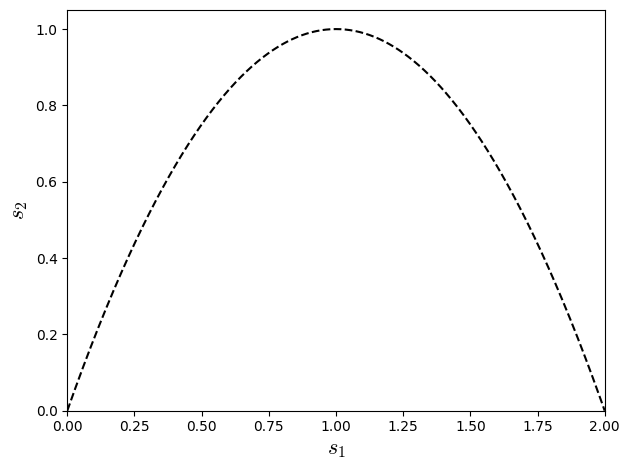

In [308]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'

# ---- data ----
s1r = np.linspace(0, 2.0, 1000)
s2r  = s1r*(2-s1r)

plt.plot(s1r,s2r,'k--')
plt.xlabel(r'$s_{1}$',fontsize=16)
plt.ylabel(r'$s_{2}$',fontsize=16)
plt.xlim(0,2)
plt.ylim(0,1.05)

plt.tight_layout()
plt.show()

In [309]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
#--------------------------------------- Parameters (physical units) ------------------------------------------
A   = 1.0                         # Amplitude
phi = 0.0                         # Wave initial shift
k_w   = 1.0                       # Wave number
c   = 0.0                         # wave speed
nu  = 0.066666666666666666*np.pi # Diffusive coefficient
m_waves = 1                       # Wave Period
L = m_waves * (2.0*np.pi / k_w)   # Domain Lentgh
t_end = 12.0                       # Final time
#--------------------------------------- Lattice-Properties-D1Q3 ----------------------------------------------
w = np.array([1.0/2.0, 1.0/6.0, 1.0/6.0, 1.0/12.0, 1.0/12.0],dtype="float64")
cx = np.array([0, 1, -1, 2, -2],dtype="int16")  
cs=1.0/np.sqrt(1.0);
#--------------------------------- Initialization - Save Data Arrays -----------------------------------------------
cases=4
Nx0 = np.array([10, 20, 40, 80],dtype="int64")
r0 = 2**(0)*np.array([2.0**(1), 2.0**(2), 2.0**(3), 2.0**(4)],dtype="float64")
u_cases = np.empty(cases, dtype=object) # array field used to same data over time
for i in range(cases):
    u_cases[i] = np.zeros((Nx0[i]), dtype="float64")
for case in range(0,cases):
    #------------------------------------- Parameters (numerical units) -------------------------------------------
    Nx=Nx0[case]  # Numerical Length
    x  = np.linspace(0.0, L, Nx, endpoint=False,dtype="float64") # Numerical Domain
    dx = L / Nx # Grid size
    r = 1*r0[case] # dx/dt relation
    dt = dx/r
    ce = c/r
    nue = nu * dt / (dx*dx)
    tau1 = 0.5 + nue / cs**2
    tau2 = 1.0/((1.0/tau1)*(2.0-(1.0/tau1)))
    tau3 = 1.0
    tau4 = 1.0
    nt = int(np.ceil(t_end / dt))
    print(f"dx={dx:.4e},\t dt={dt:.4e}\t nt={nt:d},\t tn={nt*dt:.2f}") # Print values for check
    print(f"c_lbm={ce:.3f},\t tau1={tau1:.4f},\t tau2={tau2:.4f}")
    print(f"s1={1.0/tau1:.4f},\t s2={1.0/tau2:.4f}")
    print(f"nt={nt:.3f}\t, nue={nue:.4f}")
    #--------------------------------- Initialization - LBM - Numerical Arrays -----------------------------------------
    u=np.zeros((Nx),dtype="float64")
    u = A * np.sin(k_w*(x+dx/2) + phi)
    mx=np.zeros((Nx),dtype="float64")
    mxx=np.zeros((Nx),dtype="float64")
    mxxx=np.zeros((Nx),dtype="float64")
    mxxxx=np.zeros((Nx),dtype="float64")
    f=np.zeros((5,Nx),dtype="float64")
    feq=np.zeros((5,Nx),dtype="float64")
    fp=np.zeros((5,Nx),dtype="float64")
    for k in range(0,5):
        f[k,:]=w[k]*(u[:]+cx[k]*ce*u[:]/cs**2)
        fp[k,:]=w[k]*(u[:]+cx[k]*ce*u[:]/cs**2)
    #----------------------------------------- Init Loop --------------------------------------------------------
    for t in range(nt*10):
        #========================================= LBM - Solution =============================================
        #--------------------Collision----------------
        for k in range(0,5):
            feq[k,:]= w[k]*(u[:]+cx[k]*(ce*u[:])/cs**2)
        mx = np.einsum('i,ix->x', cx, f-feq)
        mxx = np.einsum('i,ix->x', cx*cx - cs**2, f-feq)
        mxxx = np.einsum('i,ix->x', cx*cx*cx - 3.0*cx*cs**2, f-feq)
        mxxxx = np.einsum('i,ix->x', cx*cx*cx*cx - 6.0*cx*cx*cs**2 + 3.0*cs**4, f-feq)
        for k in range(0,5):
            fp[k,:]= feq[k,:] + w[k]*( (1.0-1.0/tau1)*cx[k]*mx[:]/cs**2 + 
                                       (1.0-1.0/tau2)*(cx[k]**2-cs**2)*mxx[:]/(2.0*cs**2) + 
                                       (1.0-1.0/tau3)*(cx[k]**3 - 3.0*cx[k]*cs**2)*mxxx[:]/(6.0*cs**2) + 
                                       (1.0-1.0/tau4)*(cx[k]**4 - 6.0*cx[k]**2*cs**2 + 3.0*cs**4)*mxxxx[:]/(24.0*cs**2))
        #-----------------streaming-------------------
        for k in range(0,5):
            f[k,:]=np.roll(fp[k,:], cx[k], axis=0)
    #----------------------------------------- Maind Loop --------------------------------------------------------
    for t in range(nt):
        #========================================= LBM - Solution =============================================
        #--------------------Collision----------------
        for k in range(0,5):
            feq[k,:]= w[k]*(u[:]+cx[k]*(ce*u[:])/cs**2)
        mx = np.einsum('i,ix->x', cx, f-feq)
        mxx = np.einsum('i,ix->x', cx*cx - cs**2, f-feq)
        mxxx = np.einsum('i,ix->x', cx*cx*cx - 3.0*cx*cs**2, f-feq)
        mxxxx = np.einsum('i,ix->x', cx*cx*cx*cx - 6.0*cx*cx*cs**2 + 3.0*cs**4, f-feq)
        for k in range(0,5):
            # fp[k,:]= feq[k,:] + w[k]*( (1.0-1.0/tau1)*cx[k]*mx[:]/cs**2 + (1.0-1.0/tau2)*(cx[k]**2-cs**2)*mxx[:]/(2.0*cs**2) )
            fp[k,:]= feq[k,:] + w[k]*( (1.0-1.0/tau1)*cx[k]*mx[:]/cs**2 + (1.0-1.0/tau2)*(cx[k]**2-cs**2)*mxx[:]/(2.0*cs**2)
                                     + (1.0-1.0/tau3)*(cx[k]**3 - 3.0*cx[k]*cs**2)*mxxx[:]/(6.0*cs**2) 
                                     + (1.0-1.0/tau4)*(cx[k]**4 - 6.0*cx[k]**2*cs**2 + 3.0*cs**4)*mxxxx[:]/(24.0*cs**2))
        #-----------------streaming-------------------
        for k in range(0,5):
            f[k,:]=np.roll(fp[k,:], cx[k], axis=0)
        #----------------------Macro------------------
        # u[:]=f[0,:]+f[1,:]+f[2,:]
        u=np.einsum('ix->x', f)
    #---------------------save-field-cases--------------
    u_cases[case][:]=u[:]

dx=6.2832e-01,	 dt=3.1416e-01	 nt=39,	 tn=12.25
c_lbm=0.000,	 tau1=0.6667,	 tau2=1.3333
s1=1.5000,	 s2=0.7500
nt=39.000	, nue=0.1667
dx=3.1416e-01,	 dt=7.8540e-02	 nt=153,	 tn=12.02
c_lbm=0.000,	 tau1=0.6667,	 tau2=1.3333
s1=1.5000,	 s2=0.7500
nt=153.000	, nue=0.1667
dx=1.5708e-01,	 dt=1.9635e-02	 nt=612,	 tn=12.02
c_lbm=0.000,	 tau1=0.6667,	 tau2=1.3333
s1=1.5000,	 s2=0.7500
nt=612.000	, nue=0.1667
dx=7.8540e-02,	 dt=4.9087e-03	 nt=2445,	 tn=12.00
c_lbm=0.000,	 tau1=0.6667,	 tau2=1.3333
s1=1.5000,	 s2=0.7500
nt=2445.000	, nue=0.1667


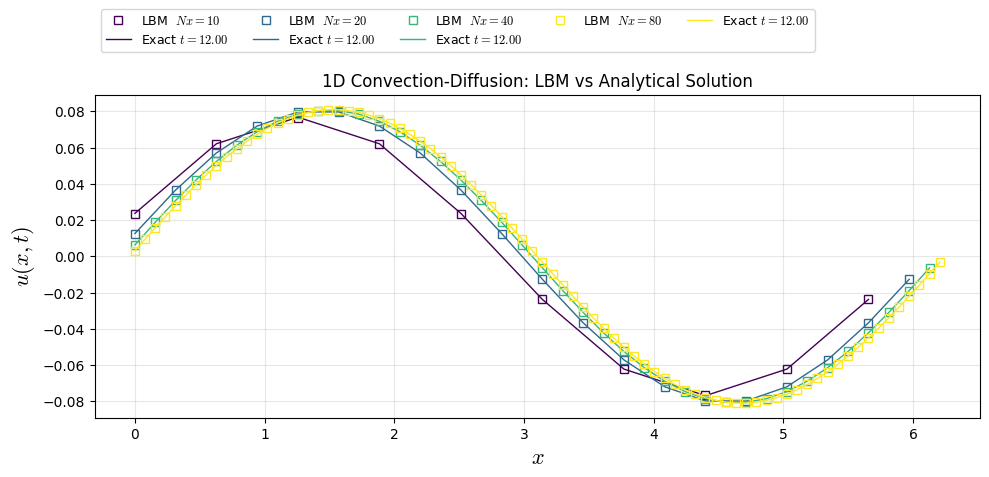

In [112]:
#****************************************Data-Analysis*********************************************
# ---------------- exact solution ----------------
def u_exact(x, t, A, k_w, phi, c, nu):
    return A * np.exp(-nu * k_w**2 * t) * np.sin(k_w * ((x+dx/2) - c*t) + phi)
u_ana = np.empty(cases, dtype=object) # array field used to same data over time
xl = np.empty(cases, dtype=object) # array field used to same data over time
for i in range(cases):
    Nx=Nx0[i]  # Numerical Length
    x  = np.linspace(0.0, L, Nx, endpoint=False,dtype="float64") # Numerical Domain
    dx = L / Nx # Grid size
    r = r0[i] # dx/dt relation
    dt = dx/r
    nt = int(np.ceil(t_end / dt))
    xl[i] = np.linspace(0.0, L, Nx0[i], endpoint=False,dtype="float64")
    u_ana[i] = np.zeros((Nx0[i]), dtype="float64")
    u_ana[i] = u_exact(xl[i], nt*dt , A, k_w, phi, c, nu)
# -----------------Plot Results --------------------
plt.figure(figsize=(10,5))
colors = plt.cm.viridis(np.linspace(0, 1, cases))
for i in range(cases):
    plt.plot(xl[i], u_cases[i], "s", color=colors[i], lw=1, label=f"LBM  $Nx={Nx0[i]:.0f}$",fillstyle='none')
    plt.plot(xl[i], u_ana[i], color=colors[i], lw=1, label=f"Exact $t={t_end:.2f}$")

plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.title("1D Convection-Diffusion: LBM vs Analytical Solution")
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()

In [113]:
Erro= np.zeros((cases), dtype="float64")
for i in range(cases):
    Erro[i]=np.sqrt(np.sum((u_cases[i]-u_ana[i])**2))/np.sqrt(np.sum((u_ana[i])**2))
    print(f'Erro{i}=',Erro[i])
TEp=np.polyfit(np.log(Nx0), np.log(Erro), 1)
print(TEp)
print(f'ltests[i] = np.array([{1/tau1:.2f},{cs**2:.2f},{-TEp[0]:.2f},{Erro[0]},{Erro[1]},{Erro[2]},{Erro[3]}],dtype="float64")')

Erro0= 0.004599718961801556
Erro1= 0.0002749602031773098
Erro2= 1.698961887475239e-05
Erro3= 1.058627059687448e-06
[-4.02719041  3.87957962]
ltests[i] = np.array([1.50,1.00,4.03,0.004599718961801556,0.0002749602031773098,1.698961887475239e-05,1.058627059687448e-06],dtype="float64")


In [99]:
#------------------ List of teste cases ---------------------------
ntests=7
ltests = np.empty(ntests, dtype=object) # list [omega, cs**2, a, erro1, erro2, erro3]
ltests[0] = np.array([1.50,1.00,4.03,0.004599718961801556,0.0002749602031773098,1.698961887475239e-05,1.058627059687448e-06],dtype="float64")
ltests[1] = np.array([1.71,1.00,3.98,0.005199610529243154,0.00033641770218694904,2.128052577020292e-05,1.3341315894431132e-06],dtype="float64")
ltests[2] = np.array([1.85,1.00,3.84,0.008577517318573242,0.0006840863786029296,4.606322710962401e-05,2.937077039092195e-06],dtype="float64")
ltests[3] = np.array([1.92,1.00,3.67,0.013425866292973048,0.0013666248833396693,0.00010138164946464713,6.646765376943909e-06],dtype="float64")
ltests[4] = np.array([1.96,1.00,3.45,0.018109250938120103,0.002387268695706511,0.00020508836169905412,1.4134539711221436e-05],dtype="float64")
ltests[5] = np.array([1.98,1.00,3.20,0.02160554093352197,0.003602549982868643,0.00037843951806540796,2.8462664687168793e-05],dtype="float64")

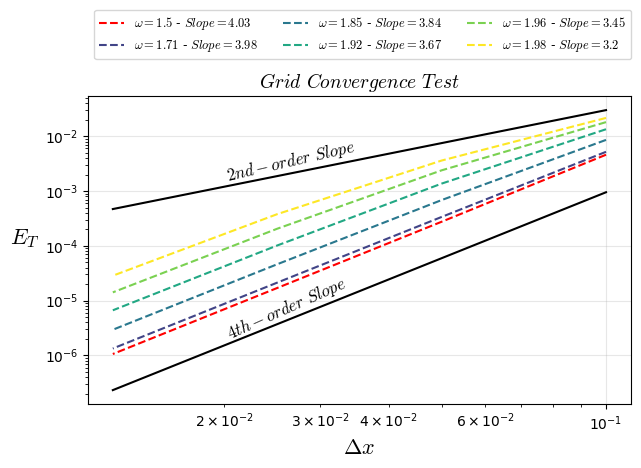

In [118]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
plt.figure(figsize=(7,4))
plt.title("$Grid$ $Convergence$ $Test$",fontsize=14)
colors = plt.cm.viridis(np.linspace(0, 1, ntests-1))
plt.loglog(1/Nx0,ltests[0][3:],'r--',fillstyle='none', label=f'$\\omega={ltests[0][0]}$ - $Slope={ltests[0][2]}$')
for i in range(6)[1:]:
    plt.loglog(1/Nx0,ltests[i][3:],'--',color=colors[i],fillstyle='none', label=f'$\\omega={ltests[i][0]}$ - $Slope={ltests[i][2]}$')
    
plt.loglog(1/Nx0,2.*1.5/(Nx0**2),'k-',fillstyle='none')
plt.text(0.02, 0.0015, "$2nd-order$ $Slope$", rotation=13,fontsize=12)
plt.loglog(1/Nx0,1.*9.5/(Nx0**4),'k-',fillstyle='none')
plt.text(0.02, 0.000002, "$4th-order$ $Slope$", rotation=24,fontsize=12)
# plt.ylim(0,0.01)
plt.grid(True, alpha=0.3)
# plt.legend(loc=2,ncol=3,fontsize=8.5)
plt.legend(ncol=3,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.ylabel('$E_{T}$',fontsize=16,rotation=0,horizontalalignment='right')
plt.xlabel('$\Delta x$',fontsize=16)
plt.show()

#### Sympy code for FDM expansion of LBM Non-Linear convective equation up to sixth-order

In [310]:
import sympy as sp
# -----------------------------------------------------------------------------
# 1) Symbols (parameters and step sizes)
# -----------------------------------------------------------------------------
dx, dt = sp.symbols('Delta_x Delta_t', positive=True, real=True)

def d(name, nx=0, nt=0):
    n = nx + nt
    if n == 1:
        num = rf"\partial{{{name}}}"
    else:
        num = rf"\partial^{{{n}}}{{{name}}}"
    den = ""
    if nx:
        den += rf"\partial{{x^{{{nx}}}}}" if nx > 1 else r"\partial{x}"
    if nt:
        den += rf"\partial{{t^{{{nt}}}}}" if nt > 1 else r"\partial{t}"
    return sp.Symbol(rf"\frac{{{num}}}{{{den}}}")
# -------------------1st-Order-Terms----------------------
dut = d("u", nt=1); dux   = d("u", nx=1)
# -------------------2nd-Order-Terms----------------------
dux2 = d("u", nx=2); duxt = d("u", nx=1, nt=1); dut2 = d("u", nt=2)
# -------------------3rd-Order-Terms----------------------
dux3 = d("u", nx=3); dux2t = d("u", nx=2, nt=1); duxt2 = d("u", nx=1, nt=2); dut3  = d("u", nt=3)
# -------------------4th-Order-Terms----------------------
dux4 = d("u", nx=4); dux3t = d("u", nx=3, nt=1); dux2t2 = d("u", nx=2, nt=2); duxt3 = d("u", nx=1, nt=3); dut4 = d("u", nt=4)
# -------------------5th-Order-Terms----------------------
dux5 = d("u", nx=5); dux4t = d("u", nx=4, nt=1); dux3t2 = d("u", nx=3, nt=2); dux2t3 = d("u", nx=2, nt=3); duxt4 = d("u", nx=1, nt=4); dut5 = d("u", nt=5)
# -------------------5th-Order-Terms----------------------
dux6 = d("u", nx=6); dux5t = d("u", nx=5, nt=1); dux4t2 = d("u", nx=4, nt=2); dux3t3 = d("u", nx=3, nt=3); dux2t4 = d("u", nx=2, nt=4); duxt5 = d("u", nx=1, nt=5); dut6 = d("u", nt=6)

# -----------------------------------------------------------------------------
# 2) Continuous variables and field
# -----------------------------------------------------------------------------
x, t = sp.symbols('x t', real=True)
uf = sp.Function('u')
Bf = sp.Function('B')
# Shorthand for the base (continuous) field value at (x,t)
UF = uf(x, t)
#-------------------------------------------------------
def taylor_u(sx=0, st=0, order_x=4, order_t=4):
    expr = sp.S(0)
    # Keep all mixed terms up to the specified individual orders.
    for m in range(order_x + 1):
        for n in range(order_t + 1):
            # skip the (0,0) term? no, keep it.
            term = ( (sx*dx)**m * (st*dt)**n
                    / (sp.factorial(m)*sp.factorial(n))
                    * sp.diff(UF, x, m, t, n) )
            expr += term
    return sp.expand(expr)


In [311]:
# u_x^{t+1}, u_x^{t}, u_x^{t-1}, u_x^{t-2}, u_x^{t-3}, u_x^{t-4}
u_t_p1 = taylor_u(sx=0,  st=+1, order_x=0, order_t=6)
display( Math(r"u_x^{t+1} = " + sp.latex(u_t_p1)))
u_t_0  = taylor_u(sx=0,  st=0,  order_x=0, order_t=0)  # exactly phi(x,t)
display( Math(r"u_x^{t} = " + sp.latex(u_t_0)))
u_t_m1 = taylor_u(sx=0,  st=-1, order_x=0, order_t=6)
display( Math(r"u_x^{t-1} = " + sp.latex(u_t_m1)))
u_t_m2 = taylor_u(sx=0,  st=-2, order_x=0, order_t=6)
display( Math(r"u_x^{t-2} = " + sp.latex(u_t_m2)))
u_t_m3 = taylor_u(sx=0,  st=-3, order_x=0, order_t=6)
display( Math(r"u_x^{t-3} = " + sp.latex(u_t_m3)))
u_t_m4 = taylor_u(sx=0,  st=-4, order_x=0, order_t=6)
display( Math(r"u_x^{t-4} = " + sp.latex(u_t_m4)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [312]:
# u_{x±1,2,3}^{t}
u_xm1_t0 = taylor_u(sx=-1, st=0,  order_x=6, order_t=0)
display( Math(r"u_{x-1}^{t} = " + sp.latex(u_xm1_t0)))
u_xp1_t0 = taylor_u(sx=+1, st=0,  order_x=6, order_t=0)
display( Math(r"u_{x+1}^{t} = " + sp.latex(u_xp1_t0)))
u_xm2_t0 = taylor_u(sx=-2, st=0,  order_x=6, order_t=0)
display( Math(r"u_{x-2}^{t} = " + sp.latex(u_xm2_t0)))
u_xp2_t0 = taylor_u(sx=+2, st=0,  order_x=6, order_t=0)
display( Math(r"u_{x+2}^{t} = " + sp.latex(u_xp2_t0)))
u_xm3_t0 = taylor_u(sx=-3, st=0,  order_x=6, order_t=0)
display( Math(r"u_{x-3}^{t} = " + sp.latex(u_xm3_t0)))
u_xp3_t0 = taylor_u(sx=+3, st=0,  order_x=6, order_t=0)
display( Math(r"u_{x+3}^{t} = " + sp.latex(u_xp3_t0)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [313]:
# u_{x±1,2,3}^{t-1}
u_xm1_tm1 = taylor_u(sx=-1, st=-1, order_x=6, order_t=6)
display( Math(r"u_{x-1}^{t-1} = " + sp.latex(u_xm1_tm1)))
u_xp1_tm1 = taylor_u(sx=+1, st=-1, order_x=6, order_t=6)
display( Math(r"u_{x+1}^{t-1} = " + sp.latex(u_xp1_tm1)))

u_xm2_tm1 = taylor_u(sx=-2, st=-1, order_x=6, order_t=6)
display( Math(r"u_{x-2}^{t-1} = " + sp.latex(u_xm2_tm1)))
u_xp2_tm1 = taylor_u(sx=+2, st=-1, order_x=6, order_t=6)
display( Math(r"u_{x+2}^{t-1} = " + sp.latex(u_xp2_tm1)))

u_xm3_tm1 = taylor_u(sx=-3, st=-1, order_x=6, order_t=6)
display( Math(r"u_{x-3}^{t-1} = " + sp.latex(u_xm3_tm1)))
u_xp3_tm1 = taylor_u(sx=+3, st=-1, order_x=6, order_t=6)
display( Math(r"u_{x+3}^{t-1} = " + sp.latex(u_xp3_tm1)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [314]:
# u_{x±1,2,3}^{t-2}
u_xm1_tm2 = taylor_u(sx=-1, st=-2, order_x=6, order_t=6)
display( Math(r"u_{x-1}^{t-2} = " + sp.latex(u_xm1_tm2)))
u_xp1_tm2 = taylor_u(sx=+1, st=-2, order_x=6, order_t=6)
display( Math(r"u_{x+1}^{t-2} = " + sp.latex(u_xp1_tm2)))

u_xm2_tm2 = taylor_u(sx=-2, st=-2, order_x=6, order_t=6)
display( Math(r"u_{x-2}^{t-2} = " + sp.latex(u_xm2_tm2)))
u_xp2_tm2 = taylor_u(sx=+2, st=-2, order_x=6, order_t=6)
display( Math(r"u_{x+2}^{t-2} = " + sp.latex(u_xp2_tm2)))

u_xm3_tm2 = taylor_u(sx=-3, st=-2, order_x=6, order_t=6)
display( Math(r"u_{x-3}^{t-2} = " + sp.latex(u_xm3_tm2)))
u_xp3_tm2 = taylor_u(sx=+3, st=-2, order_x=6, order_t=6)
display( Math(r"u_{x+3}^{t-2} = " + sp.latex(u_xp3_tm2)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [315]:
# u_{x±1,2,3}^{t-3}
u_xm1_tm3 = taylor_u(sx=-1, st=-3, order_x=6, order_t=6)
display( Math(r"u_{x-1}^{t-3} = " + sp.latex(u_xm1_tm3)))
u_xp1_tm3 = taylor_u(sx=+1, st=-3, order_x=6, order_t=6)
display( Math(r"u_{x+1}^{t-3} = " + sp.latex(u_xp1_tm3)))

u_xm2_tm3 = taylor_u(sx=-2, st=-3, order_x=6, order_t=6)
display( Math(r"u_{x-2}^{t-3} = " + sp.latex(u_xm2_tm3)))
u_xp2_tm3 = taylor_u(sx=+2, st=-3, order_x=6, order_t=6)
display( Math(r"u_{x+2}^{t-3} = " + sp.latex(u_xp2_tm3)))

u_xm3_tm3 = taylor_u(sx=-3, st=-3, order_x=6, order_t=6)
display( Math(r"u_{x-3}^{t-3} = " + sp.latex(u_xm3_tm3)))
u_xp3_tm3 = taylor_u(sx=+3, st=-3, order_x=6, order_t=6)
display( Math(r"u_{x+3}^{t-3} = " + sp.latex(u_xp3_tm3)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [316]:
# -----------------------------------------------------------------------------
# 5) Build the discrete equation (expanded) and move everything to one side
# -----------------------------------------------------------------------------
lhs = u_t_p1

rhs = (
        alpha0s*u_t_0 
       + alpha0sd1*(u_xp1_t0 + u_xm1_t0) + alpha0sd2*(u_xp2_t0 + u_xm2_t0) + alpha0sd3*(u_xp3_t0 + u_xm3_t0)
       + alpha1s*u_t_m1 
       + alpha1sd1*(u_xp1_tm1 + u_xm1_tm1) + alpha1sd2*(u_xp2_tm1 + u_xm2_tm1) + alpha1sd3*(u_xp3_tm1 + u_xm3_tm1)
       + alpha2s*u_t_m2 
       + alpha2sd1*(u_xp1_tm2 + u_xm1_tm2) + alpha2sd2*(u_xp2_tm2 + u_xm2_tm2) + alpha2sd3*(u_xp3_tm2 + u_xm3_tm2)
       + alpha3s*u_t_m3
       + alpha3sd1*(u_xp1_tm3 + u_xm1_tm3) + alpha3sd2*(u_xp2_tm3 + u_xm2_tm3) + alpha3sd3*(u_xp3_tm3 + u_xm3_tm3)
       + alpha4s*u_t_m4
      )

residual = sp.simplify(sp.expand(lhs - rhs))  # = 0 is the modified equation

In [326]:
max_dx=6
max_dt=3
max_total=6
expr = sp.expand(residual)
poly = sp.Poly(expr, dx, dt, domain='EX')  # keep symbolic coeffs
kept = sp.S(0)

for (px, pt), coeff in poly.terms():
    if (px <= max_dx) and (pt <= max_dt) and ((px + pt) <= max_total):
        kept += coeff * dx**px * dt**pt

In [327]:
kept

Delta_t**3*Delta_x**2*(-9*s_1*s_2*s_3*s_4*Derivative(u(x, t), (t, 3), (x, 2))/4 + 19*s_1*s_2*s_4*Derivative(u(x, t), (t, 3), (x, 2))/4 - 5*s_1*s_2*Derivative(u(x, t), (t, 3), (x, 2))/6 + 19*s_1*s_3*s_4*Derivative(u(x, t), (t, 3), (x, 2))/2 - 5*s_1*s_3*Derivative(u(x, t), (t, 3), (x, 2)) - 23*s_1*s_4*Derivative(u(x, t), (t, 3), (x, 2))/2 + 11*s_1*Derivative(u(x, t), (t, 3), (x, 2))/2 + 23*s_2*s_3*s_4*Derivative(u(x, t), (t, 3), (x, 2))/3 - 25*s_2*s_3*Derivative(u(x, t), (t, 3), (x, 2))/6 - 43*s_2*s_4*Derivative(u(x, t), (t, 3), (x, 2))/6 + 5*s_2*Derivative(u(x, t), (t, 3), (x, 2))/2 - 25*s_3*s_4*Derivative(u(x, t), (t, 3), (x, 2))/2 + 7*s_3*Derivative(u(x, t), (t, 3), (x, 2)) + 23*s_4*Derivative(u(x, t), (t, 3), (x, 2))/2 - 5*Derivative(u(x, t), (t, 3), (x, 2))) + Delta_t**3*(37*s_1*s_2*s_3*s_4*Derivative(u(x, t), (t, 3))/6 - 3*s_1*s_2*s_3*Derivative(u(x, t), (t, 3)) - 3*s_1*s_2*s_4*Derivative(u(x, t), (t, 3)) + s_1*s_2*Derivative(u(x, t), (t, 3)) - 3*s_1*s_3*s_4*Derivative(u(x, t), (t,

In [328]:
term1 = sp.expand(kept).subs({
    # ------------------------------------------------6th order----------------------------------------------------------------------------------------------------------
    UF.diff(x, 6):dux6,UF.diff(x, 5, t):dux5t,UF.diff(x, 4, t, 2):dux4t2,UF.diff(x, 3, t, 3):dux3t3,UF.diff(x, 2, t, 4):dux2t4,UF.diff(x, t, 5):duxt5,UF.diff(t, 6):dut6,
    # ------------------------------------------------5th order--------------------------------------------------------------------------------------------
    UF.diff(x, 5):dux5,UF.diff(x, 4, t):dux4t,UF.diff(x, 3, t, 2):dux3t2,UF.diff(x, 2, t, 3):dux2t3,UF.diff(x, t, 4):duxt4,UF.diff(t, 5):dut5,
    # ------------------------------------------------4th order--------------------------------------------------------------------------------------------
    UF.diff(x, 4):dux4,UF.diff(x, 3, t):dux3t,UF.diff(x, 2, t, 2):dux2t2,UF.diff(x, t, 3):duxt3,UF.diff(t, 4):dut4,
    # ------------------------------------------------3rd order--------------------------------------------------------------------------------------------
    UF.diff(x, 3):dux3, UF.diff(x, 2, t):dux2t, UF.diff(x, t, 2):duxt2, UF.diff(t, 3):dut3,
    # ------------------------------------------------2nd order--------------------------------------------------------------------------------------------
    UF.diff(x, 2):dux2, UF.diff(x, t):duxt, UF.diff(t, 2):dut2,
    # ------------------------------------------------1st order--------------------------------------------------------------------------------------------
    UF.diff(x):dux, UF.diff(t):dut,
})
display(term1)

-9*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_1*s_2*s_3*s_4/4 + 19*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_1*s_2*s_4/4 - 5*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_1*s_2/6 + 19*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_1*s_3*s_4/2 - 5*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_1*s_3 - 23*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_1*s_4/2 + 11*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_1/2 + 23*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_2*s_3*s_4/3 - 25*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_2*s_3/6 - 43*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\partial{t^{3}}}*s_2*s_4/6 + 5*Delta_t**3*Delta_x**2*\frac{\partial^{5}{u}}{\partial{x^{2}}\parti

In [329]:
dux6_term1=sp.factor(term1.coeff(dux6))
display(dux6_term1)

Delta_x**6*(11*s_1*s_2*s_3*s_4 - 75*s_1*s_2*s_3 + 140*s_1*s_2*s_4 + 150*s_1*s_2 + 225*s_1*s_3*s_4 - 450*s_1*s_4 - 12*s_2*s_3*s_4 + 150*s_2*s_3 - 300*s_2*s_4 - 300*s_2 - 450*s_3*s_4 + 900*s_4)/720

In [333]:
term2 = sp.collect(expand(-term1/(dt*s1*s2*s3*s4))+ dut,[dut,dux,
                                                         dux2*dx*dx/dt,duxt,dut2*dt,
                                                         dux2t*dx*dx,duxt2,dux3,dut3*dt**2,
                                                         dux2t2*dt*dx**2,dux4*dx**4/dt,
                                                         dux2t3*dx**2*dt**2,dux4t*dx**4,
                                                         dux6*dx**6/dt,dux4t2*dx**4*dt
                                                        ]).subs(dux2t3,0).subs(dux4t2,0)
display(term2)

Delta_t**2*\frac{\partial^{3}{u}}{\partial{t^{3}}}*(-37/6 + 3/s_4 + 3/s_3 - 1/(s_3*s_4) + 3/s_2 - 1/(s_2*s_4) - 1/(s_2*s_3) + 3/s_1 - 1/(s_1*s_4) - 1/(s_1*s_3) - 1/(s_1*s_2)) + Delta_t*Delta_x**2*\frac{\partial^{4}{u}}{\partial{x^{2}}\partial{t^{2}}}*(-9/4 + 15/(4*s_3) + 1/(2*s_3*s_4) + 15/(2*s_2) - 5/(2*s_2*s_4) - 17/(2*s_2*s_3) + 2/(s_2*s_3*s_4) + 7/s_1 - 3/(s_1*s_4) - 9/(2*s_1*s_3) - 9/(s_1*s_2) + 3/(s_1*s_2*s_4) + 6/(s_1*s_2*s_3)) + Delta_t*\frac{\partial^{2}{u}}{\partial{t^{2}}}*(7/2 - 1/s_4 - 1/s_3 - 1/s_2 - 1/s_1) + Delta_x**4*\frac{\partial^{5}{u}}{\partial{x^{4}}\partial{t}}*(3/8 - 3/(8*s_4) + 5/(8*s_3) - 7/(12*s_3*s_4) + 13/(24*s_2) - 1/(s_2*s_4) - 23/(12*s_2*s_3) + 2/(s_2*s_3*s_4) - 13/(12*s_1) + 13/(12*s_1*s_4) - 9/(4*s_1*s_3) + 1/(2*s_1*s_3*s_4) - 29/(12*s_1*s_2) + 2/(s_1*s_2*s_4) + 13/(2*s_1*s_2*s_3) - 4/(s_1*s_2*s_3*s_4)) + Delta_x**2*\frac{\partial^{3}{u}}{\partial{x^{2}}\partial{t}}*(3/2 - 3/(2*s_3) - 1/(s_3*s_4) - 3/s_2 + 3/(s_2*s_3) - 4/s_1 + 1/(s_1*s_4) + 1/(s_1*s_3

In [334]:
nu = sp.symbols('\\nu')
nut=dx**2/dt*(1/(s1)-sp.Rational(1,2))
term3 = collect(expand(term2.subs(dx**2/dt*(1/(s1)-sp.Rational(1,2)),nu)
                       .subs(dut2,nut*nut*dux4)
                       .subs(dux2t,nut*dux4)
                       .subs(dut3,nut*nut*nut*dux6)
                       .subs(dux4t,nut*dux6)
                       .subs(dux2t2,nut*nut*dux6)),
                [dux4*dx**4/dt,dux4*dx**4/dt,dux6*dx**6/dt])
term3

\frac{\partial^{2}{u}}{\partial{x^{2}}}*\nu + Delta_x**6*\frac{\partial^{6}{u}}{\partial{x^{6}}}*(1/180 - 1/(12*s_4) + 1/(18*s_3) + 1/(3*s_3*s_4) + 11/(12*s_2) - 5/(12*s_2*s_3) - 1/(2*s_2*s_3*s_4) - 1/(15*s_1) + 1/(2*s_1*s_4) - 1/(3*s_1*s_3) - 5/(3*s_1*s_3*s_4) - 5/(s_1*s_2) + 1/(2*s_1*s_2*s_4) + 17/(6*s_1*s_2*s_3) + 2/(s_1*s_2*s_3*s_4) + 7/(6*s_1**2) - 7/(6*s_1**2*s_4) + 3/(4*s_1**2*s_3) + 5/(2*s_1**2*s_3*s_4) + 53/(6*s_1**2*s_2) - 2/(s_1**2*s_2*s_4) - 13/(2*s_1**2*s_2*s_3) - 2/(s_1**2*s_2*s_3*s_4) - 11/(3*s_1**3) + 3/(2*s_1**3*s_4) - 1/(s_1**3*s_3*s_4) - 9/(2*s_1**3*s_2) + 2/(s_1**3*s_2*s_4) + 5/(s_1**3*s_2*s_3) + 3/s_1**4 - 1/(s_1**4*s_4) - 1/(s_1**4*s_3) - 1/(s_1**4*s_2))/Delta_t + Delta_x**4*\frac{\partial^{4}{u}}{\partial{x^{4}}}*(1/(2*s_2) - 2/(s_1*s_2) + 1/(2*s_1**2) + 2/(s_1**2*s_2) - 1/s_1**3)/Delta_t

In [335]:
dux4_term3=sp.factor(term3.coeff(dux4*dx**4/dt))
display(dux4_term3)

(s_1 - 2)*(s_1**2 - 2*s_1 + s_2)/(2*s_1**3*s_2)

In [336]:
dux6_term3=sp.factor(term3.coeff(dux6*dx**6/dt))
display(dux6_term3)

(s_1**4*s_2*s_3*s_4 - 15*s_1**4*s_2*s_3 + 10*s_1**4*s_2*s_4 + 60*s_1**4*s_2 + 165*s_1**4*s_3*s_4 - 75*s_1**4*s_4 - 90*s_1**4 - 12*s_1**3*s_2*s_3*s_4 + 90*s_1**3*s_2*s_3 - 60*s_1**3*s_2*s_4 - 300*s_1**3*s_2 - 900*s_1**3*s_3*s_4 + 90*s_1**3*s_3 + 510*s_1**3*s_4 + 360*s_1**3 + 210*s_1**2*s_2*s_3*s_4 - 210*s_1**2*s_2*s_3 + 135*s_1**2*s_2*s_4 + 450*s_1**2*s_2 + 1590*s_1**2*s_3*s_4 - 360*s_1**2*s_3 - 1170*s_1**2*s_4 - 360*s_1**2 - 660*s_1*s_2*s_3*s_4 + 270*s_1*s_2*s_3 - 180*s_1*s_2 - 810*s_1*s_3*s_4 + 360*s_1*s_3 + 900*s_1*s_4 + 540*s_2*s_3*s_4 - 180*s_2*s_3 - 180*s_2*s_4 - 180*s_3*s_4)/(180*s_1**4*s_2*s_3*s_4)

In [338]:
dux6_term3_2=sp.factor(((dux6_term3*180*s1**4*s2*s3*s4)))
display(dux6_term3_2)

s_1**4*s_2*s_3*s_4 - 15*s_1**4*s_2*s_3 + 10*s_1**4*s_2*s_4 + 60*s_1**4*s_2 + 165*s_1**4*s_3*s_4 - 75*s_1**4*s_4 - 90*s_1**4 - 12*s_1**3*s_2*s_3*s_4 + 90*s_1**3*s_2*s_3 - 60*s_1**3*s_2*s_4 - 300*s_1**3*s_2 - 900*s_1**3*s_3*s_4 + 90*s_1**3*s_3 + 510*s_1**3*s_4 + 360*s_1**3 + 210*s_1**2*s_2*s_3*s_4 - 210*s_1**2*s_2*s_3 + 135*s_1**2*s_2*s_4 + 450*s_1**2*s_2 + 1590*s_1**2*s_3*s_4 - 360*s_1**2*s_3 - 1170*s_1**2*s_4 - 360*s_1**2 - 660*s_1*s_2*s_3*s_4 + 270*s_1*s_2*s_3 - 180*s_1*s_2 - 810*s_1*s_3*s_4 + 360*s_1*s_3 + 900*s_1*s_4 + 540*s_2*s_3*s_4 - 180*s_2*s_3 - 180*s_2*s_4 - 180*s_3*s_4

In [341]:
dux6_term3_2=sp.factor(((dux6_term3*180*s1**4*s2*s3*s4)).subs(s2,s1*(2-s1)))/(s1-2)
display(dux6_term3_2)

-s_1**5*s_3*s_4 + 15*s_1**5*s_3 - 10*s_1**5*s_4 - 60*s_1**5 + 12*s_1**4*s_3*s_4 - 90*s_1**4*s_3 + 60*s_1**4*s_4 + 300*s_1**4 - 45*s_1**3*s_3*s_4 + 210*s_1**3*s_3 - 210*s_1**3*s_4 - 540*s_1**3 + 90*s_1**2*s_3*s_4 - 180*s_1**2*s_3 + 360*s_1**2*s_4 + 360*s_1**2 - 90*s_1*s_3*s_4 - 270*s_1*s_4 + 90*s_3*s_4

In [342]:
from sympy import latex
print(latex(dux6_term3_2))

- s_{1}^{5} s_{3} s_{4} + 15 s_{1}^{5} s_{3} - 10 s_{1}^{5} s_{4} - 60 s_{1}^{5} + 12 s_{1}^{4} s_{3} s_{4} - 90 s_{1}^{4} s_{3} + 60 s_{1}^{4} s_{4} + 300 s_{1}^{4} - 45 s_{1}^{3} s_{3} s_{4} + 210 s_{1}^{3} s_{3} - 210 s_{1}^{3} s_{4} - 540 s_{1}^{3} + 90 s_{1}^{2} s_{3} s_{4} - 180 s_{1}^{2} s_{3} + 360 s_{1}^{2} s_{4} + 360 s_{1}^{2} - 90 s_{1} s_{3} s_{4} - 270 s_{1} s_{4} + 90 s_{3} s_{4}


In [346]:
s1, s3, s4 = sp.symbols("s1 s3 s4")

eq = (
    -s1**5*s3*s4 + 15*s1**5*s3 - 10*s1**5*s4 - 60*s1**5
    + 12*s1**4*s3*s4 - 90*s1**4*s3 + 60*s1**4*s4 + 300*s1**4
    - 45*s1**3*s3*s4 + 210*s1**3*s3 - 210*s1**3*s4 - 540*s1**3
    + 90*s1**2*s3*s4 - 180*s1**2*s3 + 360*s1**2*s4 + 360*s1**2
    - 90*s1*s3*s4 - 270*s1*s4
    + 90*s3*s4
)


sol_s4 = sp.solve(sp.Eq(eq, 0), s4)

display(sol_s4[0])
s4_expr = sp.factor(sol_s4[0])
display(s4_expr)
display(sol_s4[0].subs(s3,0))

15*s1**2*(s1**3*s3 - 4*s1**3 - 6*s1**2*s3 + 20*s1**2 + 14*s1*s3 - 36*s1 - 12*s3 + 24)/(s1**5*s3 + 10*s1**5 - 12*s1**4*s3 - 60*s1**4 + 45*s1**3*s3 + 210*s1**3 - 90*s1**2*s3 - 360*s1**2 + 90*s1*s3 + 270*s1 - 90*s3)

15*s1**2*(s1 - 2)*(s1**2*s3 - 4*s1**2 - 4*s1*s3 + 12*s1 + 6*s3 - 12)/(s1**5*s3 + 10*s1**5 - 12*s1**4*s3 - 60*s1**4 + 45*s1**3*s3 + 210*s1**3 - 90*s1**2*s3 - 360*s1**2 + 90*s1*s3 + 270*s1 - 90*s3)

15*s1**2*(-4*s1**3 + 20*s1**2 - 36*s1 + 24)/(10*s1**5 - 60*s1**4 + 210*s1**3 - 360*s1**2 + 270*s1)

In [347]:
# from sympy import latex
# print(latex(sol_s4[0]))
print(sp.pycode(sol_s4[0]))

15*s1**2*(s1**3*s3 - 4*s1**3 - 6*s1**2*s3 + 20*s1**2 + 14*s1*s3 - 36*s1 - 12*s3 + 24)/(s1**5*s3 + 10*s1**5 - 12*s1**4*s3 - 60*s1**4 + 45*s1**3*s3 + 210*s1**3 - 90*s1**2*s3 - 360*s1**2 + 90*s1*s3 + 270*s1 - 90*s3)


In [348]:
# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['mathtext.fontset'] = 'cm'

# # ---- data ----
# s1r = np.linspace(0, 2.0, 1000)
# s4r  = s1r*(26.0*s1r**3-100.0*s1r**2+144.0*s1r-96.0)/(-12.0*s1r**4+36.0*s1r**3-86.0*s1r**2+96.0*s1r-72)

# plt.plot(s1r,s4r,'k--')
# plt.xlabel(r'$s_{1}$',fontsize=16)
# plt.ylabel(r'$s_{4}$',fontsize=16)
# plt.xlim(0,2)
# plt.ylim(0,1.05)

# plt.tight_layout()
# plt.show()

In [349]:
# s1, s3, s4 = sp.symbols("s1 s3 s4")

# eq = (
#     -s1**5*s3*s4 + 9*s1**5*s3 - 12*s1**5*s4 - 26*s1**5
#     + 4*s1**4*s3*s4 - 34*s1**4*s3 + 36*s1**4*s4 + 100*s1**4
#     + 3*s1**3*s3*s4 + 56*s1**3*s3 - 86*s1**3*s4 - 144*s1**3
#     + 24*s1**2*s3*s4 - 48*s1**2*s3 + 96*s1**2*s4 + 96*s1**2
#     - 24*s1*s3*s4 - 72*s1*s4
#     + 24*s3*s4
# )

# sol_s3 = sp.solve(sp.Eq(eq, 0), s3)

# display(sol_s3[0])
# display(sol_s3[0].subs(s4,0))

In [350]:
# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['mathtext.fontset'] = 'cm'

# # ---- data ----
# s1r = np.linspace(0, 2.0, 1000)
# s3r  = 2.0*(13.0*s1r**4 - 50.0*s1r**3 + 72.0*s1r**2 - 48.0*s1r)/(9.0*s1r**4 - 34.0*s1r**3 + 56.0*s1r**3 - 48.0*s1r)

# plt.plot(s1r,s3r,'k--')
# plt.xlabel(r'$s_{1}$',fontsize=16)
# plt.ylabel(r'$s_{3}$',fontsize=16)
# plt.xlim(0,2)
# plt.ylim(0,1.05)

# plt.tight_layout()
# plt.show()

In [351]:
# import numpy as np

# solutions = []

# for s1_val in np.linspace(1.0, 1.99, 200):
#     for s3_val in np.linspace(1.0, 1.99, 200):

#         s1_val = float(s1_val)
#         s3_val = float(s3_val)

#         s4_val = float(
#             sol_s4[0].subs({
#                 s1: s1_val,
#                 s3: s3_val
#             }).evalf()
#         )

#         if 0 < s4_val < 2:
#             solutions.append((s1_val, s3_val, s4_val))

# solutions[:10]

In [393]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
#--------------------------------------- Parameters (physical units) ------------------------------------------
A   = 1.0                         # Amplitude
phi = 0.0                         # Wave initial shift
k_w   = 1.0                       # Wave number
c   = 0.0                         # wave speed
nu  = 0.066666666666666666*np.pi # Diffusive coefficient
m_waves = 1                       # Wave Period
L = m_waves * (2.0*np.pi / k_w)   # Domain Lentgh
t_end = 12.0                       # Final time
#--------------------------------------- Lattice-Properties-D1Q3 ----------------------------------------------
w = np.array([1.0/2.0, 1.0/6.0, 1.0/6.0, 1.0/12.0, 1.0/12.0],dtype="float64")
cx = np.array([0, 1, -1, 2, -2],dtype="int16")  
cs=1.0/np.sqrt(1.0);
#--------------------------------- Initialization - Save Data Arrays -----------------------------------------------
cases=4
Nx0 = np.array([10, 20, 40, 80],dtype="int64")
r0 = 2**(0)*np.array([2.0**(1), 2.0**(2), 2.0**(3), 2.0**(4)],dtype="float64")
u_cases = np.empty(cases, dtype=object) # array field used to same data over time
for i in range(cases):
    u_cases[i] = np.zeros((Nx0[i]), dtype="float64")
for case in range(0,cases):
    #------------------------------------- Parameters (numerical units) -------------------------------------------
    Nx=Nx0[case]  # Numerical Length
    x  = np.linspace(0.0, L, Nx, endpoint=False,dtype="float64") # Numerical Domain
    dx = L / Nx # Grid size
    r = 1*r0[case] # dx/dt relation
    dt = dx/r
    ce = c/r
    nue = nu * dt / (dx*dx)
    tau1 = 0.5 + nue / cs**2
    tau2 = 1.0/((1.0/tau1)*(2.0-(1.0/tau1)))
    s1=1.0/tau1
    s3= 0.2
    omega3 = s3
    s4=(15*s1**2*(s1**3*s3 - 4*s1**3 - 6*s1**2*s3 + 20*s1**2 + 14*s1*s3 - 36*s1 - 12*s3 + 24)/
        (s1**5*s3 + 10*s1**5 - 12*s1**4*s3 - 60*s1**4 + 45*s1**3*s3 + 210*s1**3 - 90*s1**2*s3 - 360*s1**2 + 90*s1*s3 + 270*s1 - 90*s3) )
    omega4 = s4
    nt = int(np.ceil(t_end / dt))
    print(f"dx={dx:.4e},\t dt={dt:.4e}\t nt={nt:d},\t tn={nt*dt:.2f}") # Print values for check
    print(f"c_lbm={ce:.3f},\t tau1={tau1:.4f},\t tau2={tau2:.4f},\t omega3={omega3:.4f},\t tau4={omega4:.4f}")
    print(f"s1={1.0/tau1:.4f},\t s2={1.0/tau2:.4f}")
    print(f"nt={nt:.3f}\t, nue={nue:.4f}")
    #--------------------------------- Initialization - LBM - Numerical Arrays -----------------------------------------
    u=np.zeros((Nx),dtype="float64")
    u = A * np.sin(k_w*(x+dx/2) + phi)
    mx=np.zeros((Nx),dtype="float64")
    mxx=np.zeros((Nx),dtype="float64")
    mxxx=np.zeros((Nx),dtype="float64")
    mxxxx=np.zeros((Nx),dtype="float64")
    f=np.zeros((5,Nx),dtype="float64")
    feq=np.zeros((5,Nx),dtype="float64")
    fp=np.zeros((5,Nx),dtype="float64")
    for k in range(0,5):
        f[k,:]=w[k]*(u[:]+cx[k]*ce*u[:]/cs**2)
        fp[k,:]=w[k]*(u[:]+cx[k]*ce*u[:]/cs**2)
    #----------------------------------------- Init Loop --------------------------------------------------------
    for t in range(nt*10):
        #========================================= LBM - Solution =============================================
        #--------------------Collision----------------
        for k in range(0,5):
            feq[k,:]= w[k]*(u[:]+cx[k]*(ce*u[:])/cs**2)
        mx = np.einsum('i,ix->x', cx, f-feq)
        mxx = np.einsum('i,ix->x', cx*cx - cs**2, f-feq)
        mxxx = np.einsum('i,ix->x', cx*cx*cx - 3.0*cx*cs**2, f-feq)
        mxxxx = np.einsum('i,ix->x', cx*cx*cx*cx - 6.0*cx*cx*cs**2 + 3.0*cs**4, f-feq)
        for k in range(0,5):
            fp[k,:]= feq[k,:] + w[k]*( (1.0-1.0/tau1)*cx[k]*mx[:]/cs**2 + 
                                       (1.0-1.0/tau2)*(cx[k]**2-cs**2)*mxx[:]/(2.0*cs**2) + 
                                       (1.0-omega3)*(cx[k]**3 - 3.0*cx[k]*cs**2)*mxxx[:]/(6.0*cs**2) + 
                                       (1.0-omega4)*(cx[k]**4 - 6.0*cx[k]**2*cs**2 + 3.0*cs**4)*mxxxx[:]/(24.0*cs**2)
                                     )
        #-----------------streaming-------------------
        for k in range(0,5):
            f[k,:]=np.roll(fp[k,:], cx[k], axis=0)
    #----------------------------------------- Maind Loop --------------------------------------------------------
    for t in range(nt):
        #========================================= LBM - Solution =============================================
        #--------------------Collision----------------
        for k in range(0,5):
            feq[k,:]= w[k]*(u[:]+cx[k]*(ce*u[:])/cs**2)
        mx = np.einsum('i,ix->x', cx, f-feq)
        mxx = np.einsum('i,ix->x', cx*cx - cs**2, f-feq)
        mxxx = np.einsum('i,ix->x', cx*cx*cx - 3.0*cx*cs**2, f-feq)
        mxxxx = np.einsum('i,ix->x', cx*cx*cx*cx - 6.0*cx*cx*cs**2 + 3.0*cs**4, f-feq)
        for k in range(0,5):
            fp[k,:]= feq[k,:] + w[k]*( (1.0-1.0/tau1)*cx[k]*mx[:]/cs**2 + 
                                       (1.0-1.0/tau2)*(cx[k]**2-cs**2)*mxx[:]/(2.0*cs**2) + 
                                       (1.0-omega3)*(cx[k]**3 - 3.0*cx[k]*cs**2)*mxxx[:]/(6.0*cs**2) + 
                                       (1.0-omega4)*(cx[k]**4 - 6.0*cx[k]**2*cs**2 + 3.0*cs**4)*mxxxx[:]/(24.0*cs**2))
        #-----------------streaming-------------------
        for k in range(0,5):
            f[k,:]=np.roll(fp[k,:], cx[k], axis=0)
        #----------------------Macro------------------
        # u[:]=f[0,:]+f[1,:]+f[2,:]
        u=np.einsum('ix->x', f)
    #---------------------save-field-cases--------------
    u_cases[case][:]=u[:]

dx=6.2832e-01,	 dt=3.1416e-01	 nt=39,	 tn=12.25
c_lbm=0.000,	 tau1=0.6667,	 tau2=1.3333,	 omega3=0.2000,	 tau4=0.6705
s1=1.5000,	 s2=0.7500
nt=39.000	, nue=0.1667
dx=3.1416e-01,	 dt=7.8540e-02	 nt=153,	 tn=12.02
c_lbm=0.000,	 tau1=0.6667,	 tau2=1.3333,	 omega3=0.2000,	 tau4=0.6705
s1=1.5000,	 s2=0.7500
nt=153.000	, nue=0.1667
dx=1.5708e-01,	 dt=1.9635e-02	 nt=612,	 tn=12.02
c_lbm=0.000,	 tau1=0.6667,	 tau2=1.3333,	 omega3=0.2000,	 tau4=0.6705
s1=1.5000,	 s2=0.7500
nt=612.000	, nue=0.1667
dx=7.8540e-02,	 dt=4.9087e-03	 nt=2445,	 tn=12.00
c_lbm=0.000,	 tau1=0.6667,	 tau2=1.3333,	 omega3=0.2000,	 tau4=0.6705
s1=1.5000,	 s2=0.7500
nt=2445.000	, nue=0.1667


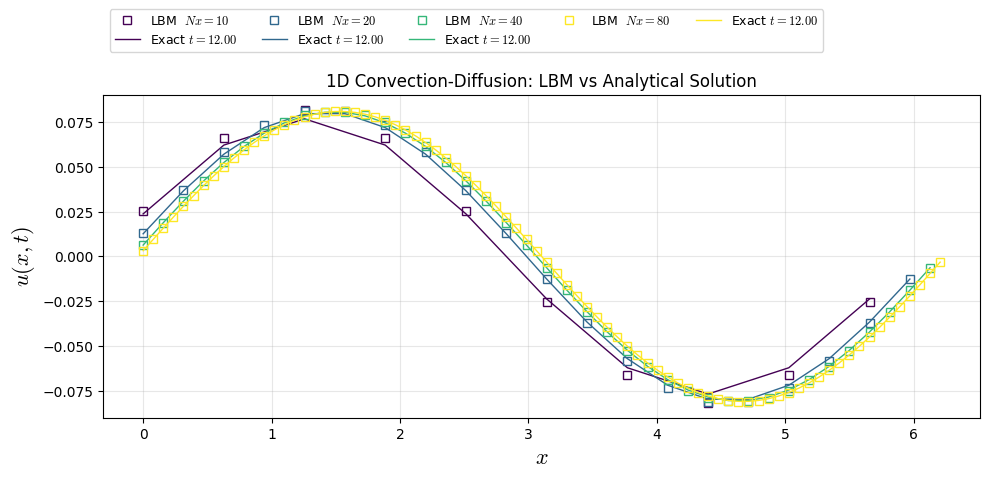

In [394]:
#****************************************Data-Analysis*********************************************
# ---------------- exact solution ----------------
def u_exact(x, t, A, k_w, phi, c, nu):
    return A * np.exp(-nu * k_w**2 * t) * np.sin(k_w * ((x+dx/2) - c*t) + phi)
u_ana = np.empty(cases, dtype=object) # array field used to same data over time
xl = np.empty(cases, dtype=object) # array field used to same data over time
for i in range(cases):
    Nx=Nx0[i]  # Numerical Length
    x  = np.linspace(0.0, L, Nx, endpoint=False,dtype="float64") # Numerical Domain
    dx = L / Nx # Grid size
    r = r0[i] # dx/dt relation
    dt = dx/r
    nt = int(np.ceil(t_end / dt))
    xl[i] = np.linspace(0.0, L, Nx0[i], endpoint=False,dtype="float64")
    u_ana[i] = np.zeros((Nx0[i]), dtype="float64")
    u_ana[i] = u_exact(xl[i], nt*dt , A, k_w, phi, c, nu)
# -----------------Plot Results --------------------
plt.figure(figsize=(10,5))
colors = plt.cm.viridis(np.linspace(0, 1, cases))
for i in range(cases):
    plt.plot(xl[i], u_cases[i], "s", color=colors[i], lw=1, label=f"LBM  $Nx={Nx0[i]:.0f}$",fillstyle='none')
    plt.plot(xl[i], u_ana[i], color=colors[i], lw=1, label=f"Exact $t={t_end:.2f}$")

plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.title("1D Convection-Diffusion: LBM vs Analytical Solution")
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()

In [395]:
Erro= np.zeros((cases), dtype="float64")
for i in range(cases):
    Erro[i]=np.sqrt(np.sum((u_cases[i]-u_ana[i])**2))/np.sqrt(np.sum((u_ana[i])**2))
    print(f'Erro{i}=',Erro[i])
TEp=np.polyfit(np.log(Nx0), np.log(Erro), 1)
print(TEp)
print(f'ltests[i] = np.array([{1/tau1:.2f},{cs**2:.2f},{-TEp[0]:.2f},{Erro[0]},{Erro[1]},{Erro[2]},{Erro[3]}],dtype="float64")')

Erro0= 0.06556434656607603
Erro1= 0.018596275749281833
Erro2= 0.004830393181918797
Erro3= 0.001217854141449349
[-1.91962959  1.72773687]
ltests[i] = np.array([1.50,1.00,1.92,0.06556434656607603,0.018596275749281833,0.004830393181918797,0.001217854141449349],dtype="float64")
